## 1. Introdução

Este projeto foi desenvolvido com o objetivo de apoiar o planejamento de um grande hospital diante da possibilidade de um novo surto de COVID-19. A análise utiliza dados da PNAD COVID-19, do IBGE, organizados em ambiente de nuvem e tratados em Python para gerar indicadores relevantes de risco clínico, acesso à saúde, pressão assistencial, comportamento da população e vulnerabilidade socioeconômica.

O foco central do trabalho é responder às seguintes perguntas:

* quais grupos apresentam maior risco de agravamento;
* quais grupos tendem a pressionar mais a rede de saúde;
* onde existem sinais de barreira de acesso ao atendimento;
* quais ações o hospital deve priorizar em um novo surto.

A proposta foi construída de forma enxuta, priorizando análises úteis para decisão hospitalar, e não apenas descrições gerais da base.

---

## 2. Base utilizada e organização dos dados

Foi utilizada a base PNAD COVID-19, disponibilizada pelo IBGE. A arquitetura do projeto seguiu a lógica de camadas em nuvem, com tratamento posterior em Python no Colab. A camada final utilizada no notebook foi uma gold consolidada, contendo variáveis clínicas, demográficas, comportamentais e econômicas já preparadas para análise.

As principais etapas de preparação envolveram:

* padronização dos tipos de dados;
* tratamento de respostas textuais em variáveis binárias;
* exclusão de colunas sem variação ou sem valor analítico;
* limpeza de variáveis de teste e isolamento;
* criação de variáveis derivadas, como grupo de sintomas e teste positivo consolidado.

As colunas sem utilidade analítica, como indicadores totalmente vazios ou sem variabilidade, foram removidas para evitar distorções visuais e estatísticas.

---

In [ ]:
!pip install s3fs pyarrow seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
from IPython.display import display, HTML
from IPython.display import clear_output

In [ ]:
## Lendo os dados do bucket S3 - data-output/gold

df_covid = pd.read_parquet(
    "s3://lab-727776330445/data-output/gold/",
    engine="pyarrow",
    storage_options={
        "key": os.environ["AWS_ACCESS_KEY_ID"],
        "secret": os.environ["AWS_SECRET_ACCESS_KEY"],
        "token": os.environ["AWS_SESSION_TOKEN"],
    }
)

In [ ]:
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (18, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
sns.set_theme(style="whitegrid")

In [ ]:
df_covid.head()

,estado,idade,sexo,febre,tosse,dor_garganta,dificuldade_respirar,dor_cabeca,dor_peito,nausea,nariz_entupido,fadiga,dor_olhos,perda_olfato_paladar,dor_muscular,diarreia,procurou_atendimento,atendimento_ubs,atendimento_upa,atendimento_hospital_sus,atendimento_privado,atendimento_ps_privado,atendimento_hospital_privado,internacao,uso_ventilador,fez_teste_covid,teste_swab,resultado_swab,teste_dedo,resultado_dedo,teste_sangue,resultado_sangue,diabetes,hipertensao,doenca_respiratoria,doenca_cardiaca,depressao,cancer,nivel_isolamento,atividade_economica,plano_saude,sabao,alcool,mascara,luva,desinfetante,qtd_sintomas,tem_comorbidade,teve_atendimento,status_teste,score_isolamento,caso_grave,indice_risco,regiao,faixa_etaria,nivel_severidade,kit_prevencao,perfil_risco_comportamental
0,Rondônia,36,Homem,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não,Não,Não,Não,Não,Redução parcial,Comércio,Sim,Sim,Sim,Sim,Não,Sim,0,Não,Não,Indefinido,2.0,Não,Baixo,Norte,18-39,Baixa,Completo,Baixo risco
1,Rondônia,30,Mulher,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não,Não,Não,Não,Não,Redução parcial,Comércio,Não,Sim,Sim,Sim,Não,Sim,0,Não,Não,Indefinido,2.0,Não,Baixo,Norte,18-39,Baixa,Completo,Baixo risco
2,Rondônia,13,Homem,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não,Não,Não,Não,Não,Isolamento rigoroso,Não respondido/ignorado,Sim,Sim,Sim,Sim,Não,Sim,0,Não,Não,Indefinido,4.0,Não,Baixo,Norte,0-17,Baixa,Completo,Baixo risco
3,Rondônia,11,Homem,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não,Não,Não,Não,Não,Isolamento rigoroso,Não respondido/ignorado,Sim,Sim,Sim,Sim,Não,Sim,0,Não,Não,Indefinido,4.0,Não,Baixo,Norte,0-17,Baixa,Completo,Baixo risco
4,Rondônia,57,Mulher,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não respondido/ignorado,Não,Não,Não,Não,Não,Não,Redução parcial,Não respondido/ignorado,Não,Sim,Sim,Sim,Não,Sim,0,Não,Não,Indefinido,2.0,Não,Baixo,Norte,40-59,Baixa,Completo,Baixo risco


In [ ]:
# Contexto e tamanho da base

# Mostrar total de registros
print("Total de registros:", len(df_covid))

# Mostrar schema
print(df_covid.dtypes)


Total de registros: 1157984
estado                           object
idade                             int32
sexo                             object
febre                            object
tosse                            object
dor_garganta                     object
dificuldade_respirar             object
dor_cabeca                       object
dor_peito                        object
nausea                           object
nariz_entupido                   object
fadiga                           object
dor_olhos                        object
perda_olfato_paladar             object
dor_muscular                     object
diarreia                         object
procurou_atendimento             object
atendimento_ubs                  object
atendimento_upa                  object
atendimento_hospital_sus         object
atendimento_privado              object
atendimento_ps_privado           object
atendimento_hospital_privado     object
internacao                       object
uso_ventilad

### 📊 Distribuição por Sexo

Este gráfico apresenta a distribuição dos entrevistados por sexo, considerando o total da amostra analisada.

A visualização permite identificar o balanceamento da base e possíveis impactos em análises subsequentes, especialmente em estudos relacionados a comportamento, acesso à saúde e severidade de sintomas.

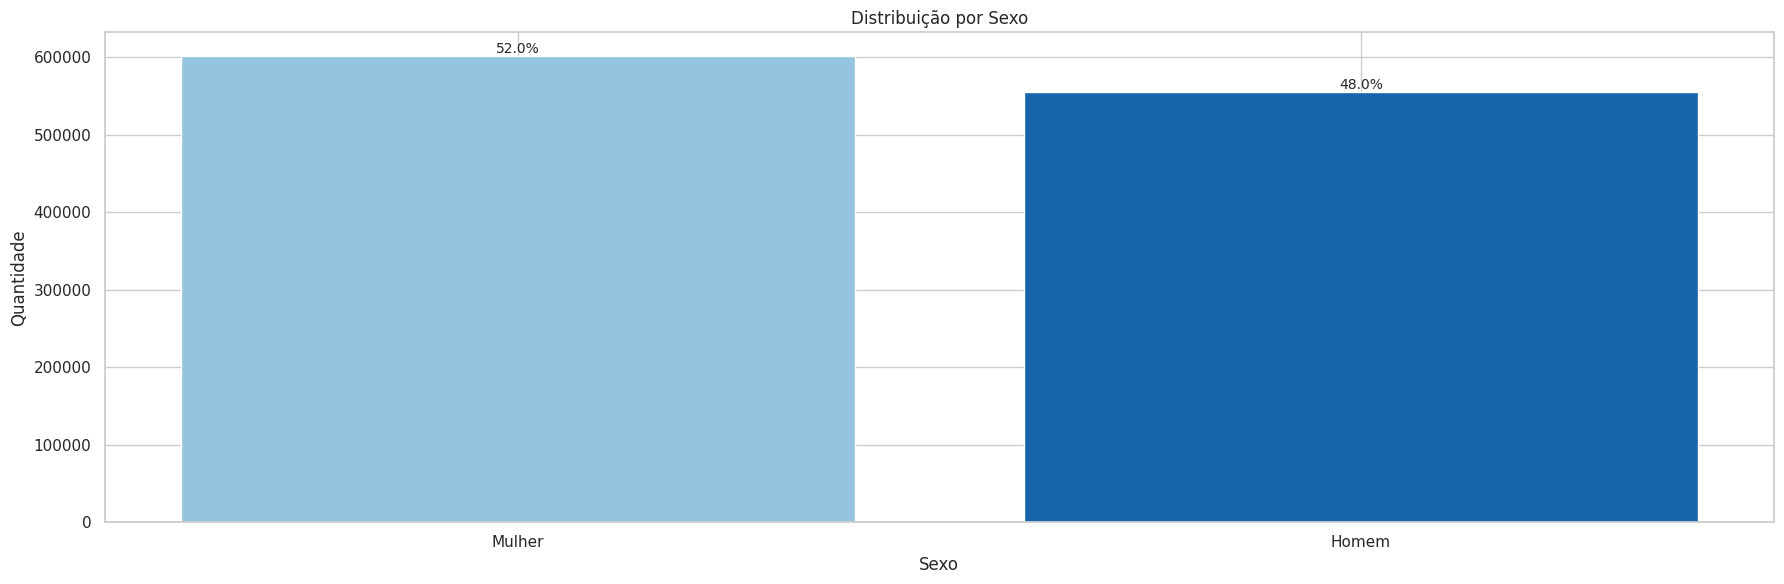


Distribuição por Sexo:



,sexo,count,percentual
1,Mulher,602248,52.01%
0,Homem,555736,47.99%


In [ ]:
# ===== Sexo =====
pdf = df_covid.groupby("sexo").size().reset_index(name="count")

# Calcular percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenar (opcional)
pdf = pdf.sort_values(by="count", ascending=False)

num_barras = len(pdf)
cores_sexo = cm.Blues(np.linspace(0.4, 0.8, num_barras))

# Plot
plt.figure(figsize=(18,6))
bars = plt.bar(pdf["sexo"], pdf["count"], color=cores_sexo)

# Percentual nos rótulos
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Distribuição por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Sexo:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

Observa-se uma leve predominância do sexo feminino na base, representando aproximadamente 52% dos registros.
O sexo masculino corresponde a cerca de 48% da amostra.
A distribuição é relativamente equilibrada, o que é positivo para evitar viés em análises comparativas.

---

### 📊 Distribuição por Faixa Etária

Este gráfico apresenta a distribuição dos entrevistados por faixa etária, permitindo compreender o perfil demográfico da população analisada. A segmentação por idade é essencial para identificar padrões de comportamento, vulnerabilidade e impacto da doença em diferentes grupos.

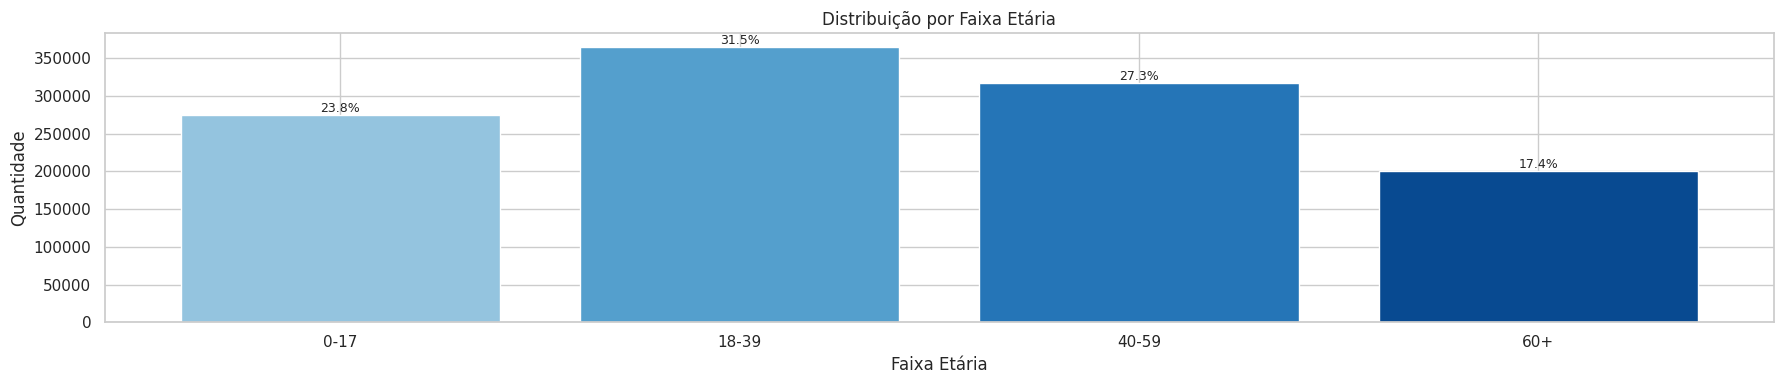


Distribuição por Faixa Etária:



,faixa_etaria,count,percentual
0,0-17,275259,23.77%
1,18-39,365284,31.54%
2,40-59,316426,27.33%
3,60+,201015,17.36%


In [ ]:
# Distribuição dos entrevistados por faixa etária

pdf = df_covid.groupby("faixa_etaria").size().reset_index(name="count")

# Calcular percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Criar coluna auxiliar com início da faixa
pdf["ordem"] = pdf["faixa_etaria"].str.extract(r'(\d+)').astype(int)

# Ordenar corretamente
pdf = pdf.sort_values(by="ordem")

num_barras = len(pdf)
cores_faixa = cm.Blues(np.linspace(0.4, 0.9, num_barras))

# Plot
plt.figure(figsize=(18,4))
bars = plt.bar(pdf["faixa_etaria"], pdf["count"], color=cores_faixa)

# Percentual nos rótulos
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Distribuição por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

pdf_display = pdf.drop(columns="ordem").copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Faixa Etária:\n")
display(pdf_display)

###🔍 Principais pontos de análise

- A faixa etária 18–39 anos concentra a maior parcela da amostra, representando aproximadamente 31,5% dos entrevistados.
- Em seguida, a faixa 40–59 anos corresponde a cerca de 27,3%.
- O grupo 0–17 anos representa aproximadamente 23,8% da base.
- A menor participação está na faixa 60+, com cerca de 17,4%.

A predominância de indivíduos entre 18 e 59 anos indica que a base é majoritariamente composta por população em idade ativa, o que pode influenciar:

- Maior exposição ao vírus (atividade econômica e mobilidade)
- Diferentes padrões de busca por atendimento
- Menor taxa relativa de casos graves (em comparação com idosos)

Por outro lado, a menor participação do grupo 60+ merece atenção, pois:

- Trata-se de uma população com maior risco de complicações

---

### 📊 Distribuição por Região

Este gráfico apresenta a distribuição dos entrevistados por região, permitindo compreender o perfil geográfico da população analisada. A segmentação por região é essencial para identificar padrões de comportamento, vulnerabilidade e impacto da doença em diferentes regiões do país, permitindo a tomada de ação de forma mais efetiva, de acordo com a localidade.

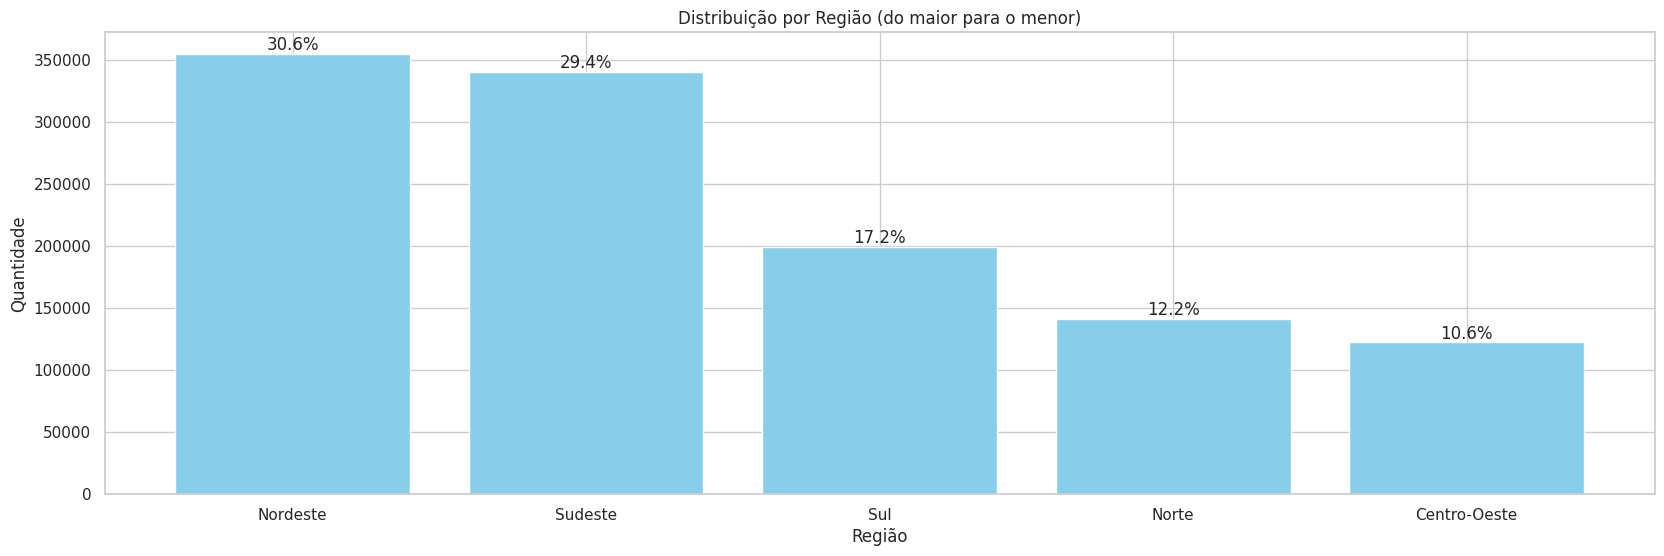


Distribuição por Faixa Etária:



,regiao,count,percentual
0,Nordeste,354632,30.62%
1,Sudeste,340583,29.41%
2,Sul,199020,17.19%
3,Norte,141413,12.21%
4,Centro-Oeste,122336,10.56%


In [ ]:
# Agrupar por região e contar casos
pdf = df_covid.groupby("regiao").size().reset_index(name="count")

# Calcular percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenar do maior para o menor
pdf = pdf.sort_values(by="count", ascending=False)

# Plot
plt.figure(figsize=(20,6))
bars = plt.bar(pdf["regiao"], pdf["count"], color="skyblue")

# Adicionar apenas percentual
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title("Distribuição por Região (do maior para o menor)")
plt.xlabel("Região")
plt.ylabel("Quantidade")
plt.show()

pdf_display = pdf.copy().reset_index(drop=True)
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Faixa Etária:\n")
display(pdf_display)

###🔍 Principais pontos de análise

- A região Nordeste concentra a maior parcela da amostra, representando aproximadamente 30,9% dos entrevistados.
- Em seguida, a região Sudeste corresponde a cerca de 29,4%.
- A região Sul representa aproximadamente 17,2% da base.
- A menores participações são das regiões Norte e Centro-Oeste, onde as faixas ficam em 12,2% e 10,6%, respectivamente.

Diferenças regionais podem ser significativas em variáveis como:

- acesso à saúde
- taxa de infecção
- comportamento social

A amostra apresenta uma **boa cobertura nacional**, mas com **peso maior nas regiões mais populosas**, o que é esperado — porém exige cuidado na interpretação de resultados agregados.

---

### 📊 Distribuição por Estado

Este gráfico apresenta a distribuição dos entrevistados por estado.

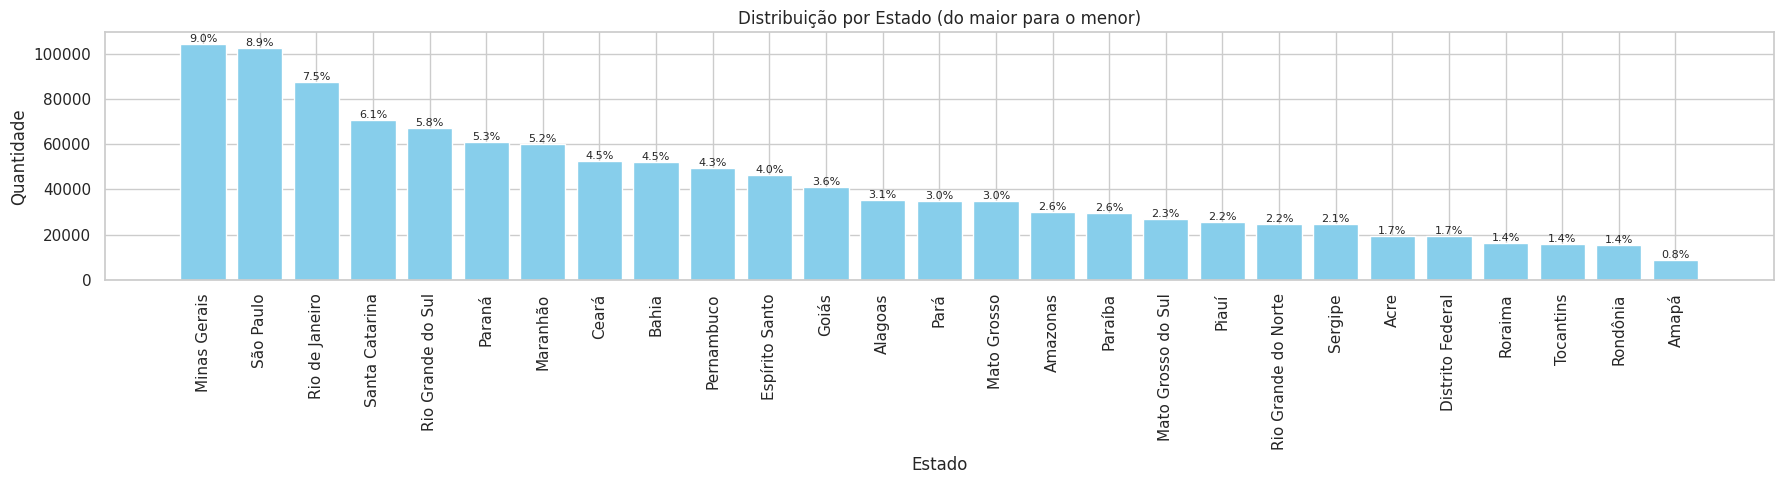


Distribuição por Estado:



,estado,count,percentual
0,Minas Gerais,104156,8.99%
1,São Paulo,102603,8.86%
2,Rio de Janeiro,87324,7.54%
3,Santa Catarina,70865,6.12%
4,Rio Grande do Sul,67323,5.81%
5,Paraná,60832,5.25%
6,Maranhão,60256,5.20%
7,Ceará,52427,4.53%
8,Bahia,51935,4.48%
9,Pernambuco,49614,4.28%


In [ ]:
# Agrupar por estado e contar casos
pdf = df_covid.groupby("estado").size().reset_index(name="count")

# Calcular percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenar do maior para o menor
pdf = pdf.sort_values(by="count", ascending=False)

# Plot
plt.figure(figsize=(18,5))
bars = plt.bar(pdf["estado"], pdf["count"], color="skyblue")

# Adicionar percentual nas barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Distribuição por Estado (do maior para o menor)")
plt.xlabel("Estado")
plt.ylabel("Quantidade")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

pdf_display = pdf.copy().reset_index(drop=True)
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Estado:\n")
display(pdf_display)

###🔍 Principais pontos de análise

##### Estados com maior participação
- **Minas Gerais (8,99%)**, **São Paulo (8,86%)** e **Rio de Janeiro (7,54%)** lideram a amostra.
- Esses três estados concentram juntos uma parcela significativa dos entrevistados, refletindo sua relevância populacional e econômica.
- Destaque para **Minas Gerais**, que aparece ligeiramente à frente de **São Paulo**, o que pode indicar particularidades no plano amostral.

Estados do Sul aparecem com alta representatividade:

- **Santa Catarina (6,12%)**
- **Rio Grande do Sul (5,81%)**
- **Paraná (5,25%)**
- A região Sul, como um todo, apresenta uma participação robusta e relativamente equilibrada entre seus estados.

Nordeste com distribuição pulverizada

- O Nordeste aparece bem distribuído entre vários estados:
- **Maranhão (5,20%)**, **Ceará (4,53%)**, **Bahia (4,48%)**, **Pernambuco (4,28%)**
- Diferente do Sudeste, não há grande concentração em apenas um ou dois estados, mas sim uma divisão mais homogênea.

Norte e Centro-Oeste com menor participação individual

- Estados dessas regiões apresentam percentuais menores de forma geral:
- Exemplo: **Amazonas (2,61%)**, **Pará (3,03%)**, **Mato Grosso (3,02%)**
- No Centro-Oeste:
- **Goiás (3,56%)** se destaca, enquanto os demais têm participações mais modestas.

Estados com menor representatividade

- **Amapá (0,75%)**, **Rondônia (1,36%)**, **Tocantins (1,37%)**, **Roraima (1,40%)**
- Esses valores podem refletir:
- Menor população
- Limitações logísticas da coleta
- Estrutura amostral da pesquisa

---

### 📊 Agrupando região e estado
Esta visualização apresenta a agregação dos entrevistados por região e estado.

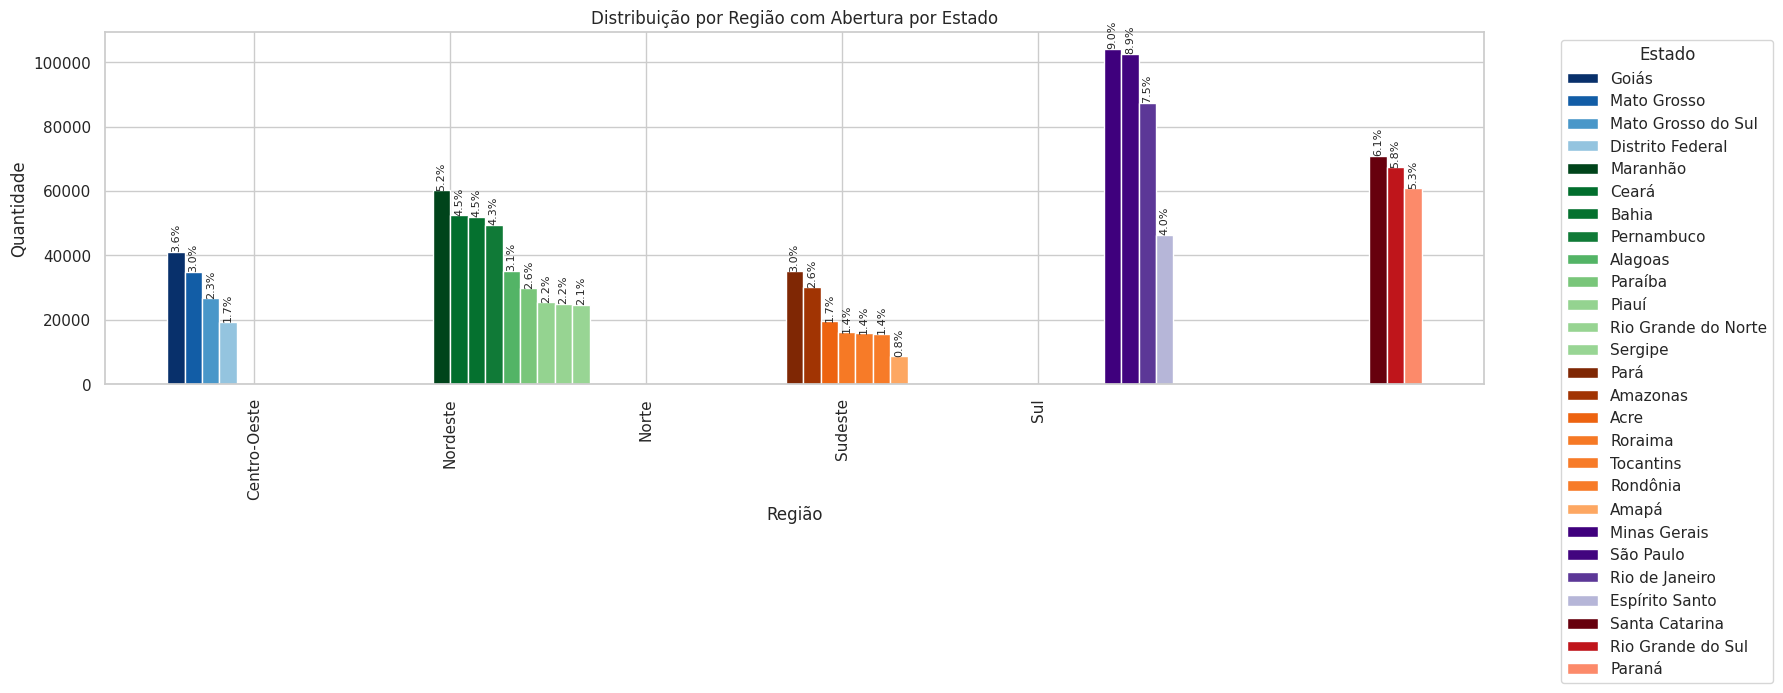


Distribuição por Região e Estado:



,regiao,estado,count,percentual
0,Centro-Oeste,Goiás,41211,3.56%
1,Centro-Oeste,Mato Grosso,34918,3.02%
2,Centro-Oeste,Mato Grosso do Sul,26798,2.31%
3,Centro-Oeste,Distrito Federal,19409,1.68%
4,Nordeste,Maranhão,60256,5.20%
5,Nordeste,Ceará,52427,4.53%
6,Nordeste,Bahia,51935,4.48%
7,Nordeste,Pernambuco,49614,4.28%
8,Nordeste,Alagoas,35327,3.05%
9,Nordeste,Paraíba,29828,2.58%


In [ ]:
# Agrupando por região e abertura por estado
pdf = df_covid.groupby(["regiao", "estado"]).size().reset_index(name="count")

# Calcular percentual global
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenar por região e depois por quantidade
pdf = pdf.sort_values(by=["regiao", "count"], ascending=[True, False])

# Estrutura
regioes = pdf["regiao"].unique()
x = np.arange(len(regioes))

# Número máximo de estados por região
max_estados = pdf.groupby("regiao").size().max()
width = 0.8 / max_estados

plt.figure(figsize=(18,6))

# 5 paletas distintas
paletas_lista = [cm.Blues, cm.Greens, cm.Oranges, cm.Purples, cm.Reds]
paletas = {regiao: paletas_lista[i % 5] for i, regiao in enumerate(regioes)}

# Controle de legenda única
labels_usados = set()

for i, estado in enumerate(pdf["estado"].unique()):
    subset = pdf[pdf["estado"] == estado]

    pos = []
    valores = []
    percentuais = []
    cores = []

    for j, regiao in enumerate(regioes):
        linha = subset[subset["regiao"] == regiao]

        if not linha.empty:
            pos.append(x[j] - 0.4 + i*width)

            valores.append(linha["count"].values[0])
            percentuais.append(linha["percentual"].values[0])

            # normalização dentro da região
            regiao_vals = pdf[pdf["regiao"] == regiao]["count"]
            norm = (linha["count"].values[0] - regiao_vals.min()) / (
                regiao_vals.max() - regiao_vals.min() + 1e-9
            )

            cores.append(paletas[regiao](0.4 + 0.6 * norm))

    # legenda sem duplicação
    label = estado if estado not in labels_usados else None
    labels_usados.add(estado)

    bars = plt.bar(pos, valores, width=width, color=cores, label=label)

    # Rótulos (%)
    for k, bar in enumerate(bars):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{percentuais[k]:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

plt.xticks(x, regioes, rotation=90)
plt.title("Distribuição por Região com Abertura por Estado")
plt.xlabel("Região")
plt.ylabel("Quantidade")
plt.legend(title="Estado", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

pdf_display = pdf.copy().reset_index(drop=True)
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Região e Estado:\n")
display(pdf_display)

###🔍 Principais pontos de análise

Como destacado antes, o Sudeste, mesmo com uma menor representação em número de estados (4), tem distribuição pouco abaixo do Nordeste, com 9 estados.

---

### 📊 Distribuição de Sintomas Reportados

Este gráfico apresenta a frequência dos principais sintomas reportados pelos entrevistados, permitindo identificar quais manifestações são mais comuns entre os casos analisados. Essa análise é importante para entender o padrão clínico predominante da doença na população estudada.

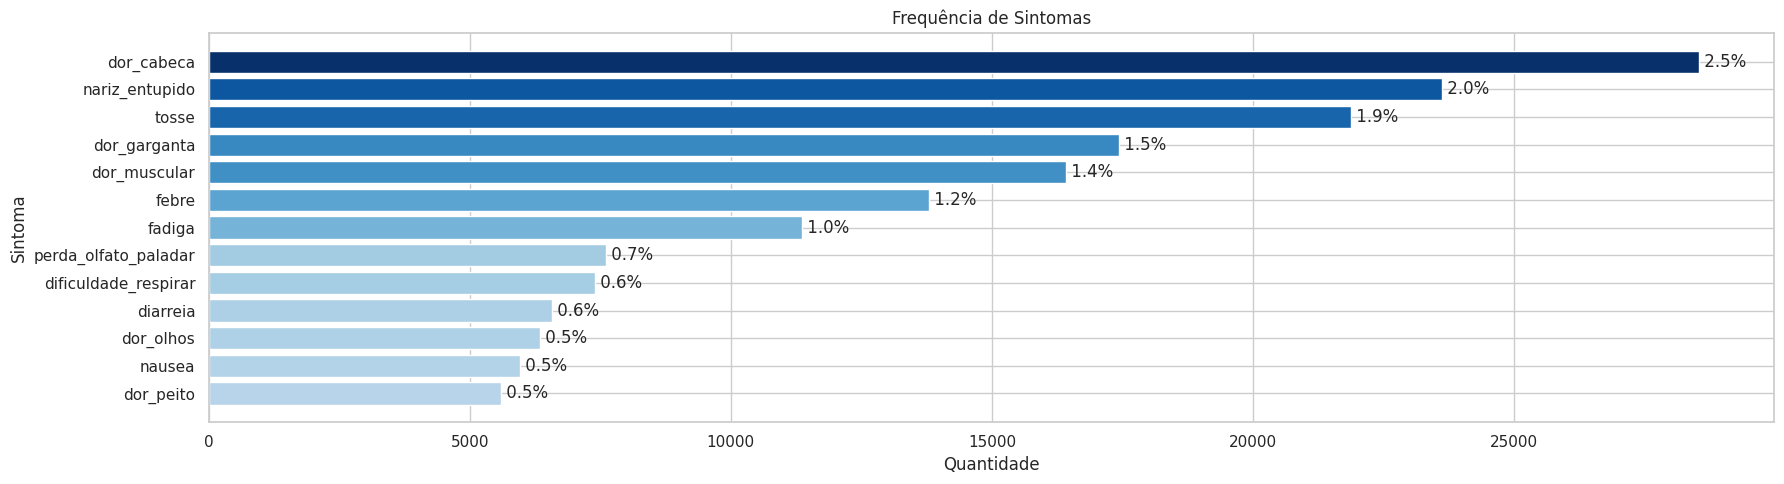


Frequência de Sintomas:



,sintoma,total,percentual
0,dor_cabeca,28548,2.47%
1,nariz_entupido,23617,2.04%
2,tosse,21885,1.89%
3,dor_garganta,17433,1.51%
4,dor_muscular,16416,1.42%
5,febre,13796,1.19%
6,fadiga,11370,0.98%
7,perda_olfato_paladar,7604,0.66%
8,dificuldade_respirar,7410,0.64%
9,diarreia,6583,0.57%


In [ ]:
# Frequência dos sintomas

sintomas = [
    "febre","tosse","dor_garganta","dificuldade_respirar",
    "dor_cabeca","dor_peito","nausea","nariz_entupido",
    "fadiga","dor_olhos","perda_olfato_paladar",
    "dor_muscular","diarreia"
]

dados = []

total_registros = len(df_covid)

for s in sintomas:
    total = (df_covid[s] == "Sim").sum()
    dados.append((s, total))

pdf = pd.DataFrame(dados, columns=["sintoma", "total"])

# Percentual
pdf["percentual"] = (pdf["total"] / total_registros) * 100

# Ordenar
pdf = pdf.sort_values(by="total", ascending=False)

# Normalizar valores para escala de cor
norm = (pdf["total"] - pdf["total"].min()) / (pdf["total"].max() - pdf["total"].min())

# Aplicar colormap (quanto maior, mais escuro)
cores = cm.Blues(0.3 + 0.7 * norm)

# Plot
plt.figure(figsize=(18,5))
bars = plt.barh(pdf["sintoma"], pdf["total"], color=cores)

# Percentual nos rótulos
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f' {pct:.1f}%',
        va='center'
    )

plt.title("Frequência de Sintomas")
plt.xlabel("Quantidade")
plt.ylabel("Sintoma")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


pdf_display = pdf.copy().reset_index(drop=True)
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nFrequência de Sintomas:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- **Dor de cabeça (2,47%)**, **nariz entupido (2,04%)** e **tosse (1,89%)** são os sintomas mais frequentes.
- Sintomas clássicos como **febre (1,19%)** aparecem com menor incidência do que sintomas mais leves.
- **Dor de garganta (1,51%)** e **dor muscular (1,42%)** também apresentam presença relevante na amostra.
- Sintomas mais específicos da COVID-19, como **perda de olfato/paladar (0,66%)**, aparecem com menor frequência.
- Sintomas mais graves, como **dificuldade para respirar (0,64%)** e **dor no peito (0,48%)**, possuem baixa incidência.

Os dados sugerem uma predominância de **sintomas leves a moderados**, como:

- dor de cabeça  
- congestão nasal  
- tosse  
- dor de garganta  

Enquanto sintomas mais severos ou específicos aparecem em menor proporção, o que pode indicar:

- grande volume de casos leves na amostra  
- possível subnotificação de sintomas mais graves  
- perfil populacional menos afetado por quadros severos  

A distribuição dos sintomas reforça a importância de considerar múltiplos sinais clínicos na triagem, durante os atendimentos, e não apenas os mais clássicos como febre e dificuldade respiratória.

---

### 📊 Distribuição por Cluster de Sintomas

Este gráfico apresenta a segmentação dos entrevistados de acordo com a quantidade de sintomas reportados, permitindo avaliar o nível de intensidade dos quadros clínicos na população analisada.

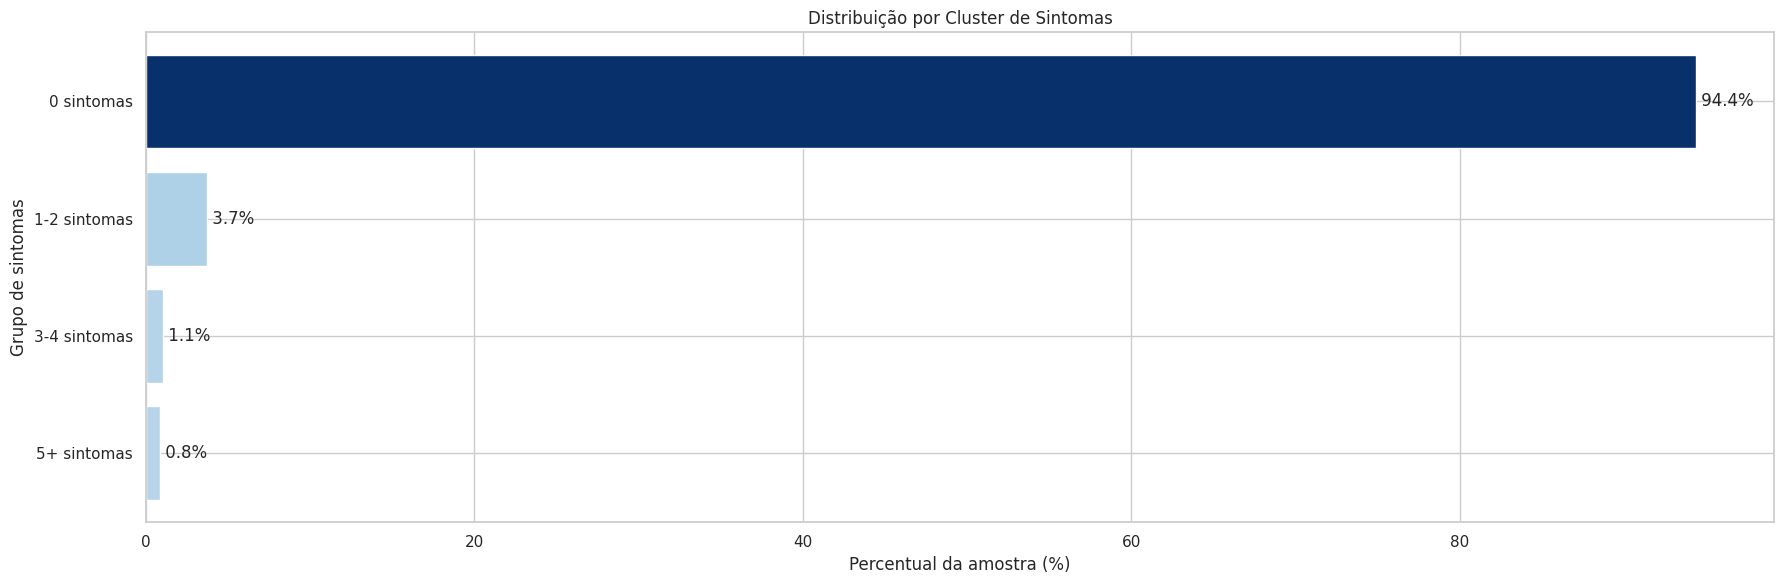


Distribuição por Cluster de Sintomas:



,grupo,total,percentual
0,0 sintomas,1093138,94.40%
1,1-2 sintomas,42806,3.70%
2,3-4 sintomas,12237,1.06%
3,5+ sintomas,9803,0.85%


In [ ]:
# Contagem dos sintomas
df_cluster = df_covid.copy()
df_cluster["qtd_sintomas"] = sum(
    (df_cluster[s] == "Sim").astype(int) for s in [
        "febre","tosse","dor_garganta","dificuldade_respirar",
        "dor_cabeca","dor_peito","nausea","nariz_entupido",
        "fadiga","dor_olhos","perda_olfato_paladar",
        "dor_muscular","diarreia"
    ]
)

# Criação dos clusters
def classificar(qtd):
    if qtd == 0:
        return "0 sintomas"
    elif qtd <= 2:
        return "1-2 sintomas"
    elif qtd <= 4:
        return "3-4 sintomas"
    else:
        return "5+ sintomas"

df_cluster["grupo_sintomas"] = df_cluster["qtd_sintomas"].apply(classificar)

# Agregação
pdf = (
    df_cluster["grupo_sintomas"]
    .value_counts()
    .reset_index()
)

pdf.columns = ["grupo", "total"]

# Ordenar corretamente
ordem = ["0 sintomas", "1-2 sintomas", "3-4 sintomas", "5+ sintomas"]
pdf["grupo"] = pd.Categorical(pdf["grupo"], categories=ordem, ordered=True)
pdf = pdf.sort_values("grupo")

# Percentual
total_amostra = len(df_cluster)
pdf["percentual"] = (pdf["total"] / total_amostra) * 100

# Cores Monocromáticas
norm = (pdf["percentual"] - pdf["percentual"].min()) / (
    pdf["percentual"].max() - pdf["percentual"].min()
)

cores = cm.Blues(0.3 + 0.7 * norm)

# Plot
plt.figure(figsize=(18,6))
bars = plt.barh(pdf["grupo"], pdf["percentual"], color=cores)

# Rótulos percentuais
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f" {pct:.1f}%",
        va="center"
    )

plt.title("Distribuição por Cluster de Sintomas")
plt.xlabel("Percentual da amostra (%)")
plt.ylabel("Grupo de sintomas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Cluster de Sintomas:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A grande maioria dos entrevistados (**94,40%**) não apresentou nenhum sintoma.
- Cerca de **3,70%** reportaram **1 a 2 sintomas**, indicando predominância de casos leves.
- Apenas **1,06%** apresentaram **3 a 4 sintomas**, sugerindo menor incidência de quadros moderados.
- Os casos mais intensos (**5 ou mais sintomas**) representam somente **0,85%** da amostra.

Os dados evidenciam uma forte concentração em indivíduos **assintomáticos ou com poucos sintomas**, indicando:

- possível alta proporção de casos não detectados clinicamente  
- presença significativa de infecções leves ou subclínicas  
- possível impacto relevante na disseminação silenciosa da doença  

A baixa participação de clusters com múltiplos sintomas pode estar associada a:

- menor ocorrência de casos graves na amostra  
- viés de coleta (população geral vs. hospitalizada)  
- características demográficas dos entrevistados  

A distribuição reforça um padrão onde a maioria dos casos apresenta **baixa severidade**, sendo essencial considerar esse comportamento em análises epidemiológicas e estratégias de monitoramento.

---

### 📊 Distribuição de Sintomas por Faixa Etária

Este gráfico apresenta a incidência percentual de sintomas segmentada por faixa etária, permitindo identificar padrões clínicos distintos entre grupos de idade e possíveis variações na manifestação da doença.

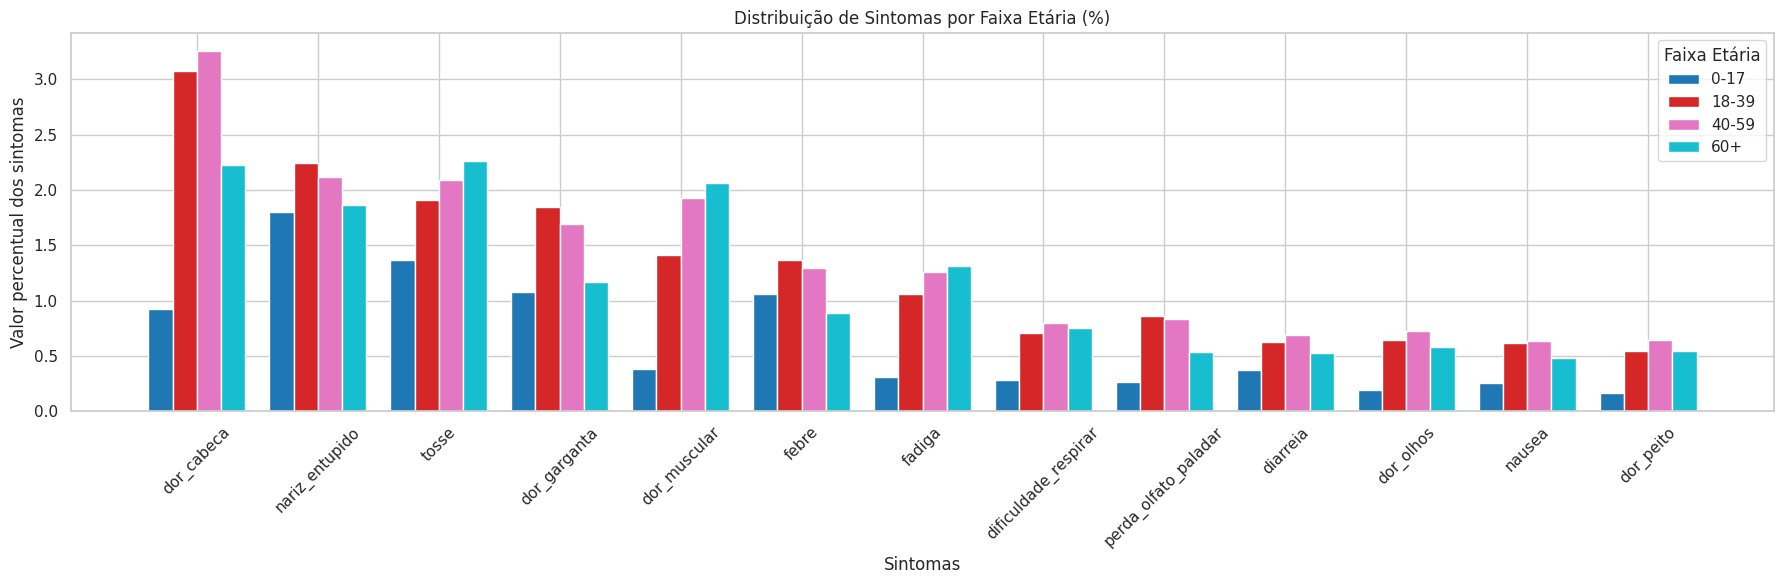


Tabela - Percentual por Sintoma e Faixa Etária:



/tmp/ipykernel_4556/1943555459.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_display = pivot_display.applymap(lambda x: f"{x:.2f}%")


faixa_etaria,0-17,18-39,40-59,60+
sintoma,,,,
dor_cabeca,0.93%,3.07%,3.26%,2.23%
nariz_entupido,1.80%,2.25%,2.11%,1.87%
tosse,1.37%,1.91%,2.09%,2.26%
dor_garganta,1.08%,1.85%,1.70%,1.17%
dor_muscular,0.38%,1.41%,1.92%,2.06%
febre,1.06%,1.37%,1.30%,0.89%
fadiga,0.31%,1.06%,1.26%,1.32%
dificuldade_respirar,0.29%,0.71%,0.80%,0.75%
perda_olfato_paladar,0.27%,0.86%,0.83%,0.54%


In [ ]:
# Influência da faixa etária nos sintomas relatados

sintomas = [
    "febre","tosse","dor_garganta","dificuldade_respirar",
    "dor_cabeca","dor_peito","nausea","nariz_entupido",
    "fadiga","dor_olhos","perda_olfato_paladar",
    "dor_muscular","diarreia"
]


# Base por faixa
dados = []

for faixa in df_covid["faixa_etaria"].dropna().unique():
    df_faixa = df_covid[df_covid["faixa_etaria"] == faixa]
    total_faixa = len(df_faixa)

    for s in sintomas:
        total = (df_faixa[s] == "Sim").sum()
        percentual = (total / total_faixa) * 100 if total_faixa > 0 else 0

        dados.append((faixa, s, percentual))

pdf = pd.DataFrame(dados, columns=["faixa_etaria", "sintoma", "percentual"])

# Pivot
pivot = pdf.pivot(index="sintoma", columns="faixa_etaria", values="percentual")

# Ordenar sintomas por média
pivot["media"] = pivot.mean(axis=1)
pivot = pivot.sort_values(by="media", ascending=False).drop(columns="media")

# Ordenar faixa etária corretamente
def extrair_inicio(faixa):
    match = re.search(r'\d+', str(faixa))
    return int(match.group()) if match else 999

ordem = sorted(pivot.columns, key=extrair_inicio)
pivot = pivot[ordem]


# Plot
plt.figure(figsize=(18,6))
x = np.arange(len(pivot.index))
width = 0.8 / len(pivot.columns)

# Cores distintas
cores = plt.cm.tab10(np.linspace(0, 1, len(pivot.columns)))

for i, faixa in enumerate(pivot.columns):
    plt.bar(
        x + i * width,
        pivot[faixa],
        width=width,
        label=faixa,
        color=cores[i]
    )

# Ajustes visuais
plt.xticks(x + width * (len(pivot.columns)-1)/2, pivot.index, rotation=45)
plt.title("Distribuição de Sintomas por Faixa Etária (%)")
plt.xlabel("Sintomas")
plt.ylabel("Valor percentual dos sintomas")
plt.legend(title="Faixa Etária")
plt.tight_layout()
plt.show()

pivot_display = pivot.round(2).copy()

# Converter para percentual formatado
pivot_display = pivot_display.applymap(lambda x: f"{x:.2f}%")

print("\nTabela - Percentual por Sintoma e Faixa Etária:\n")
display(pivot_display)

### 🔍 Principais pontos de análise

- A faixa **40-59 anos** apresenta, em geral, os maiores percentuais para diversos sintomas, como:
  - **dor de cabeça (3,26%)**
  - **dor muscular (1,92%)**
  - **fadiga (1,26%)**

- A faixa **18-39 anos** também se destaca com alta incidência de sintomas leves a moderados, especialmente:
  - **dor de cabeça (3,07%)**
  - **nariz entupido (2,25%)**
  - **tosse (1,91%)**

- A população **60+** apresenta maior incidência em sintomas associados a quadros mais sensíveis:
  - **tosse (2,26%)**
  - **dor muscular (2,06%)**
  - **fadiga (1,32%)**

- A faixa **0-17 anos** possui os menores percentuais em praticamente todos os sintomas, indicando:
  - menor manifestação sintomática  
  - maior presença de casos leves ou assintomáticos  

- Sintomas como **dificuldade para respirar** e **dor no peito** aumentam com a idade, ainda que com baixa incidência geral.

- A **perda de olfato/paladar** é mais comum em adultos (18-59 anos) e menos frequente em crianças e idosos.

Os dados sugerem uma relação clara entre **idade e intensidade/variedade de sintomas**, com destaque para:

- maior carga sintomática em adultos de meia-idade  
- menor expressão clínica em jovens  
- sintomas potencialmente mais críticos em idosos  

A análise reforça a importância de segmentar dados por faixa etária, já que o comportamento da doença varia significativamente entre os grupos, impactando estratégias de prevenção, diagnóstico e tratamento.

---

### 📊 Distribuição por Status do Teste

Este gráfico apresenta a distribuição dos entrevistados de acordo com o status do teste realizados para COVID-19, permitindo avaliar o nível de testagem e a confirmação de casos na população analisada.

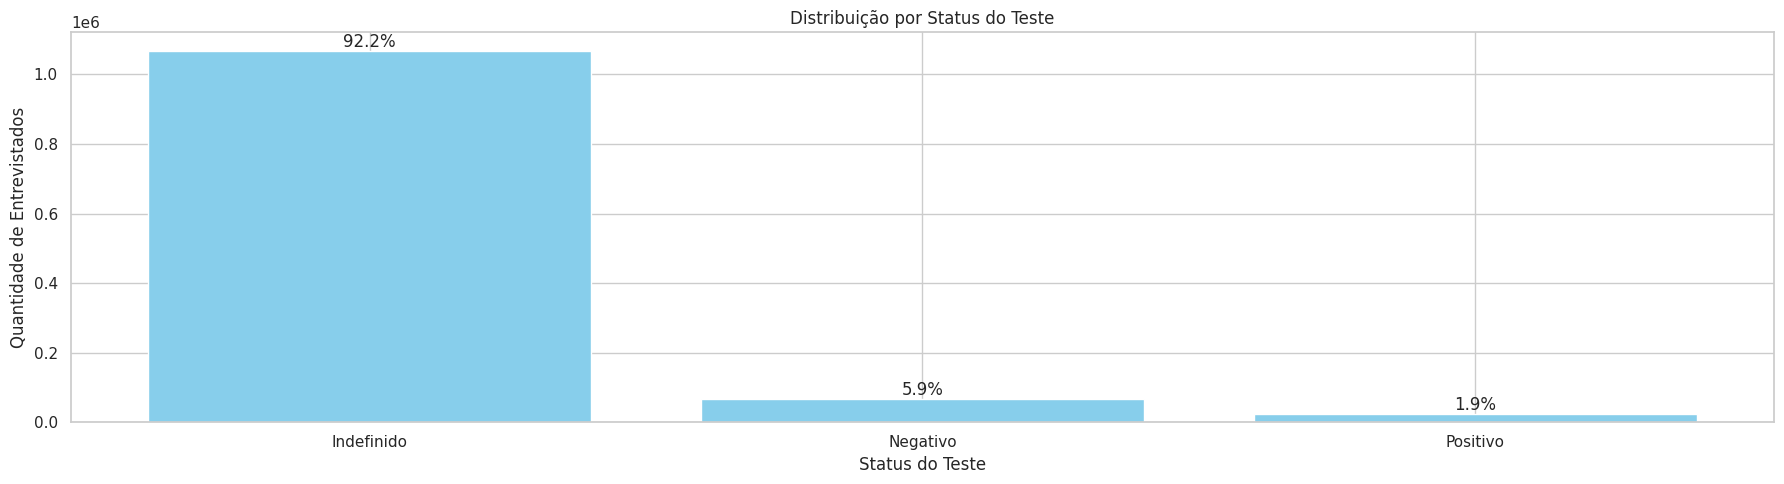


Distribuição por Status do Teste:



,status_teste,count,percentual
0,Indefinido,1067691,92.20%
1,Negativo,67808,5.86%
2,Positivo,22485,1.94%


In [ ]:
# Realização dos testes de covid
pdf = df_covid.groupby("status_teste").size().reset_index(name="count")

# Calculando percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenando os dados
pdf = pdf.sort_values(by="count", ascending=False)

# Plot
plt.figure(figsize=(18,5))
bars = plt.bar(pdf["status_teste"], pdf["count"], color="skyblue")

# Rótulos (%)
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title("Distribuição por Status do Teste")
plt.xlabel("Status do Teste")
plt.ylabel("Quantidade de Entrevistados")
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Status do Teste:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A grande maioria dos registros (**92,20%**) está classificada como **indefinida**, indicando ausência de teste ou informação não reportada.
- Apenas **5,86%** dos entrevistados testaram **negativo** para a doença.
- Os casos **positivos confirmados** representam **1,94%** da amostra.

Os dados evidenciam uma **baixa cobertura de testagem**, o que pode indicar:

- limitação no acesso a testes durante o período da pesquisa  
- alto volume de casos não confirmados oficialmente  
- possível subnotificação da real incidência da doença  

A predominância de status indefinido impacta diretamente a análise epidemiológica, pois:

- dificulta a identificação precisa da taxa de infecção  
- limita a confiabilidade de análises baseadas apenas em casos confirmados  
- reforça a necessidade de cruzamento com dados de sintomas  

A distribuição sugere que os dados de teste devem ser interpretados com cautela, sendo essencial considerar outras variáveis (como sintomas) para uma análise mais robusta da situação.

---

### 📊 Distribuição por Status do Teste (Apenas Testados)

Este gráfico apresenta a distribuição dos resultados entre os entrevistados que **realizaram algum tipo de teste**, excluindo os casos indefinidos.

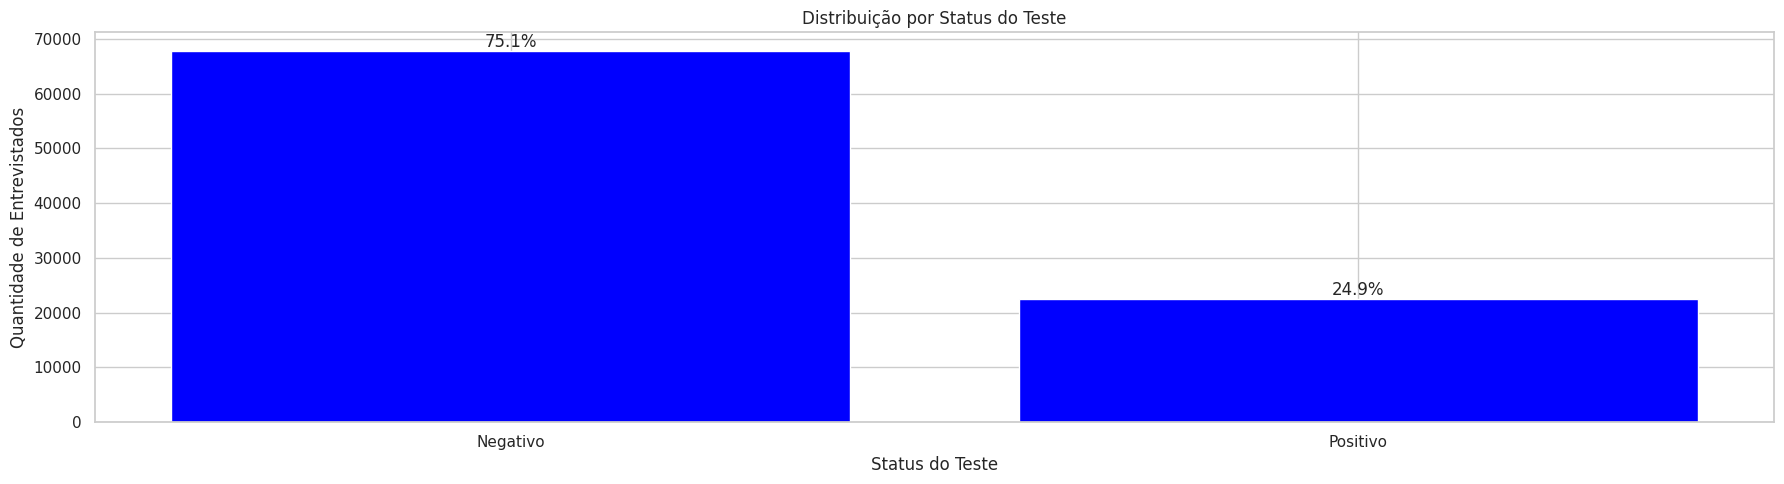


Distribuição por Status do Teste:



,status_teste,count,percentual
1,Negativo,67808,75.10%
2,Positivo,22485,24.90%


In [ ]:
# Realização dos testes de covid
pdf = df_covid.groupby("status_teste").size().reset_index(name="count")

# Removendo status "Indefinido"
pdf = pdf[pdf["status_teste"] != "Indefinido"]

# Calculando percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenando os dados
pdf = pdf.sort_values(by="count", ascending=False)

# Plot
plt.figure(figsize=(18,5))
bars = plt.bar(pdf["status_teste"], pdf["count"], color="blue")

# Rótulos (%)
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title("Distribuição por Status do Teste")
plt.xlabel("Status do Teste")
plt.ylabel("Quantidade de Entrevistados")
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição por Status do Teste:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A maioria dos testados (**75,10%**) apresentou resultado **negativo**.
- Cerca de **24,90%** dos testes realizados e reportados foram **positivos**, indicando uma taxa relevante de confirmação entre os testados.

A análise revela que, entre os indivíduos testados, aproximadamente **1 em cada 4 apresentou resultado positivo**, sugerindo uma incidência significativa dentro do grupo que buscou testagem.

---

### 📊 Status do Teste por Faixa Etária

Este gráfico apresenta a distribuição dos resultados de teste por faixa etária, considerando apenas os indivíduos que realizaram testagem.

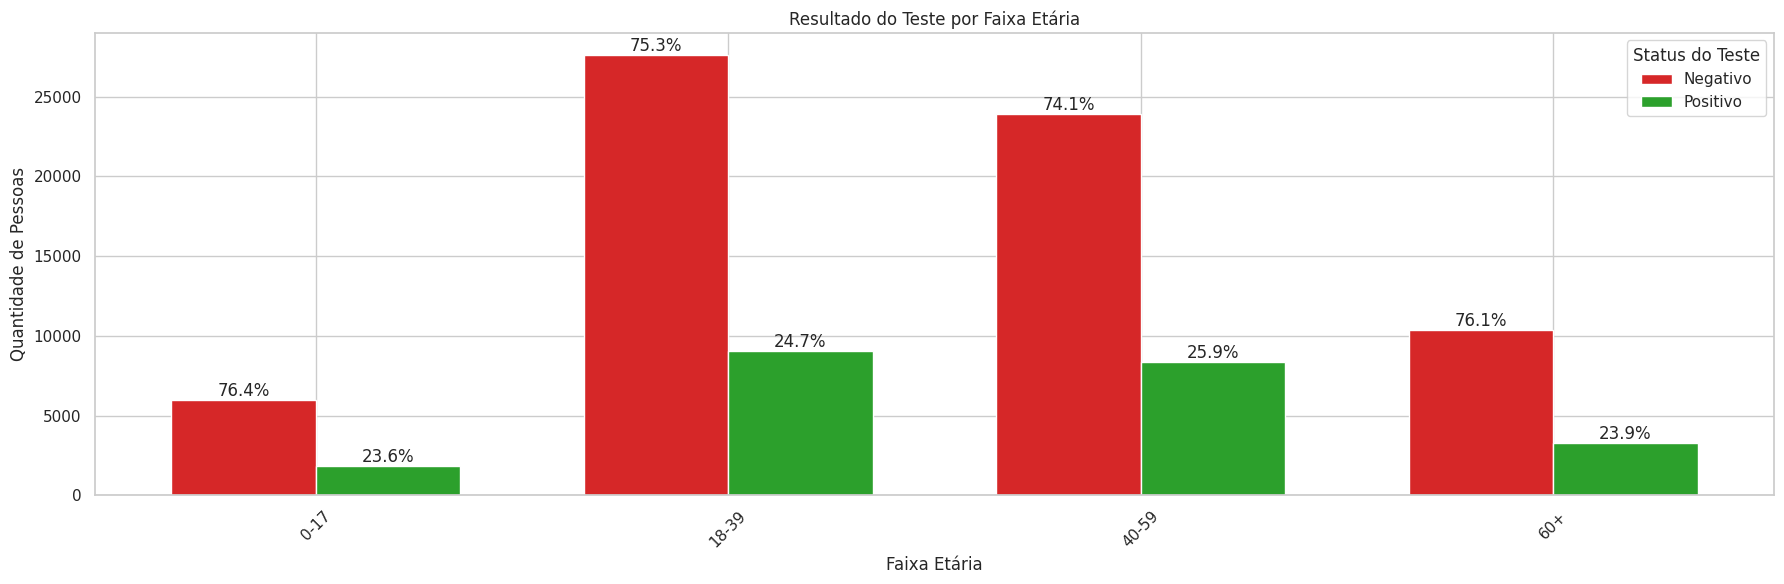


Quantidade:



/tmp/ipykernel_4556/3396064874.py:69: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")


status_teste,Negativo,Positivo
faixa_etaria,,
0-17,5949,1836
18-39,27612,9060
40-59,23901,8337
60+,10346,3252



Percentual dentro da faixa etária:



status_teste,Negativo,Positivo
faixa_etaria,,
0-17,76.42%,23.58%
18-39,75.29%,24.71%
40-59,74.14%,25.86%
60+,76.08%,23.92%


In [ ]:
# Avaliando o resultado dos testes de covid realizados, por faixa etária

df_analise = df_covid[df_covid["status_teste"].isin(["Positivo", "Negativo"])].copy()

# Agrupamento
pdf = df_analise.groupby(["faixa_etaria", "status_teste"]).size().reset_index(name="total")

# Total por faixa (para percentual)
totais_faixa = pdf.groupby("faixa_etaria")["total"].transform("sum")
pdf["percentual"] = (pdf["total"] / totais_faixa) * 100

# Pivot
pivot = pdf.pivot(index="faixa_etaria", columns="status_teste", values="total").fillna(0)
pivot_pct = pdf.pivot(index="faixa_etaria", columns="status_teste", values="percentual").fillna(0)

# Ordenando por faixa etária
def extrair_inicio(faixa):
    match = re.search(r'\d+', str(faixa))
    return int(match.group()) if match else 999

pivot = pivot.sort_index(key=lambda x: x.map(extrair_inicio))
pivot_pct = pivot_pct.loc[pivot.index]

# Cores
cores_map = {
    "Positivo": "#2ca02c",   # verde
    "Negativo": "#d62728"    # vermelho
}

# Plot
x = np.arange(len(pivot.index))
width = 0.35
bars_list = []

for i, col in enumerate(pivot.columns):
    bars = plt.bar(
        x + i * width,
        pivot[col],
        width=width,
        label=col,
        color=cores_map[col]
    )
    bars_list.append(bars)

# Rótulos
for i, col in enumerate(pivot.columns):
    for j, bar in enumerate(bars_list[i]):
        height = bar.get_height()
        pct = pivot_pct.iloc[j][col]

        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{pct:.1f}%",
                ha="center",
                va="bottom"
            )

plt.xticks(x + width/2, pivot.index, rotation=45)
plt.title("Resultado do Teste por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade de Pessoas")
plt.legend(title="Status do Teste")
plt.tight_layout()
plt.show()

pivot_display = pivot.copy()
pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")

print("\nQuantidade:\n")
display(pivot_display)

print("\nPercentual dentro da faixa etária:\n")
display(pivot_pct_display)

### 🔍 Principais pontos de análise

- A proporção de resultados **negativos predomina em todas as faixas etárias**, variando entre **74% e 76%**.
- A faixa **40-59 anos** apresenta a maior taxa de **positivos (25,86%)**, indicando maior incidência relativa nesse grupo.
- As faixas **18-39 anos (24,71%)** e **60+ (23,92%)** também apresentam proporções relevantes e próximas entre si.
- A faixa **0-17 anos (23,58%)** possui a menor taxa de positividade.

De forma geral, a taxa de positividade se mantém **relativamente estável entre as idades**, com leve aumento em adultos de meia-idade.

A análise sugere um comportamento homogêneo entre os grupos etários, com **leve maior incidência em adultos (40-59 anos)**, sem variações abruptas entre as faixas.

---

### 📊 Status do Teste por Região

Este gráfico apresenta a distribuição dos resultados de teste por região, considerando apenas os indivíduos que realizaram testagem.

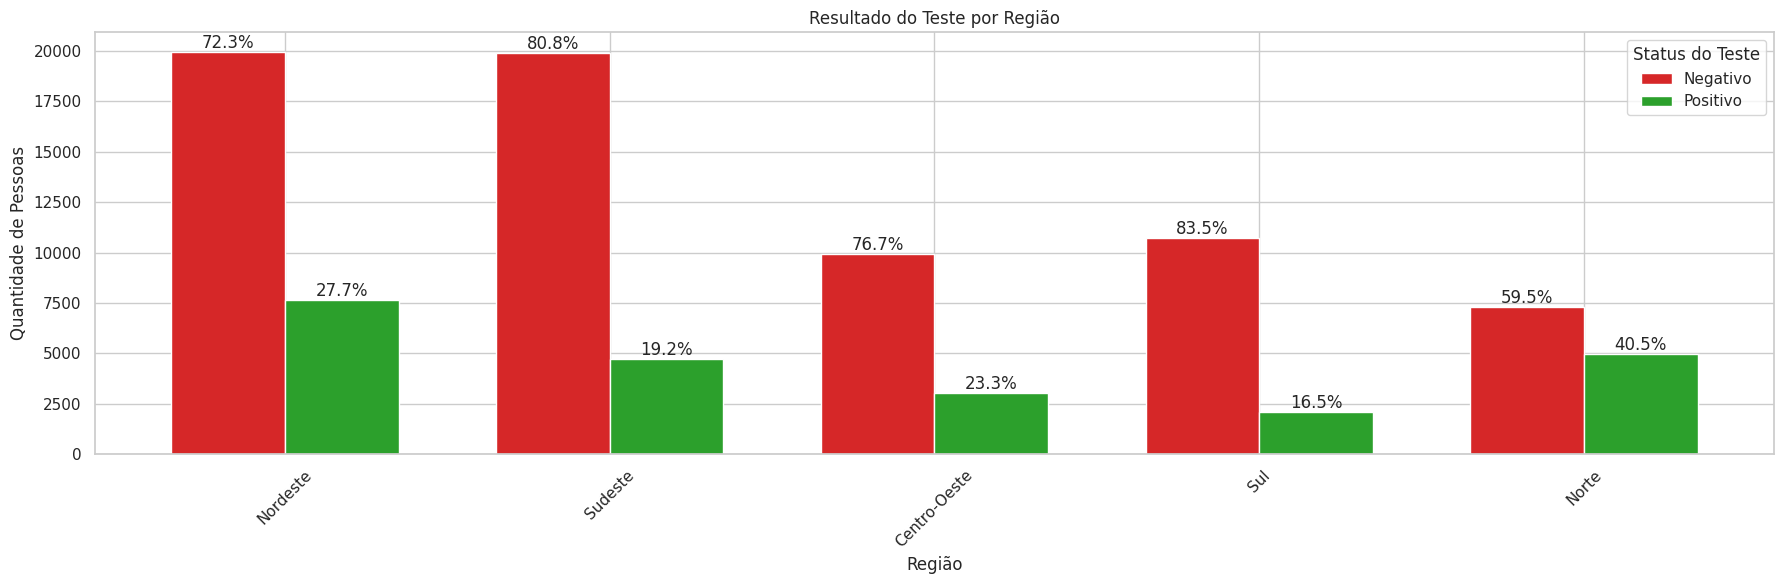


Quantidade:



/tmp/ipykernel_4556/2876115322.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")


status_teste,Negativo,Positivo
regiao,,
Nordeste,19925,7640
Sudeste,19886,4722
Centro-Oeste,9956,3031
Sul,10728,2123
Norte,7313,4969



Percentual dentro da região:



status_teste,Negativo,Positivo
regiao,,
Nordeste,72.28%,27.72%
Sudeste,80.81%,19.19%
Centro-Oeste,76.66%,23.34%
Sul,83.48%,16.52%
Norte,59.54%,40.46%


In [ ]:
# Avaliando o resultado dos testes de covid realizados, por região

df_analise = df_covid[df_covid["status_teste"].isin(["Positivo", "Negativo"])].copy()

# Agrupamento
pdf = df_analise.groupby(["regiao", "status_teste"]).size().reset_index(name="total")

# Total por região (para percentual)
totais_regiao = pdf.groupby("regiao")["total"].transform("sum")
pdf["percentual"] = (pdf["total"] / totais_regiao) * 100

# Pivot
pivot = pdf.pivot(index="regiao", columns="status_teste", values="total").fillna(0)
pivot_pct = pdf.pivot(index="regiao", columns="status_teste", values="percentual").fillna(0)

# (Opcional) ordenar por total de casos
pivot["total_geral"] = pivot.sum(axis=1)
pivot = pivot.sort_values(by="total_geral", ascending=False).drop(columns="total_geral")
pivot_pct = pivot_pct.loc[pivot.index]

# Cores
cores_map = {
    "Positivo": "#2ca02c",   # verde
    "Negativo": "#d62728"    # vermelho
}

# Plot
x = np.arange(len(pivot.index))
width = 0.35
bars_list = []

for i, col in enumerate(pivot.columns):
    bars = plt.bar(
        x + i * width,
        pivot[col],
        width=width,
        label=col,
        color=cores_map[col]
    )
    bars_list.append(bars)

# Rótulos (%)
for i, col in enumerate(pivot.columns):
    for j, bar in enumerate(bars_list[i]):
        height = bar.get_height()
        pct = pivot_pct.iloc[j][col]

        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{pct:.1f}%",
                ha="center",
                va="bottom"
            )

plt.xticks(x + width/2, pivot.index, rotation=45)
plt.title("Resultado do Teste por Região")
plt.xlabel("Região")
plt.ylabel("Quantidade de Pessoas")
plt.legend(title="Status do Teste")
plt.tight_layout()
plt.show()

pivot_display = pivot.copy()
pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")

print("\nQuantidade:\n")
display(pivot_display)

print("\nPercentual dentro da região:\n")
display(pivot_pct_display)

### 🔍 Principais pontos de análise

- A região **Norte** apresenta a maior taxa de **positivos (40,46%)**, destacando-se significativamente das demais.
- O **Nordeste (27,72%)** e o **Centro-Oeste (23,34%)** também possuem proporções relevantes de positividade.
- O **Sudeste (19,19%)** e o **Sul (16,52%)** apresentam as menores taxas de casos positivos.

- Em contrapartida, o **Sul (83,48%)** e o **Sudeste (80,81%)** lideram em resultados **negativos**, indicando menor incidência relativa nessas regiões.

Os dados revelam diferenças regionais importantes, com destaque para:

- maior incidência proporcional no **Norte**  
- menor incidência nas regiões **Sul e Sudeste**  

A análise reforça a existência de **desigualdades regionais na disseminação da doença**, sendo essencial considerar o contexto geográfico em avaliações epidemiológicas.

---

### 📊 Status do Teste por Nível de Isolamento

Este gráfico apresenta a distribuição dos resultados de teste conforme o nível de isolamento adotado pelos entrevistados.

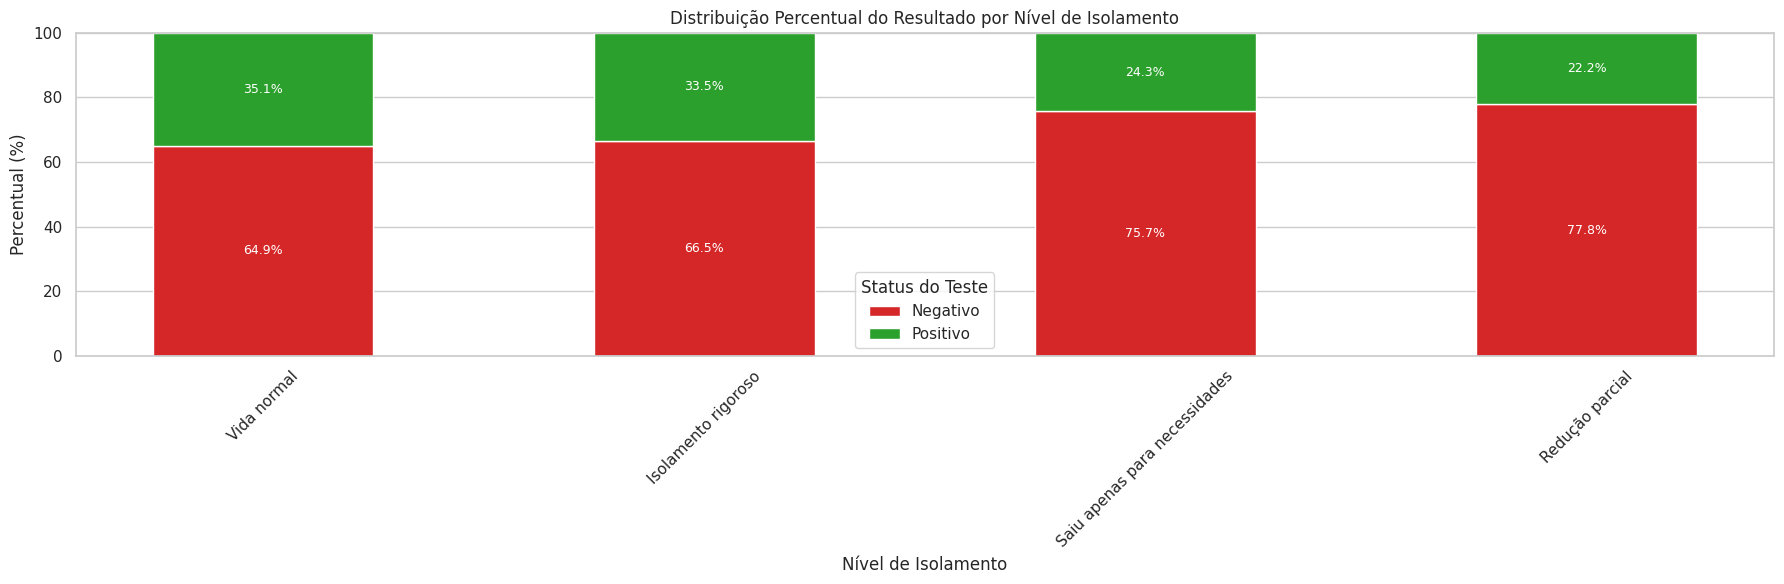


Quantidade de casos (Positivo/Negativo):



/tmp/ipykernel_4556/1995891270.py:73: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")


status_teste,Negativo,Positivo
nivel_isolamento,,
Vida normal,1833,991
Isolamento rigoroso,8335,4207
Saiu apenas para necessidades,23174,7446
Redução parcial,34364,9793



Percentual dentro do nível de isolamento:



status_teste,Negativo,Positivo
nivel_isolamento,,
Vida normal,64.91%,35.09%
Isolamento rigoroso,66.46%,33.54%
Saiu apenas para necessidades,75.68%,24.32%
Redução parcial,77.82%,22.18%


In [ ]:
# Avaliando o resultado dos testes de covid por nível de isolamento (em %)

df_analise = df_covid[
    (df_covid["status_teste"].isin(["Positivo", "Negativo"])) &
    (df_covid["nivel_isolamento"] != "Não respondido/ignorado")
].copy()

# Agrupamento
pdf = df_analise.groupby(["nivel_isolamento", "status_teste"]).size().reset_index(name="total")

# Percentual dentro de cada nível
totais_nivel = pdf.groupby("nivel_isolamento")["total"].transform("sum")
pdf["percentual"] = (pdf["total"] / totais_nivel) * 100

# Pivot percentual (para o gráfico)
pivot_pct = pdf.pivot(index="nivel_isolamento", columns="status_teste", values="percentual").fillna(0)

# Ordenar por maior % de positivos
pivot_pct = pivot_pct.sort_values(by="Positivo", ascending=False)

# Pivot de totais (para display)
pivot_total = pdf.pivot(index="nivel_isolamento", columns="status_teste", values="total").fillna(0)
pivot_total = pivot_total.loc[pivot_pct.index]

# Cores fixas
cores_map = {
    "Positivo": "#2ca02c",   # verde
    "Negativo": "#d62728"    # vermelho
}

# Plot (100% empilhado)
x = np.arange(len(pivot_pct.index))
width = 0.5
bars_list = []

for i, col in enumerate(pivot_pct.columns):
    bars = plt.bar(
        x,
        pivot_pct[col],
        width=width,
        bottom=pivot_pct.iloc[:, :i].sum(axis=1) if i > 0 else None,
        label=col,
        color=cores_map[col]
    )
    bars_list.append(bars)

# Rótulos (%)
for i, col in enumerate(pivot_pct.columns):
    for j, bar in enumerate(bars_list[i]):
        height = bar.get_height()

        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f"{height:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )

plt.xticks(x, pivot_pct.index, rotation=45)
plt.title("Distribuição Percentual do Resultado por Nível de Isolamento")
plt.xlabel("Nível de Isolamento")
plt.ylabel("Percentual (%)")
plt.ylim(0, 100)
plt.legend(title="Status do Teste")
plt.tight_layout()
plt.show()

# Percentual
pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")

# Totais
pivot_total_display = pivot_total.copy().astype(int)

print("\nQuantidade de casos (Positivo/Negativo):\n")
display(pivot_total_display)

print("\nPercentual dentro do nível de isolamento:\n")
display(pivot_pct_display)

### 🔍 Principais pontos de análise

- Indivíduos com **vida normal** apresentam a maior taxa de **positivos (35,09%)**, indicando maior exposição ao risco.
- O **isolamento rigoroso (33,54%)** ainda apresenta uma taxa elevada de positivos, possivelmente refletindo exposição prévia ou contexto de risco.
- Quem **saiu apenas para necessidades (24,32%)** já apresenta uma redução relevante na taxa de positividade.
- A **redução parcial (22,18%)** possui a menor proporção de casos positivos entre os grupos analisados.

- Em termos de negativos, **redução parcial (77,82%)** e **saídas controladas (75,68%)** concentram os maiores percentuais.

Os dados sugerem uma relação clara entre **nível de exposição e positividade**, onde:

- maior circulação → maior taxa de infecção  
- maior controle de mobilidade → menor incidência  

A análise reforça o impacto do **comportamento social** na disseminação da doença, evidenciando a importância de medidas de isolamento para redução do contágio, além da relevância do reforço de propagandas e políticas públicas que corraborem para estes tipos de atitudes em cenários pandêmicos.

---

### 📊 Status do Teste por Uso de Kit de Prevenção

Este gráfico apresenta a distribuição dos resultados de teste conforme o uso de kit de prevenção pelos entrevistados.

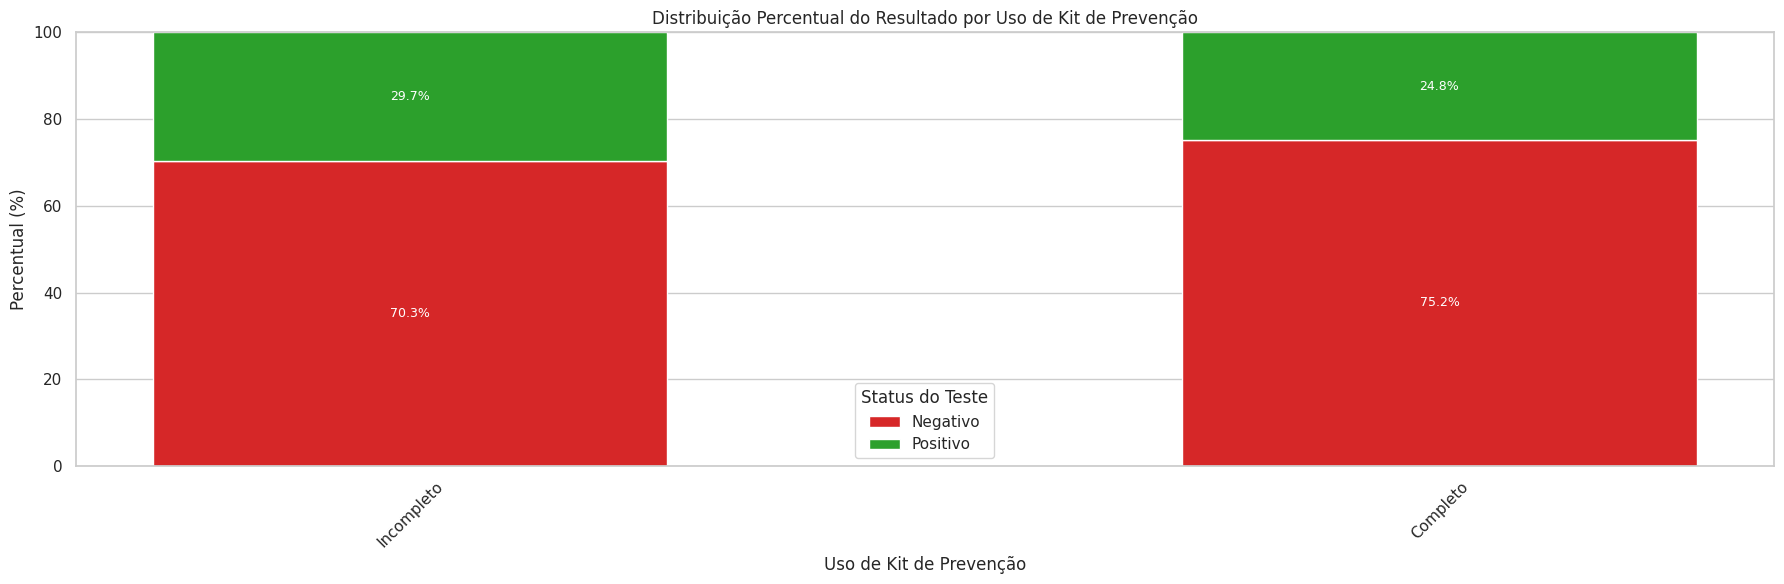


Quantidade de casos (Positivo/Negativo):



/tmp/ipykernel_4556/3733181513.py:76: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")


status_teste,Negativo,Positivo
kit_prevencao,,
Incompleto,1478,624
Completo,66330,21861



Percentual dentro do uso de kit de prevenção:



status_teste,Negativo,Positivo
kit_prevencao,,
Incompleto,70.31%,29.69%
Completo,75.21%,24.79%


In [ ]:
# Avaliando o resultado dos testes por uso de kit de prevenção (em %)

df_analise = df_covid[
    (df_covid["status_teste"].isin(["Positivo", "Negativo"])) &
    (df_covid["kit_prevencao"] != "Não respondido/ignorado")
].copy()

# Agrupamento
pdf = df_analise.groupby(["kit_prevencao", "status_teste"]).size().reset_index(name="total")

# Percentual dentro de cada grupo
totais = pdf.groupby("kit_prevencao")["total"].transform("sum")
pdf["percentual"] = (pdf["total"] / totais) * 100

# Pivot percentual (para gráfico)
pivot_pct = pdf.pivot(index="kit_prevencao", columns="status_teste", values="percentual").fillna(0)

# 🔥 Ordenar por maior % de positivos
pivot_pct = pivot_pct.sort_values(by="Positivo", ascending=False)

# Pivot total (para display)
pivot_total = pdf.pivot(index="kit_prevencao", columns="status_teste", values="total").fillna(0)
pivot_total = pivot_total.loc[pivot_pct.index]

# Cores
cores_map = {
    "Positivo": "#2ca02c",   # verde
    "Negativo": "#d62728"    # vermelho
}

# Plot (100% empilhado)
x = np.arange(len(pivot_pct.index))
width = 0.5
bars_list = []

for i, col in enumerate(pivot_pct.columns):
    bars = plt.bar(
        x,
        pivot_pct[col],
        width=width,
        bottom=pivot_pct.iloc[:, :i].sum(axis=1) if i > 0 else None,
        label=col,
        color=cores_map[col]
    )
    bars_list.append(bars)

# Rótulos (%)
for i, col in enumerate(pivot_pct.columns):
    for j, bar in enumerate(bars_list[i]):
        height = bar.get_height()

        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f"{height:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )

# Ajustes
plt.xticks(x, pivot_pct.index, rotation=45)
plt.title("Distribuição Percentual do Resultado por Uso de Kit de Prevenção")
plt.xlabel("Uso de Kit de Prevenção")
plt.ylabel("Percentual (%)")
plt.ylim(0, 100)
plt.legend(title="Status do Teste")
plt.tight_layout()
plt.show()

# DISPLAY

pivot_total_display = pivot_total.copy().astype(int)
pivot_pct_display = pivot_pct.copy().applymap(lambda x: f"{x:.2f}%")

print("\nQuantidade de casos (Positivo/Negativo):\n")
display(pivot_total_display)

print("\nPercentual dentro do uso de kit de prevenção:\n")
display(pivot_pct_display)

### 🔍 Principais pontos de análise

- Indivíduos com **kit incompleto** apresentam maior taxa de **positivos (29,69%)**.
- Já aqueles com **kit completo** possuem menor proporção de casos positivos (**24,79%**).

- Em relação aos resultados negativos:
  - **Kit completo (75,21%)** apresenta maior percentual  
  - **Kit incompleto (70,31%)** possui menor proporção  

Os dados sugerem que o uso adequado de medidas de prevenção está associado a uma **redução na taxa de infecção**.

A análise reforça a importância de **práticas preventivas completas** como fator relevante na diminuição do contágio.

---

### 📊 Distribuição de Infectados por Nível de Isolamento

Este gráfico apresenta como os casos **positivos** se distribuem de acordo com o nível de isolamento adotado pelos indivíduos.

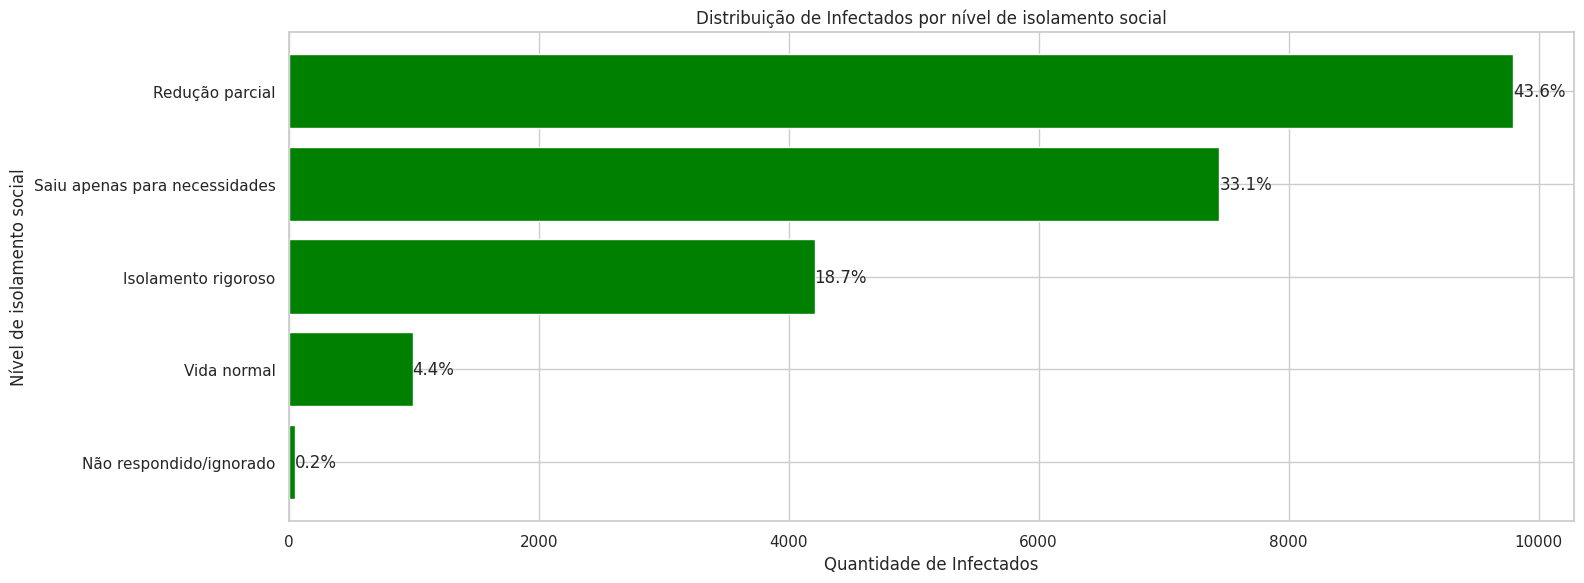


Distribuição de Infectados por Nível de isolamento:



,nivel_isolamento,count,percentual
2,Redução parcial,9793,43.55%
3,Saiu apenas para necessidades,7446,33.12%
0,Isolamento rigoroso,4207,18.71%
4,Vida normal,991,4.41%
1,Não respondido/ignorado,48,0.21%


In [ ]:
# Relação do perfil de nível de isolamento x infecção (resultado positivo do teste)

df_analise = df_covid[df_covid["status_teste"] == "Positivo"]

# Agrupando os dados
pdf = df_analise.groupby("nivel_isolamento").size().reset_index(name="count")

# Calculando o percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenando os dados
pdf = pdf.sort_values(by="count", ascending=False)

# Plot
plt.figure(figsize=(16,6))

bars = plt.barh(pdf["nivel_isolamento"], pdf["count"], color="green")
plt.gca().invert_yaxis()

# Rótulos (%)
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%',
        va='center'
    )

plt.title("Distribuição de Infectados por nível de isolamento social")
plt.xlabel("Quantidade de Infectados")
plt.ylabel("Nível de isolamento social")
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição de Infectados por Nível de isolamento:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A maior parte dos infectados está em **redução parcial (43,55%)**, indicando exposição moderada.
- Em seguida, **saiu apenas para necessidades (33,12%)**, também com participação relevante.
- Mesmo em **isolamento rigoroso (18,71%)**, há presença significativa de casos positivos.
- A menor participação ocorre entre indivíduos com **vida normal (4,41%)**, apesar da maior exposição teórica.
- Casos **não respondidos/ignorados (0,21%)** são residuais.

Os dados indicam que a maioria dos infectados não estava em isolamento total, mas sim em níveis intermediários de mobilidade.

A análise reforça que **reduções parciais de contato ainda mantêm risco relevante de infecção**, destacando a importância de medidas mais rigorosas em cenários críticos.

---

### 📊 Distribuição de Infectados por Perfil de Risco Comportamental

Este gráfico apresenta a distribuição dos casos **positivos** de acordo com o perfil de risco comportamental, construído a partir do nível de isolamento e do uso de kit de prevenção durante o processo de ETL da camada gold na AWS. Ele indica que tiveram vida normal e/ou redução parcial de isolamento, possuam kit prevenção incompleto (1 ou nenhum item de prevenção dentre máscara, desinfetante, luvas, gel ou sabão), representam Alto Risco. Pessoas que saíram apenas para necessidades foram classificadas como Médio Risco, e as demais Baixo Risco, dentre os perfis de comportamento.

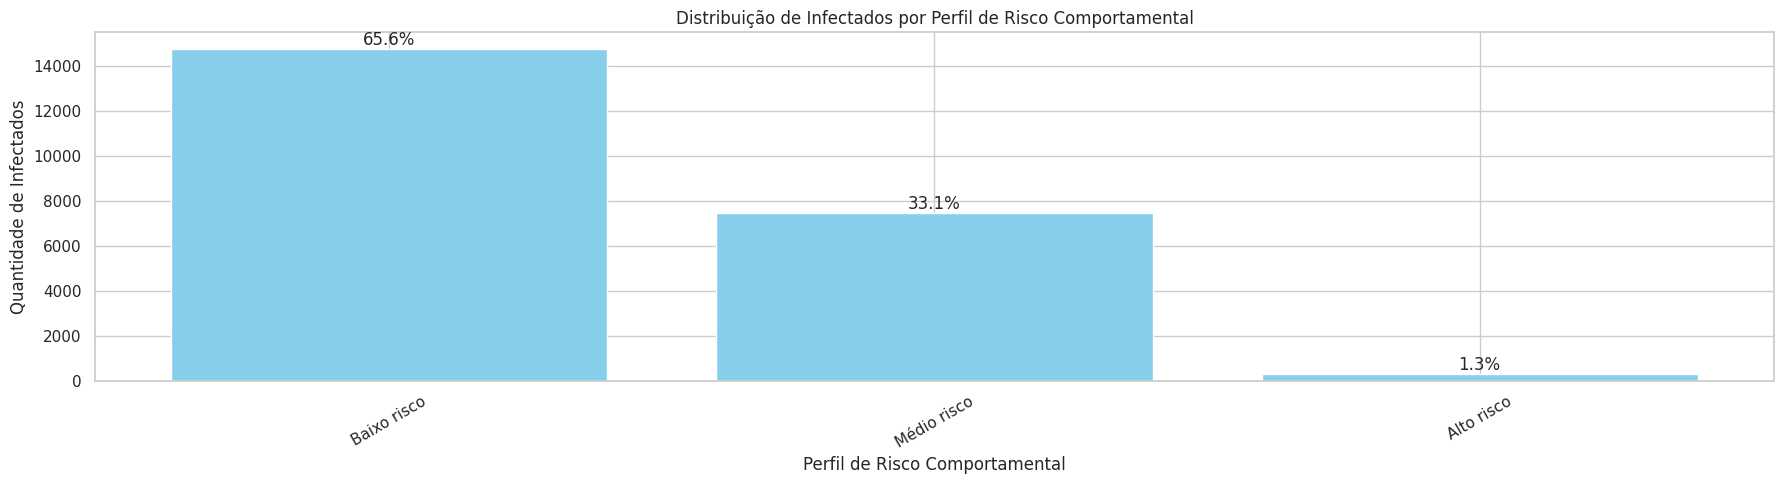


Distribuição de Infectados por Perfil de Risco:



,perfil_risco_comportamental,count,percentual
1,Baixo risco,14743,65.57%
2,Médio risco,7446,33.12%
0,Alto risco,296,1.32%


In [ ]:
# Relação do perfil de risco comportamental dos entrevistados x infecção (resultado positivo do teste)

df_analise = df_covid[df_covid["status_teste"] == "Positivo"]

# Agrupando os dados
pdf = df_analise.groupby("perfil_risco_comportamental").size().reset_index(name="count")

# Calculando o percentual
total = pdf["count"].sum()
pdf["percentual"] = (pdf["count"] / total) * 100

# Ordenando os dados
pdf = pdf.sort_values(by="count", ascending=False)

# Plot
plt.figure(figsize=(18,5))

bars = plt.bar(pdf["perfil_risco_comportamental"], pdf["count"], color="skyblue")

# Rótulos (%)
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title("Distribuição de Infectados por Perfil de Risco Comportamental")
plt.xlabel("Perfil de Risco Comportamental")
plt.ylabel("Quantidade de Infectados")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição de Infectados por Perfil de Risco:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A maioria dos infectados está classificada como **baixo risco (65,57%)**.
- O grupo de **médio risco (33,12%)** também possui participação relevante.
- Apenas **1,32%** dos casos pertencem ao grupo de **alto risco**.

O perfil de risco considera:

- **Nível de isolamento** (maior isolamento → menor risco)  
- **Uso de kit de prevenção** (completo vs. incompleto)  

Os dados indicam que, mesmo entre indivíduos classificados como **baixo risco**, há ocorrência significativa de infecção, o que pode sugerir:

- exposição indireta ou contatos inevitáveis  
- limitações das medidas preventivas isoladamente  
- possível inconsistência entre comportamento declarado e real  

A análise reforça que, embora comportamentos preventivos reduzam o risco, **não eliminam totalmente a possibilidade de infecção**, evidenciando a complexidade da dinâmica de transmissão.

---

### 📊 Distribuição de Casos Positivos por Perfil de Risco Comportamental e Região

Este gráfico apresenta a **distribuição percentual de indivíduos positivados** por **perfil de risco comportamental** (Alto, Médio e Baixo) em cada região, considerando também o **total de casos positivos**.

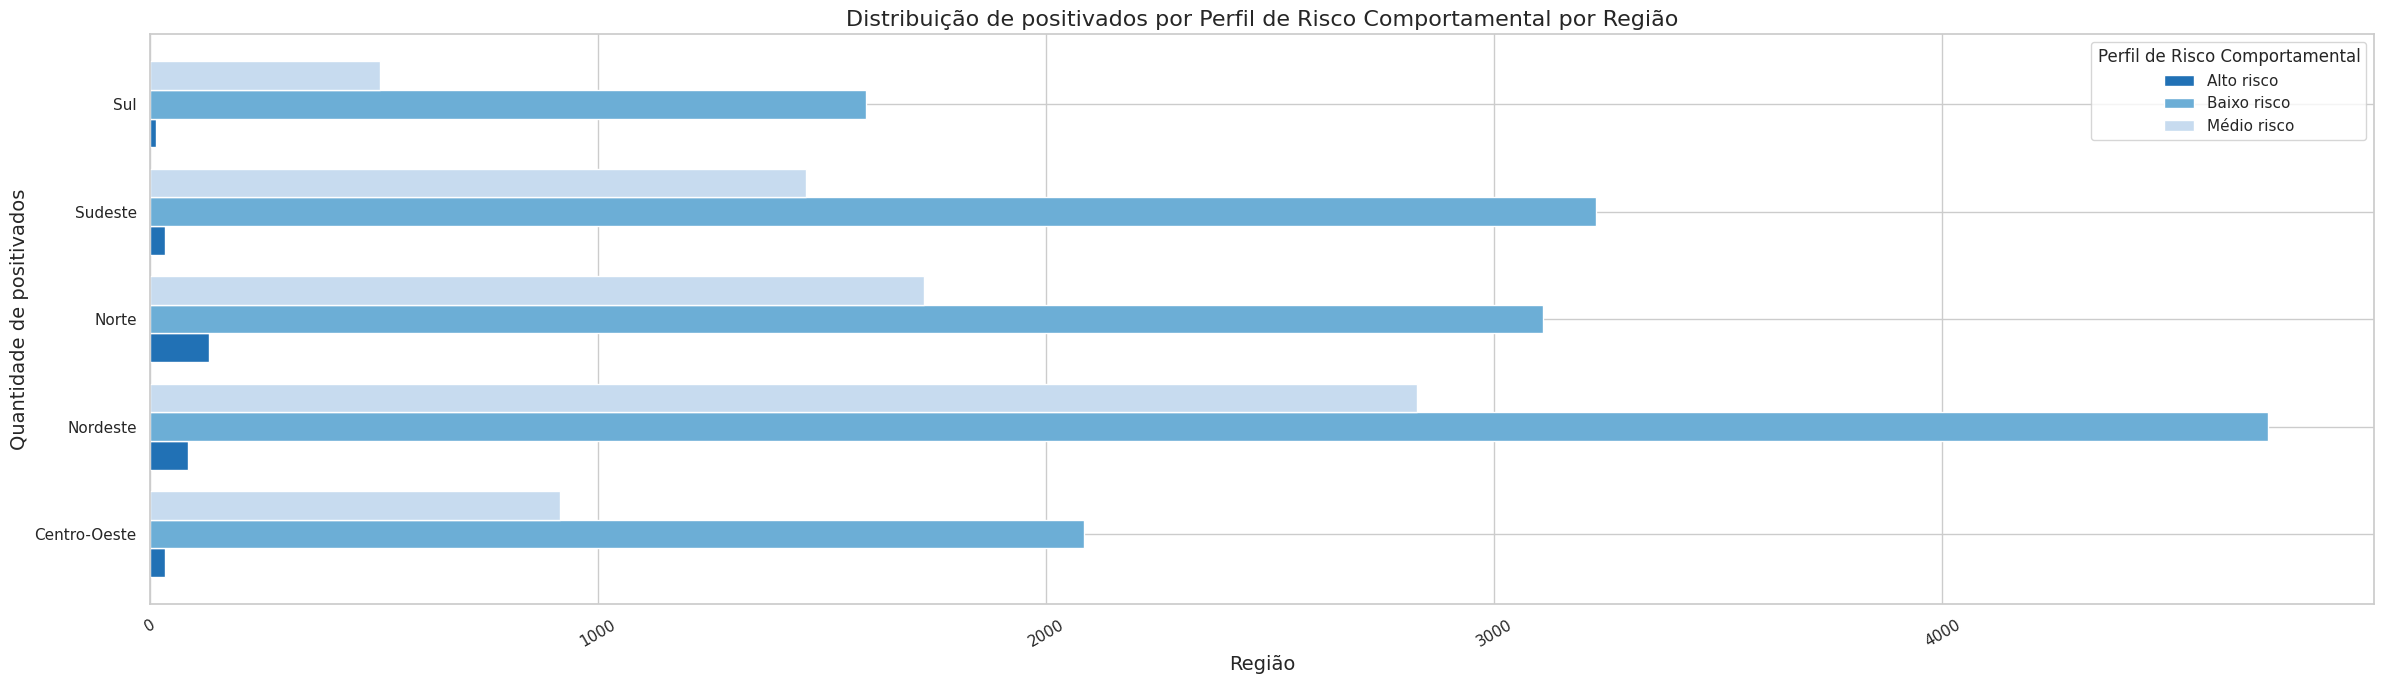

Distribuição percentual de positivados por perfil de risco comportamental e região (com totais):



/tmp/ipykernel_4556/3280101640.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_display = df_display.applymap(lambda x: f"{x:.2f}%")


perfil_risco_comportamental,Alto risco,Baixo risco,Médio risco,Total de Casos
regiao,,,,
Centro-Oeste,1.09%,68.76%,30.16%,3031
Nordeste,1.11%,61.87%,37.02%,7640
Norte,2.66%,62.57%,34.78%,4969
Sudeste,0.70%,68.32%,30.98%,4722
Sul,0.61%,75.22%,24.16%,2123


In [ ]:
# Relação do perfil de risco comportamental dos entrevistados x infecção (resultado positivo do teste), por região

df_analise = df_covid[df_covid["status_teste"] == "Positivo"]

# Agrupar por região e perfil de risco, contando os casos
df_grouped = df_analise.groupby(["regiao", "perfil_risco_comportamental"]).size().reset_index(name="count")

# Pivot para formato de gráfico (região no eixo X, perfis como colunas)
df_pivot = df_grouped.pivot(index="regiao", columns="perfil_risco_comportamental", values="count").fillna(0)

# Paleta cromática de cinza a azul
num_perfis = df_pivot.shape[1]
colors = sns.color_palette("Blues_r", num_perfis)  # Blues reversed para ir do cinza claro ao azul escuro

# Plot
ax = df_pivot.plot(kind="barh", figsize=(24,7), width=0.8, color=colors)

plt.title("Distribuição de positivados por Perfil de Risco Comportamental por Região", fontsize=16)
plt.xlabel("Região", fontsize=14)
plt.ylabel("Quantidade de positivados", fontsize=14)
plt.xticks(rotation=30)
plt.legend(title="Perfil de Risco Comportamental")
plt.tight_layout()
plt.show()

# Percentuais
df_percent = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

# Total de casos por região
df_totais = df_pivot.sum(axis=1).rename("Total de Casos")

# Combinar total e percentuais
df_display = df_percent.copy()
df_display = df_display.applymap(lambda x: f"{x:.2f}%")
df_display["Total de Casos"] = df_totais

print("Distribuição percentual de positivados por perfil de risco comportamental e região (com totais):\n")
display(df_display)

### 🔍 Principais pontos de análise

- **Perfil de Baixo risco** concentra a maior parte dos casos positivos em todas as regiões:
  - Sul: 75,22%  
  - Sudeste: 68,32%  
  - Centro-Oeste: 68,76%  
  - Nordeste: 61,87%  
  - Norte: 62,57%  

- **Perfil de Médio risco** tem participação relevante, especialmente no Nordeste (37,02%) e Norte (34,78%).  

- **Alto risco** representa a menor fração em todas as regiões (<3%), mas ainda merece atenção por indicar maior potencial de gravidade.  

- **Total de casos positivos por região**:
  - Nordeste: 7.640  
  - Norte: 4.969  
  - Sudeste: 4.722  
  - Centro-Oeste: 3.031  
  - Sul: 2.123  

Os dados sugerem que **mesmo entre os positivados, a maioria mantém comportamentos de baixo risco**, mas o perfil médio e alto indica subgrupos que podem demandar **atenção especial em políticas de prevenção e isolamento**.

---

### 📊 Severidade dos Casos por Faixa Etária

Este gráfico apresenta a distribuição da **severidade dos casos positivos** por faixa etária, com base na quantidade de sintomas reportados.

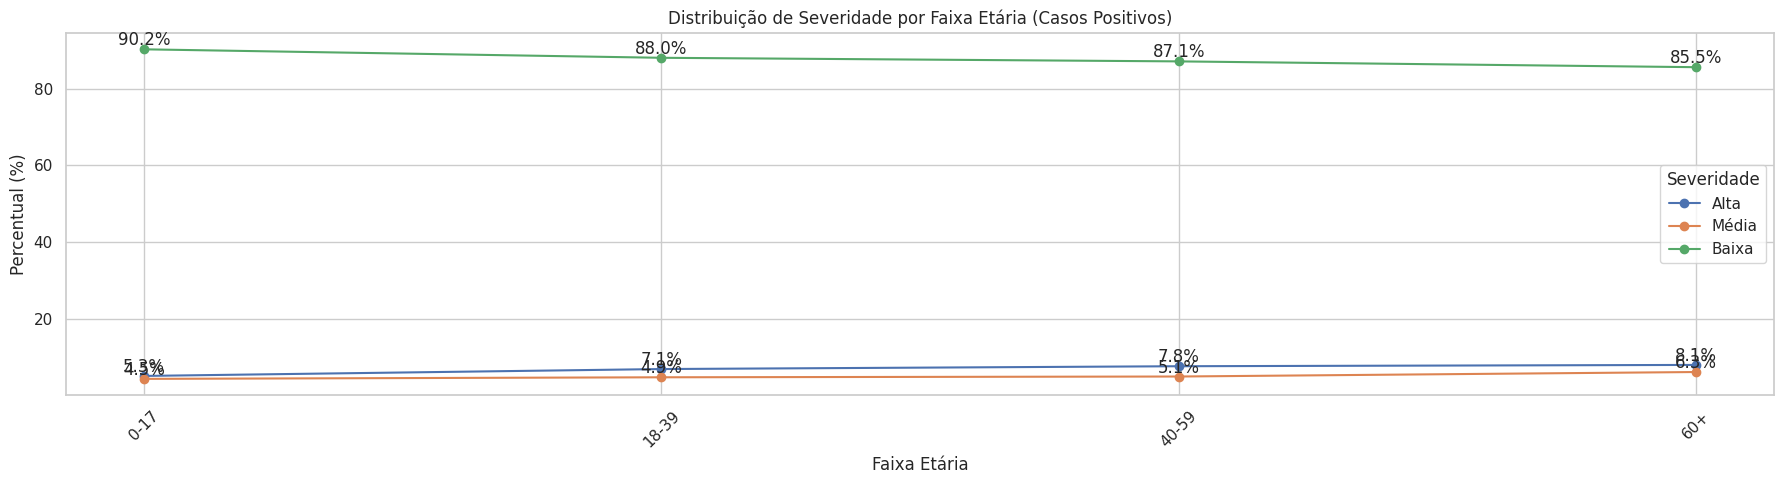


Severidade por Faixa Etária (Casos Positivos):



,faixa_etaria,nivel_severidade,qtd,percentual
0,0-17,Alta,97,5.28%
1,0-17,Baixa,1656,90.20%
2,0-17,Média,83,4.52%
3,18-39,Alta,641,7.08%
4,18-39,Baixa,7972,87.99%
5,18-39,Média,447,4.93%
6,40-59,Alta,651,7.81%
7,40-59,Baixa,7258,87.06%
8,40-59,Média,428,5.13%
9,60+,Alta,265,8.15%


In [ ]:
# Evolução da severidade por faixa etária, para casos identificados nos testes com resultados Positivos

df_pos = df_covid[df_covid["status_teste"] == "Positivo"].copy()

# Agrupamento
pdf = df_pos.groupby(["faixa_etaria", "nivel_severidade"]).size().reset_index(name="qtd")

# Total por faixa etária
total_faixa = pdf.groupby("faixa_etaria")["qtd"].transform("sum")

# Percentual
pdf["percentual"] = (pdf["qtd"] / total_faixa) * 100

# Pivot para gráfico
pdf_pivot = pdf.pivot(index="faixa_etaria", columns="nivel_severidade", values="percentual").fillna(0)

# Ordenar faixa etária (se necessário)
pdf_pivot = pdf_pivot.sort_index()

# Plot
plt.figure(figsize=(18,5))

for col in ["Alta", "Média", "Baixa"]:
    if col in pdf_pivot.columns:
        plt.plot(pdf_pivot.index, pdf_pivot[col], marker='o', label=col)

        # Rótulos
        for i, val in enumerate(pdf_pivot[col]):
            plt.text(i, val, f"{val:.1f}%", ha='center', va='bottom')

plt.title("Distribuição de Severidade por Faixa Etária (Casos Positivos)")
plt.xlabel("Faixa Etária")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=45)
plt.legend(title="Severidade")
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nSeveridade por Faixa Etária (Casos Positivos):\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A grande maioria dos casos em todas as faixas etárias é de **baixa severidade**:
  - **0-17 (90,20%)**
  - **18-39 (87,99%)**
  - **40-59 (87,06%)**
  - **60+ (85,55%)**

- A proporção de casos **graves (alta severidade)** aumenta com a idade:
  - **0-17: 5,28%**
  - **18-39: 7,08%**
  - **40-59: 7,81%**
  - **60+: 8,15%**

- Casos de **média severidade** também apresentam leve crescimento com a idade, com destaque para:
  - **60+ (6,30%)**, maior percentual entre os grupos

A severidade foi definida com base na quantidade de sintomas:

- **Baixa**: até 2 sintomas  
- **Média**: 3 a 5 sintomas  
- **Alta**: mais de 5 sintomas  

Os dados indicam uma clara relação entre **idade e agravamento dos sintomas**, onde:

- indivíduos mais jovens tendem a apresentar quadros mais leves  
- o risco de maior severidade aumenta progressivamente com a idade  

A análise reforça que a idade é um fator importante na evolução clínica da doença, com maior probabilidade de quadros mais severos em populações mais idosas.

---

### 📊 Severidade dos Casos por Nível de Isolamento

Este gráfico apresenta a distribuição da severidade dos casos positivos, conforme o nível de isolamento adotado pelos indivíduos.

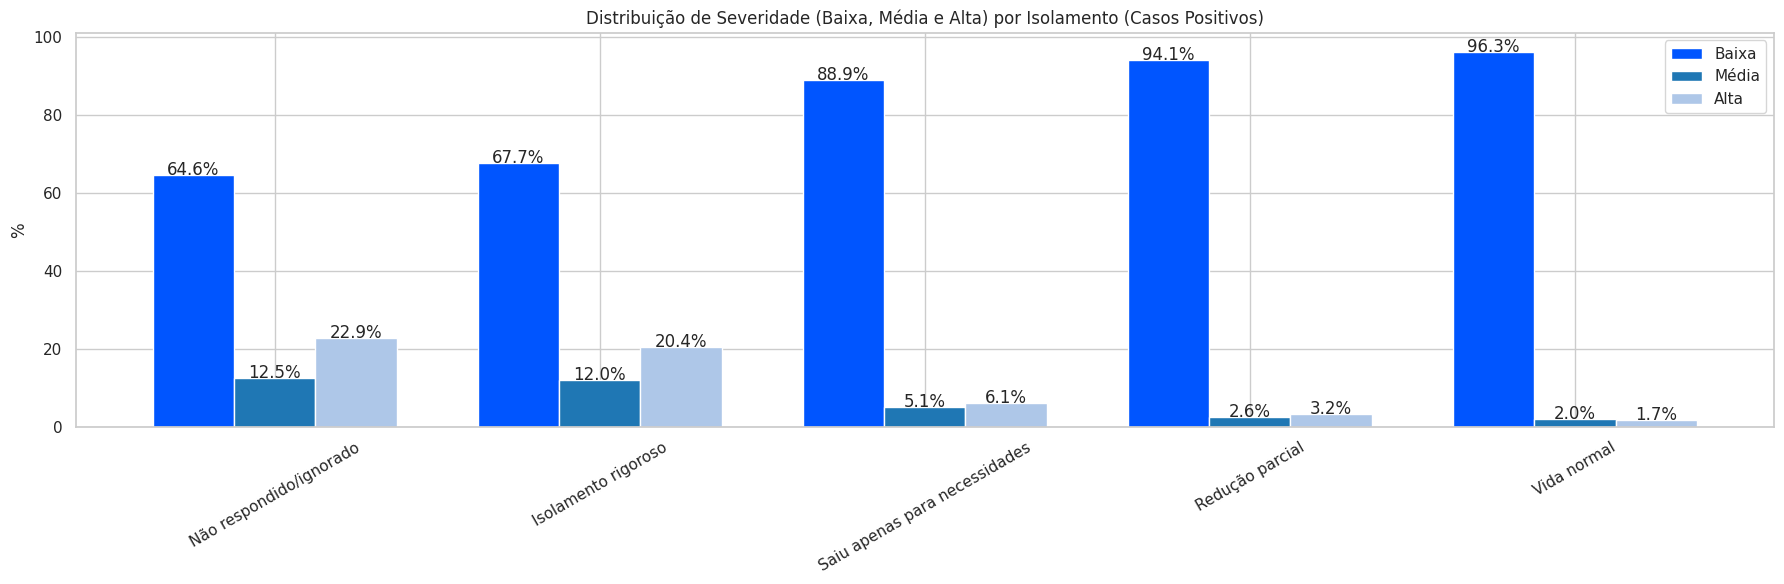


Severidade (Média vs Alta) por Nível de Isolamento (Apenas Positivos):



nivel_severidade,nivel_isolamento,Baixa,Média,Alta,perc_Baixa,perc_media,perc_Alta
0,Não respondido/ignorado,31,6,11,64.58%,12.50%,22.92%
1,Isolamento rigoroso,2847,503,857,67.67%,11.96%,20.37%
2,Saiu apenas para necessidades,6617,377,452,88.87%,5.06%,6.07%
3,Redução parcial,9219,257,317,94.14%,2.62%,3.24%
4,Vida normal,954,20,17,96.27%,2.02%,1.72%


In [ ]:
# Severidade Média e Alta por nível de isolamento, para casos positivos para infecção

pdf_analise = df_covid.copy()

# Filtro
pdf_analise = pdf_analise[pdf_analise["status_teste"] == "Positivo"]

# Normalização
pdf_analise["nivel_severidade"] = (
    pdf_analise["nivel_severidade"]
    .str.strip()
    .str.capitalize()
)

# Filtro de severidade
pdf_analise = pdf_analise[
    pdf_analise["nivel_severidade"].isin(["Média", "Alta", "Baixa"])
]

# Crosstab
resumo = pd.crosstab(
    pdf_analise["nivel_isolamento"],
    pdf_analise["nivel_severidade"]
).reset_index()

# Garantir colunas
for col in ["Média", "Alta", "Baixa"]:
    if col not in resumo.columns:
        resumo[col] = 0

# Total
resumo["total"] = resumo["Média"] + resumo["Alta"] + resumo["Baixa"]
resumo["total"] = resumo["total"].replace(0, 1)

# Percentuais
resumo["perc_media"] = (resumo["Média"] / resumo["total"]) * 100
resumo["perc_Alta"] = (resumo["Alta"] / resumo["total"]) * 100
resumo["perc_Baixa"] = (resumo["Baixa"] / resumo["total"]) * 100

# Ordenar
resumo = resumo.sort_values("perc_media", ascending=False)

# Plot corrigido
x = np.arange(len(resumo))
width = 0.25

plt.figure(figsize=(18,6))

bars1 = plt.bar(x - width, resumo["perc_Baixa"], width, color="#0055ff", label="Baixa")
bars2 = plt.bar(x, resumo["perc_media"], width, color="#1f77b4", label="Média")
bars3 = plt.bar(x + width, resumo["perc_Alta"], width, color="#aec7e8", label="Alta")

# Rótulos
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.1f}%", ha='center')

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.1f}%", ha='center')

for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.1f}%", ha='center')

plt.xticks(x, resumo["nivel_isolamento"], rotation=30)
plt.ylabel("%")
plt.title("Distribuição de Severidade (Baixa, Média e Alta) por Isolamento (Casos Positivos)")
plt.legend()

plt.tight_layout()
plt.show()

resumo_display = resumo.copy().reset_index(drop=True)

resumo_display["perc_Baixa"] = resumo_display["perc_Baixa"].map(lambda x: f"{x:.2f}%")
resumo_display["perc_media"] = resumo_display["perc_media"].map(lambda x: f"{x:.2f}%")
resumo_display["perc_Alta"] = resumo_display["perc_Alta"].map(lambda x: f"{x:.2f}%")

print("\nSeveridade (Média vs Alta) por Nível de Isolamento (Apenas Positivos):\n")
display(resumo_display[["nivel_isolamento", "Baixa", "Média", "Alta", "perc_Baixa", "perc_media", "perc_Alta"]])

### 🔍 Principais pontos de análise

- Indivíduos em **vida normal** apresentam a maior proporção de casos **leves (96,27%)** e as menores taxas de média (2,02%) e alta severidade (1,72%).
- A **redução parcial** também concentra predominantemente casos leves (**94,14%**), com baixa incidência de casos mais graves.
- Já o grupo que **saiu apenas para necessidades** apresenta aumento relativo na severidade:
  - **Média (5,06%)**
  - **Alta (6,07%)**

- O **isolamento rigoroso** apresenta maior proporção de casos mais severos:
  - **Alta severidade (20,37%)**
  - **Média (11,96%)**

- O grupo **não respondido/ignorado** também apresenta alta proporção de casos severos, mas com baixa representatividade.

Os dados sugerem um padrão interessante:

- **Menor circulação → maior proporção de casos severos**
- **Maior circulação → predominância de casos leves**

Isso pode indicar que indivíduos com sintomas mais graves tendem a adotar isolamento mais rigoroso.

A análise reforça um possível efeito de **causalidade reversa**, onde a severidade influencia o comportamento de isolamento, e não apenas o contrário.

Uma explicação plausível para o fato de isolamento rigoroso apresentar maior proporção de casos severos está relacionada principalmente à **causalidade reversa** e ao contexto comportamental dos indivíduos:

### 🔍 Principais fatores

- **Adoção reativa do isolamento**
  - Pessoas tendem a intensificar o isolamento **após o agravamento dos sintomas**, e não antes.
  - Ou seja, o quadro clínico mais severo leva ao isolamento rigoroso, e não o contrário.

- **Presença de grupos mais vulneráveis**
  - Indivíduos com maior risco (idosos, comorbidades) podem adotar isolamento mais rígido por precaução.
  - Esses grupos também têm maior probabilidade de desenvolver quadros mais graves.

- **Viés de seleção da amostra**
  - Casos leves podem não alterar o comportamento (continuam circulando).
  - Já casos graves são mais visíveis na amostra porque levam a mudanças comportamentais (isolamento).

- **Momento da coleta dos dados**
  - Se o dado de isolamento foi capturado no momento da entrevista, ele reflete o estado atual do indivíduo, não necessariamente o comportamento no momento da infecção.

- **Subnotificação de casos leves em isolamento rigoroso**
  - Indivíduos isolados com sintomas leves podem não ter sido testados ou reportados com a mesma frequência.

📌 O isolamento rigoroso não causa maior severidade — na verdade, ele é frequentemente uma **resposta ao agravamento da doença**. Esse padrão é comum em análises observacionais e exige cautela na interpretação de causalidade.

---

### 📊 Pressão Hospitalar por Plano de Saúde

Este gráfico apresenta a proporção de internações e uso de ventilação entre os entrevistados, segmentando por posse de plano de saúde.

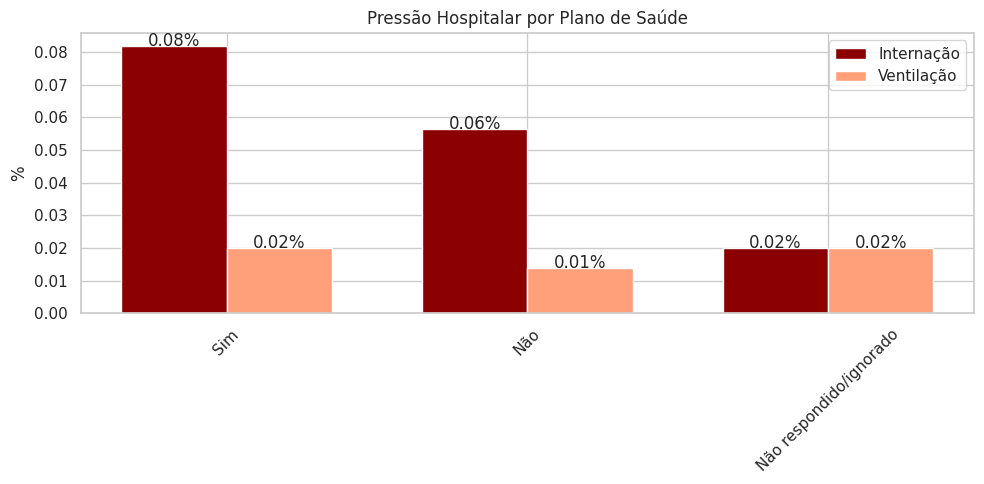


Pressão Hospitalar por Plano de Saúde:



,plano_saude,internados,ventilacao,total,perc_internacao,perc_ventilacao
2,Sim,212,52,259158,0.08%,0.02%
0,Não,504,125,893859,0.06%,0.01%
1,Não respondido/ignorado,1,1,4967,0.02%,0.02%


In [ ]:
# Análise da pressão hospitalar: casos em que houve internação e necessidade de uso da ventilação

pdf = df_covid.copy()

resumo = pdf.groupby("plano_saude").agg(
    internados=("internacao", lambda x: (x == "Sim").sum()),
    ventilacao=("uso_ventilador", lambda x: (x == "Sim").sum()),
    total=("plano_saude", "count")
).reset_index()

# Percentuais
resumo["perc_internacao"] = (resumo["internados"] / resumo["total"]) * 100
resumo["perc_ventilacao"] = (resumo["ventilacao"] / resumo["total"]) * 100

# Ordenação
resumo = resumo.sort_values("perc_internacao", ascending=False)

# Plot

x = np.arange(len(resumo))
width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, resumo["perc_internacao"], width, color="#8B0000", label="Internação")
bars2 = plt.bar(x + width/2, resumo["perc_ventilacao"], width, color="#FFA07A", label="Ventilação")

# Rótulos %
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.2f}%", ha='center')

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.2f}%", ha='center')

plt.xticks(x, resumo["plano_saude"], rotation=45)
plt.ylabel("%")
plt.title("Pressão Hospitalar por Plano de Saúde")
plt.legend()

plt.tight_layout()
plt.show()

resumo_display = resumo.copy()

resumo_display["perc_internacao"] = resumo_display["perc_internacao"].map(lambda x: f"{x:.2f}%")
resumo_display["perc_ventilacao"] = resumo_display["perc_ventilacao"].map(lambda x: f"{x:.2f}%")

print("\nPressão Hospitalar por Plano de Saúde:\n")
display(resumo_display)

### 🔍 Principais pontos de análise

- Indivíduos com **plano de saúde** apresentam:
  - **0,08%** de internação  
  - **0,02%** de uso de ventilação  

- Já aqueles **sem plano de saúde** apresentam:
  - **0,06%** de internação  
  - **0,01%** de uso de ventilação  

- O grupo **não respondido/ignorado** possui baixa representatividade, com percentuais pouco relevantes.

Os dados indicam:

- Diferença pequena, porém consistente, com **maior proporção de uso hospitalar entre quem possui plano**  
- Possível reflexo de **maior acesso a serviços de saúde** e diagnóstico  

A análise sugere que o acesso ao sistema de saúde pode influenciar a **probabilidade de internação e suporte médico**, ainda que os percentuais gerais sejam baixos.

---

### 📊 Uso de Ventilação entre Internados por Plano de Saúde

Este gráfico apresenta a proporção de uso de ventilação entre os indivíduos internados, segmentando por posse de plano de saúde.

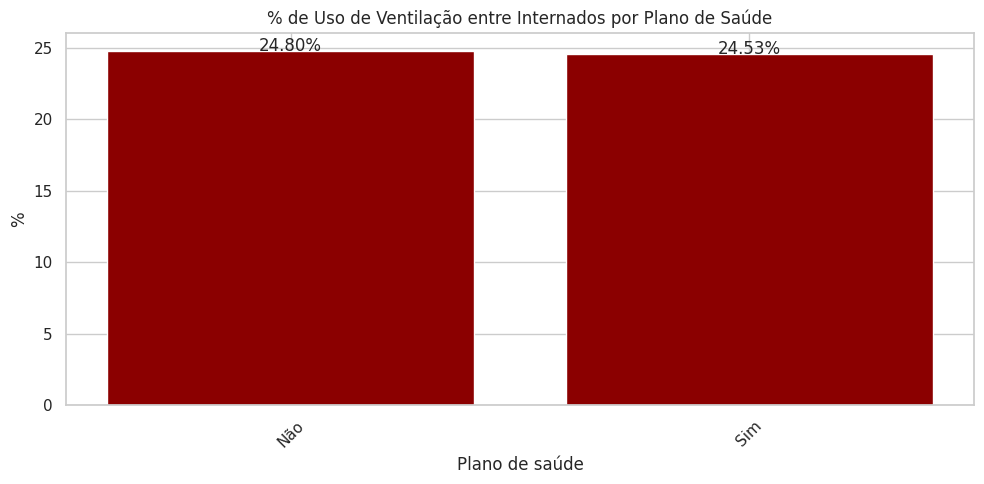


% de Ventilação ENTRE INTERNADOS por Plano de Saúde:



,plano_saude,ventilacao,total_internados,perc_ventilacao
0,Não,125,504,24.80%
1,Sim,52,212,24.53%


In [ ]:
# % de uso da ventilação dentre os pacientes que foram internados, de acordo com a posse ou não de plano de saúde

pdf = df_covid.copy()

# Filtrando apenas pacientes internados
pdf_int = pdf[pdf["internacao"] == "Sim"]

# Removendo os casos não respondidos
pdf_int = pdf_int[
    ~pdf_int["plano_saude"]
    .str.strip()
    .str.lower()
    .isin(["não respondido/ignorado", "nao respondido/ignorado"])
]

# Agrupando
resumo = pdf_int.groupby("plano_saude").agg(
    ventilacao=("uso_ventilador", lambda x: (x == "Sim").sum()),
    total_internados=("plano_saude", "count")
).reset_index()

# Percentual correto (condicional)
resumo["perc_ventilacao"] = (resumo["ventilacao"] / resumo["total_internados"]) * 100

# Ordenar
resumo = resumo.sort_values("perc_ventilacao", ascending=False)

# Plot
x = np.arange(len(resumo))
plt.figure(figsize=(10,5))
bars = plt.bar(x, resumo["perc_ventilacao"], color="#8B0000")

# Rótulos %
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.2f}%", ha='center')

plt.xticks(x, resumo["plano_saude"], rotation=45)
plt.ylabel("%")
plt.xlabel("Plano de saúde")
plt.title("% de Uso de Ventilação entre Internados por Plano de Saúde")

plt.tight_layout()
plt.show()

resumo_display = resumo.copy()
resumo_display["perc_ventilacao"] = resumo_display["perc_ventilacao"].map(lambda x: f"{x:.2f}%")

print("\n% de Ventilação ENTRE INTERNADOS por Plano de Saúde:\n")
display(resumo_display)

### 🔍 Principais pontos de análise

- Entre os internados **sem plano de saúde**, **24,80%** utilizaram ventilação.
- Entre os internados **com plano de saúde**, o percentual é muito próximo: **24,53%**.

Os dados indicam uma **alta similaridade** entre os grupos, sugerindo que:

- O uso de ventilação está mais relacionado à **gravidade clínica** do que ao acesso ao plano de saúde  
- Uma vez internados, os pacientes tendem a receber **tratamento semelhante** em termos de suporte respiratório  

A análise mostra que, apesar de possíveis diferenças no acesso à internação, a **intensidade do cuidado entre internados é praticamente equivalente** entre os grupos.

---

### 📊 Uso de Ventilação entre Internados por Estado

Este gráfico apresenta a proporção de uso de ventilação entre pacientes internados, segmentada por estado, permitindo identificar variações regionais na intensidade dos casos.

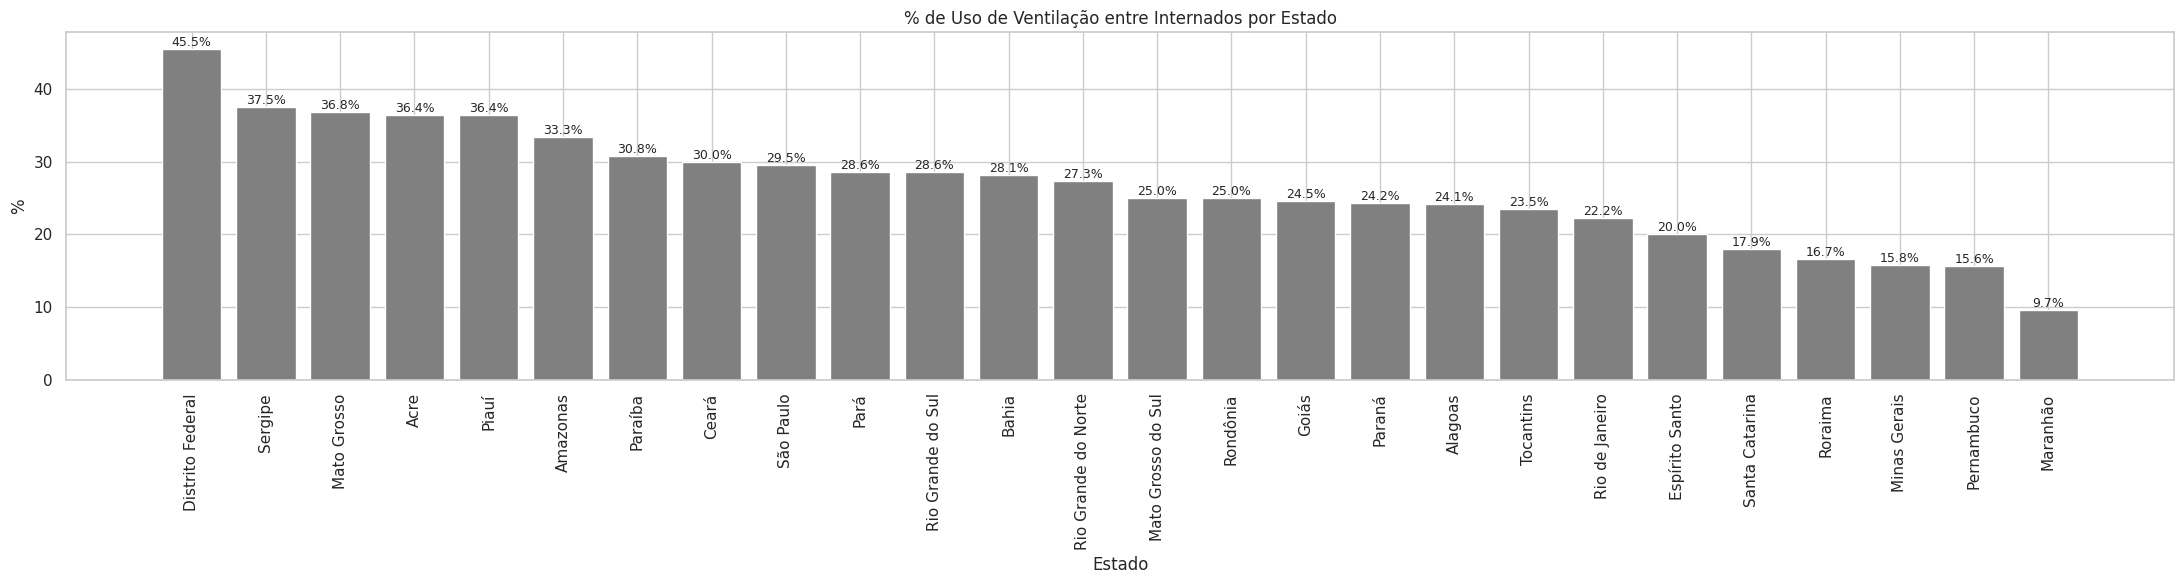


% de Ventilação ENTRE INTERNADOS por Estado:



,estado,ventilacao,total_internados,perc_ventilacao
0,Distrito Federal,5,11,45.45%
1,Sergipe,3,8,37.50%
2,Mato Grosso,14,38,36.84%
3,Acre,4,11,36.36%
4,Piauí,4,11,36.36%
5,Amazonas,5,15,33.33%
6,Paraíba,4,13,30.77%
7,Ceará,9,30,30.00%
8,São Paulo,18,61,29.51%
9,Pará,6,21,28.57%


In [ ]:
# % de uso de ventilação entre internados por estado

pdf = df_covid.copy()

# Filtrar apenas internados
pdf_int = pdf[pdf["internacao"] == "Sim"]

# Remover estados inválidos (se necessário)
pdf_int = pdf_int[
    ~pdf_int["estado"]
    .str.strip()
    .str.lower()
    .isin(["não respondido/ignorado", "nao respondido/ignorado"])
]

# Agrupamento por estado
resumo_estado = pdf_int.groupby("estado").agg(
    ventilacao=("uso_ventilador", lambda x: (x == "Sim").sum()),
    total_internados=("estado", "count")
).reset_index()

# Percentual
resumo_estado["perc_ventilacao"] = (
    resumo_estado["ventilacao"] / resumo_estado["total_internados"]
) * 100

# Ordenar (maior demanda primeiro)
resumo_estado = resumo_estado.sort_values("perc_ventilacao", ascending=False)

# Plot
plt.figure(figsize=(22,6))
bars = plt.bar(resumo_estado["estado"], resumo_estado["perc_ventilacao"], color="grey")

# Rótulos %
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=90)
plt.ylabel("%")
plt.xlabel("Estado")
plt.title("% de Uso de Ventilação entre Internados por Estado")

plt.tight_layout()
plt.show()

resumo_display = resumo_estado.copy().reset_index(drop=True)
resumo_display["perc_ventilacao"] = resumo_display["perc_ventilacao"].map(lambda x: f"{x:.2f}%")

print("\n% de Ventilação ENTRE INTERNADOS por Estado:\n")
display(resumo_display)

### 🔍 Principais pontos de análise

- Estados com **maiores proporções de ventilação dentre os casos que tiveram internação**:
  - **Distrito Federal (45,45%)**
  - **Sergipe (37,50%)**
  - **Mato Grosso (36,84%)**
  - **Acre e Piauí (36,36%)**

- Estados com valores intermediários incluem:
  - **São Paulo (29,51%)**
  - **Rio Grande do Sul (28,57%)**
  - **Bahia (28,12%)**

- Estados com **menores proporções de ventilação**:
  - **Maranhão (9,68%)**
  - **Pernambuco (15,62%)**
  - **Minas Gerais (15,79%)**

Os dados revelam uma **alta variabilidade entre estados**, que pode estar associada a:

- diferenças na gravidade dos casos atendidos  
- capacidade e infraestrutura hospitalar  
- critérios clínicos para uso de ventilação  
- tamanho da amostra em cada estado  

A análise indica que o uso de ventilação não é uniforme no país, refletindo **desigualdades regionais na resposta hospitalar e no perfil dos pacientes atendidos**.

A variação no uso de ventilação entre estados pode servir como um **indicador importante para planejamento de recursos hospitalares** em cenários futuros.

- Estados com maior percentual de uso de ventilação tendem a demandar **maior disponibilidade de respiradores** em situações críticas.
- Esse padrão pode ser utilizado para **antecipar necessidades regionais** em novos eventos pandêmicos.
- Permite uma **alocação mais eficiente de equipamentos**, evitando tanto escassez quanto ociosidade de recursos.

Esse tipo de análise é valioso para apoiar decisões de **gestão de saúde pública**, contribuindo para uma resposta mais rápida e direcionada em contextos de emergência.

---

### 📊 Pressão Hospitalar por Perfil de Risco Comportamental

Este gráfico apresenta a proporção de internações e uso de ventilação de acordo com o perfil de risco comportamental dos entrevistados.

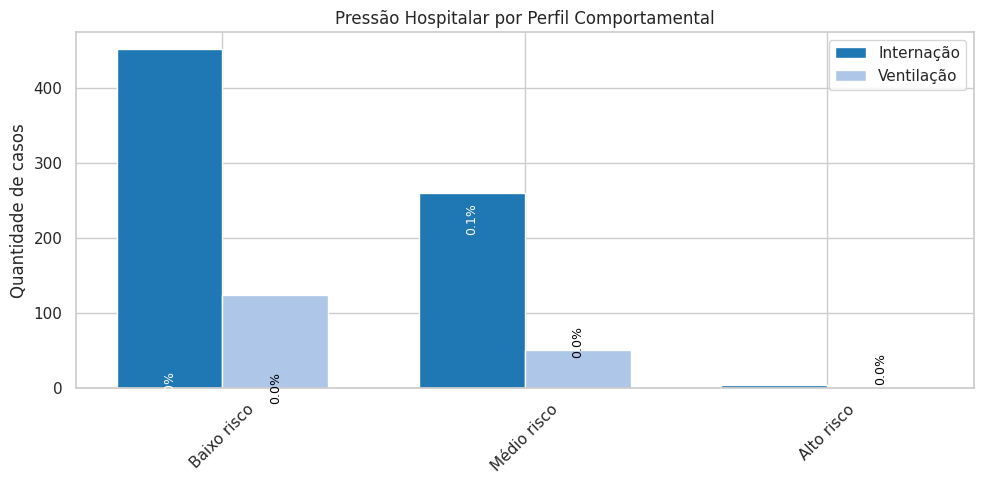


Pressão Hospitalar por Perfil Comportamental:



,perfil_risco_comportamental,internados,ventilacao,total,perc_internacao,perc_ventilacao
1,Baixo risco,452,125,639151,0.07%,0.02%
2,Médio risco,260,51,499967,0.05%,0.01%
0,Alto risco,5,2,18866,0.03%,0.01%


In [ ]:
# Análise da pressão hospitalar: casos em que houve internação e necessidade de uso da ventilação, de acordo com o perfil de risco comportamental dos entrevistados

pdf = df_covid.copy()

resumo = pdf.groupby("perfil_risco_comportamental").agg(
    internados=("internacao", lambda x: (x == "Sim").sum()),
    ventilacao=("uso_ventilador", lambda x: (x == "Sim").sum()),
    total=("perfil_risco_comportamental", "count")
).reset_index()

# Percentuais (para rótulo)
resumo["perc_internacao"] = (resumo["internados"] / resumo["total"]) * 100
resumo["perc_ventilacao"] = (resumo["ventilacao"] / resumo["total"]) * 100

# Ordenar por volume
resumo = resumo.sort_values("internados", ascending=False)

# Plot
x = np.arange(len(resumo))
width = 0.35
plt.figure(figsize=(10,5))
bars1 = plt.bar(x - width/2, resumo["internados"], width, color="#1f77b4", label="Internação")
bars2 = plt.bar(x + width/2, resumo["ventilacao"], width, color="#aec7e8", label="Ventilação")

# Rótulos
for i in range(len(resumo)):

    # Internação
    plt.text(
        x[i] - width/2,
        resumo["internados"][i] / 2,
        f"{resumo['perc_internacao'][i]:.1f}%",
        ha='center',
        va='center',
        rotation=90,
        color='white',
        fontsize=9
    )

    # Ventilação
    plt.text(
        x[i] + width/2,
        resumo["ventilacao"][i] / 2,
        f"{resumo['perc_ventilacao'][i]:.1f}%",
        ha='center',
        va='center',
        rotation=90,
        color='black',
        fontsize=9
    )

plt.xticks(x, resumo["perfil_risco_comportamental"], rotation=45)
plt.ylabel("Quantidade de casos")
plt.title("Pressão Hospitalar por Perfil Comportamental")
plt.legend()

plt.tight_layout()
plt.show()

resumo_display = resumo.copy()

resumo_display["perc_internacao"] = resumo_display["perc_internacao"].map(lambda x: f"{x:.2f}%")
resumo_display["perc_ventilacao"] = resumo_display["perc_ventilacao"].map(lambda x: f"{x:.2f}%")

print("\nPressão Hospitalar por Perfil Comportamental:\n")
display(resumo_display)

### 🔍 Principais pontos de análise

- O grupo de **baixo risco** apresenta:
  - **0,07%** de internação  
  - **0,02%** de uso de ventilação  

- O grupo de **médio risco** possui:
  - **0,05%** de internação  
  - **0,01%** de ventilação  

- Já o grupo de **alto risco** apresenta os menores percentuais:
  - **0,03%** de internação  
  - **0,01%** de ventilação  

Apesar da classificação de risco, os dados mostram:

- **Baixas taxas absolutas** de internação e ventilação em todos os grupos  
- Uma aparente **inversão do esperado**, com maior uso hospitalar no grupo de baixo risco  

A análise reforça que o comportamento declarado nem sempre reflete diretamente o desfecho clínico, sendo necessário considerar múltiplas variáveis para avaliação de risco.

---

### 📊 Internação por Região

Este gráfico apresenta a proporção de internações entre os entrevistados, segmentada por região, permitindo avaliar possíveis diferenças na pressão hospitalar.

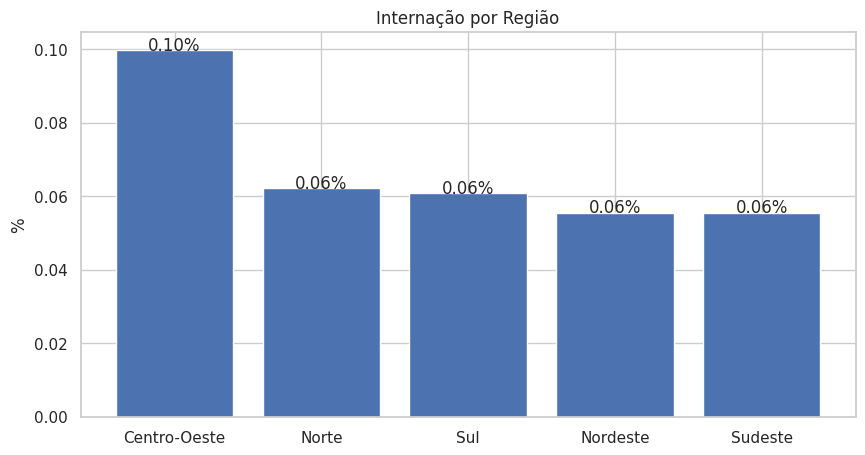


Internação por Região:

         regiao  internados   total percentual
0  Centro-Oeste         122  122336      0.10%
1         Norte          88  141413      0.06%
2           Sul         121  199020      0.06%
3      Nordeste         197  354632      0.06%
4       Sudeste         189  340583      0.06%


In [ ]:
# Internação por região

resumo = pdf.groupby("regiao").agg(
    internados=("internacao", lambda x: (x == "Sim").sum()),
    total=("regiao", "count")
).reset_index()

resumo["percentual"] = (resumo["internados"] / resumo["total"]) * 100
resumo = resumo.sort_values("percentual", ascending=False)

# Plot
plt.figure(figsize=(10,5))
bars = plt.bar(resumo["regiao"], resumo["percentual"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f"{h:.2f}%", ha='center')

plt.ylabel("%")
plt.title("Internação por Região")
plt.show()

# Display
resumo_display = resumo.copy().reset_index(drop=True)
resumo_display["percentual"] = resumo_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nInternação por Região:\n")
print(resumo_display)

### 🔍 Principais pontos de análise

- O **Centro-Oeste** apresenta a maior taxa de internação (**0,10%**), destacando-se em relação às demais regiões.
- As regiões **Norte, Sul, Nordeste e Sudeste** apresentam valores muito próximos, todas em torno de **0,06%**.

- Em termos absolutos:
  - **Nordeste (197)** e **Sudeste (189)** concentram o maior número de internações  
  - **Centro-Oeste (122)** e **Sul (121)** vêm na sequência  
  - **Norte (88)** possui o menor volume  

Os dados indicam:

- **Baixa variação percentual entre regiões**, com exceção do Centro-Oeste  
- Distribuição relativamente homogênea da pressão hospitalar no país  

A análise sugere que, apesar de diferenças populacionais, a **taxa de internação se mantém estável entre regiões**, com leve destaque para o Centro-Oeste.

---

### 📊 Casos Graves por Faixa Etária

Este gráfico apresenta a proporção de casos graves em relação ao total de indivíduos por faixa etária, permitindo avaliar o impacto da idade na severidade da doença.

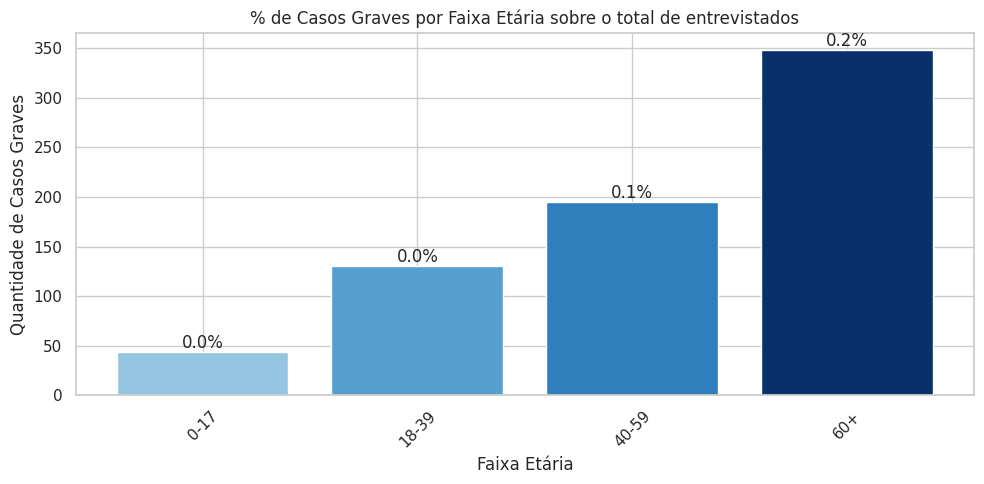


Casos Graves por Faixa Etária:



,faixa_etaria,total,graves,percentual
0,0-17,275259,44,0.02%
1,18-39,365284,130,0.04%
2,40-59,316426,195,0.06%
3,60+,201015,348,0.17%


In [ ]:
# Relação da faixa etária com o % de casos graves (internação + ventilação)

pdf = df_covid.groupby("faixa_etaria").agg(
    total=("caso_grave", "count"),
    graves=("caso_grave", lambda x: (x == "Sim").sum())
).reset_index()

# Percentual de casos graves dentro da faixa
pdf["percentual"] = (pdf["graves"] / pdf["total"]) * 100

# Ordenando faixa etária
def extrair_inicio(faixa):
    match = re.search(r'\d+', str(faixa))
    return int(match.group()) if match else 999

pdf = pdf.sort_values(by="faixa_etaria", key=lambda x: x.map(extrair_inicio))

# Cores monocromáticas
norm = (pdf["graves"] - pdf["graves"].min()) / (
    pdf["graves"].max() - pdf["graves"].min()
)

cores = cm.Blues(0.4 + 0.6 * norm)

# Plot
plt.figure(figsize=(10,5))
bars = plt.bar(pdf["faixa_etaria"], pdf["graves"], color=cores)

# Rótulos (%)
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("% de Casos Graves por Faixa Etária sobre o total de entrevistados")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade de Casos Graves")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nCasos Graves por Faixa Etária:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A proporção de casos graves **aumenta progressivamente com a idade**:
  - **0-17: 0,02%**
  - **18-39: 0,04%**
  - **40-59: 0,06%**
  - **60+: 0,17%**

- A faixa **60+** apresenta a maior taxa de gravidade, com valor significativamente superior às demais.

- Em termos absolutos:
  - **60+ (348 casos graves)** lidera, mesmo com menor população total  
  - **40-59 (195)** e **18-39 (130)** vêm na sequência  
  - **0-17 (44)** apresenta o menor volume  

Os dados evidenciam uma forte relação entre **idade e risco de agravamento**, indicando que:

- indivíduos mais idosos possuem maior probabilidade de desenvolver quadros severos  
- a população jovem tende a apresentar menor risco de complicações  

A análise reforça a idade como um dos principais fatores de risco para gravidade, sendo essencial para definição de **prioridades em políticas de saúde e alocação de recursos**.

---

### 📊 Casos Graves por Cluster de Sintomas dos entrevistados

Este gráfico apresenta a proporção de casos graves conforme a quantidade de sintomas reportados, permitindo avaliar a relação entre carga sintomática e severidade.

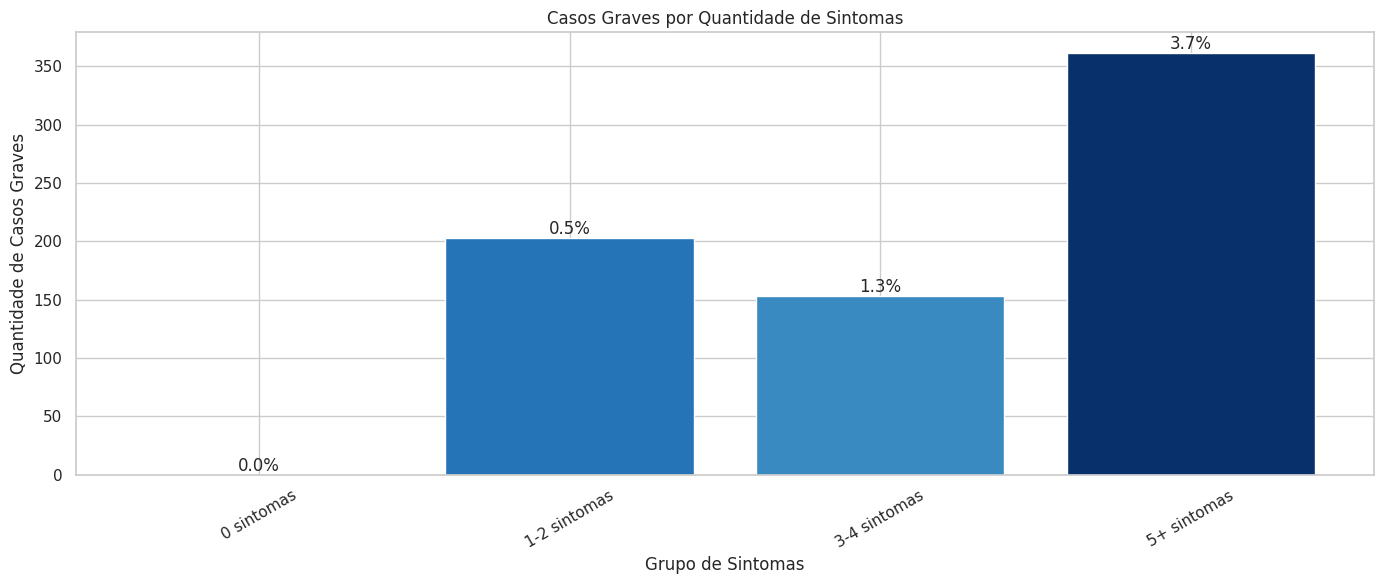


Casos Graves por Cluster de Sintomas:



,grupo_sintomas,total,graves,percentual
0,0 sintomas,1093138,0,0.00%
1,1-2 sintomas,42806,203,0.47%
2,3-4 sintomas,12237,153,1.25%
3,5+ sintomas,9803,361,3.68%


In [ ]:
# Relação da quantidade de sintomas para a quantidade de casos graves

pdf = df_cluster.groupby("grupo_sintomas").agg(
    total=("caso_grave", "count"),
    graves=("caso_grave", lambda x: (x == "Sim").sum())
).reset_index()

# Percentual de graves dentro do cluster
pdf["percentual"] = (pdf["graves"] / pdf["total"]) * 100

# Ordenar corretamente
ordem = ["0 sintomas", "1-2 sintomas", "3-4 sintomas", "5+ sintomas"]
pdf["grupo_sintomas"] = pd.Categorical(pdf["grupo_sintomas"], categories=ordem, ordered=True)
pdf = pdf.sort_values("grupo_sintomas")

# Cores monocromáticas
norm = (pdf["graves"] - pdf["graves"].min()) / (
    pdf["graves"].max() - pdf["graves"].min()
)

cores = cm.Blues(0.4 + 0.6 * norm)

# Plot

plt.figure(figsize=(14,6))

bars = plt.bar(pdf["grupo_sintomas"], pdf["graves"], color=cores)

# Rótulos (%)
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Casos Graves por Quantidade de Sintomas")
plt.xlabel("Grupo de Sintomas")
plt.ylabel("Quantidade de Casos Graves")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nCasos Graves por Cluster de Sintomas:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- Indivíduos **sem sintomas (0,00%)** não apresentam casos graves, como esperado.
- A proporção de casos graves **aumenta conforme o número de sintomas**:
  - **1-2 sintomas: 0,47%**
  - **3-4 sintomas: 1,25%**
  - **5+ sintomas: 3,68%**

- O grupo com **5 ou mais sintomas** apresenta a maior taxa de gravidade, destacando forte associação com quadros severos.

Os dados evidenciam uma relação clara entre **quantidade de sintomas e agravamento**, indicando que:

- maior carga sintomática → maior probabilidade de casos graves  
- sintomas múltiplos podem ser um **indicador precoce de risco clínico**  

A análise reforça a importância do monitoramento da evolução dos sintomas como ferramenta essencial para **identificação precoce de casos graves** e priorização de atendimento. A partir disto, também visualizamos a importância de uma boa triagem dos pacientes, caso procurem atendimento.

---

### 📊 Ranking de Sintomas em Casos Graves

Este gráfico apresenta os sintomas mais frequentes entre os **717 casos graves**, permitindo identificar padrões clínicos associados a quadros mais severos.


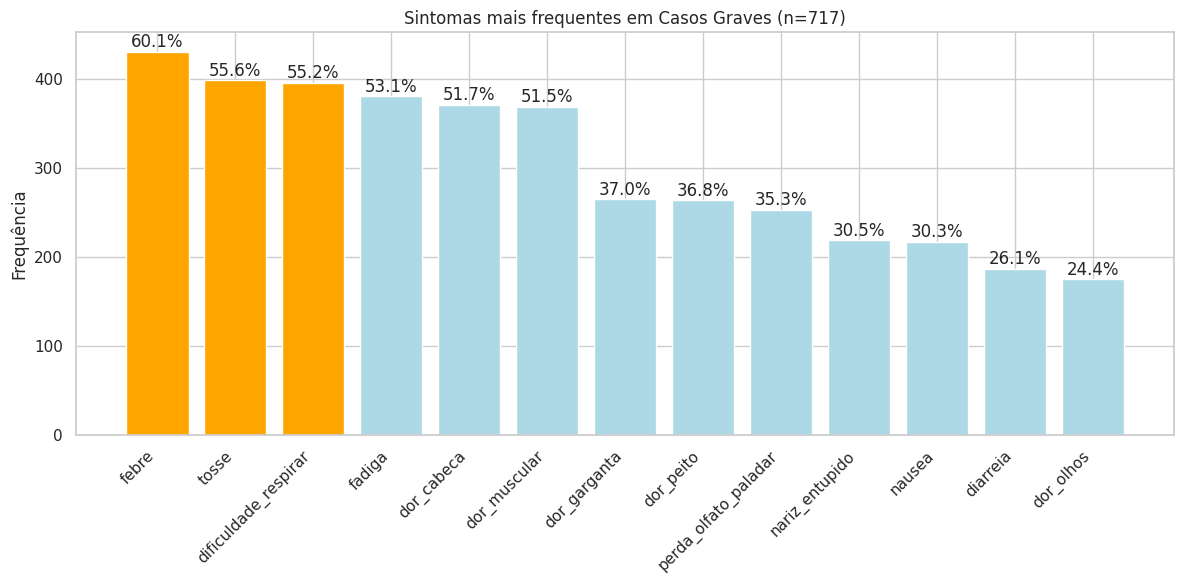


Ranking de Sintomas em Casos Graves (total de 717 casos graves):



,sintoma,frequencia,percentual
0,febre,431,60.11%
1,tosse,399,55.65%
2,dificuldade_respirar,396,55.23%
3,fadiga,381,53.14%
4,dor_cabeca,371,51.74%
5,dor_muscular,369,51.46%
6,dor_garganta,265,36.96%
7,dor_peito,264,36.82%
8,perda_olfato_paladar,253,35.29%
9,nariz_entupido,219,30.54%


In [ ]:
# Ranking dos sintomas mais frequentes em Casos Graves

sintomas_cols = [
    'febre', 'tosse', 'dor_garganta', 'dificuldade_respirar',
    'dor_cabeca', 'dor_peito', 'nausea', 'nariz_entupido',
    'fadiga', 'dor_olhos', 'perda_olfato_paladar',
    'dor_muscular', 'diarreia'
]

df_graves = df_covid[df_covid['caso_grave'] == 'Sim']
total_graves = len(df_graves)

# Frequência absoluta
ranking_sintomas = (
    df_graves[sintomas_cols]
    .apply(lambda x: (x == 'Sim').sum())
    .sort_values(ascending=False)
)

# Percentual
percentual = (ranking_sintomas / total_graves) * 100

# Cores

cores = [
    "orange" if i < 3 else "lightblue"
    for i in range(len(ranking_sintomas))
]

# Plot

plt.figure(figsize=(12, 6))
plt.bar(ranking_sintomas.index, ranking_sintomas.values, color=cores)

plt.title(f'Sintomas mais frequentes em Casos Graves (n={total_graves})')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')

# Rótulos

for i, (valor, pct) in enumerate(zip(ranking_sintomas.values, percentual)):
    plt.text(
        i,
        valor + 0.5,
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

pdf = ranking_sintomas.reset_index()
pdf.columns = ["sintoma", "frequencia"]

# Percentual
pdf["percentual"] = (pdf["frequencia"] / total_graves) * 100

# Ordenação
pdf = pdf.sort_values("frequencia", ascending=False)

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nRanking de Sintomas em Casos Graves (total de 717 casos graves):\n")
display(pdf_display)


### 🔍 Principais pontos de análise

- Os sintomas mais comuns em casos graves são:
  - **Febre (60,11%)**
  - **Tosse (55,65%)**
  - **Dificuldade para respirar (55,23%)**

- Outros sintomas também apresentam alta incidência:
  - **Fadiga (53,14%)**
  - **Dor de cabeça (51,74%)**
  - **Dor muscular (51,46%)**

- Sintomas intermediários incluem:
  - **Dor de garganta (36,96%)**
  - **Dor no peito (36,82%)**
  - **Perda de olfato/paladar (35,29%)**

- Sintomas menos frequentes, mas ainda relevantes:
  - **Nariz entupido (30,54%)**
  - **Náusea (30,26%)**
  - **Diarreia (26,08%)**
  - **Dor nos olhos (24,41%)**

Os dados indicam que casos graves estão fortemente associados a:

- **Sintomas respiratórios** (tosse, dificuldade de respirar)  
- **Sintomas sistêmicos** (febre, fadiga, dor muscular)  

A análise reforça que a presença simultânea de múltiplos sintomas, especialmente respiratórios e sistêmicos, é um forte indicativo de **agravamento clínico**, sendo essencial para triagem e priorização de atendimento.

---

### 📊 Distribuição dos Casos Graves por Comorbidade

Este gráfico apresenta a distribuição dos casos graves conforme a presença de comorbidades entre os entrevistados.

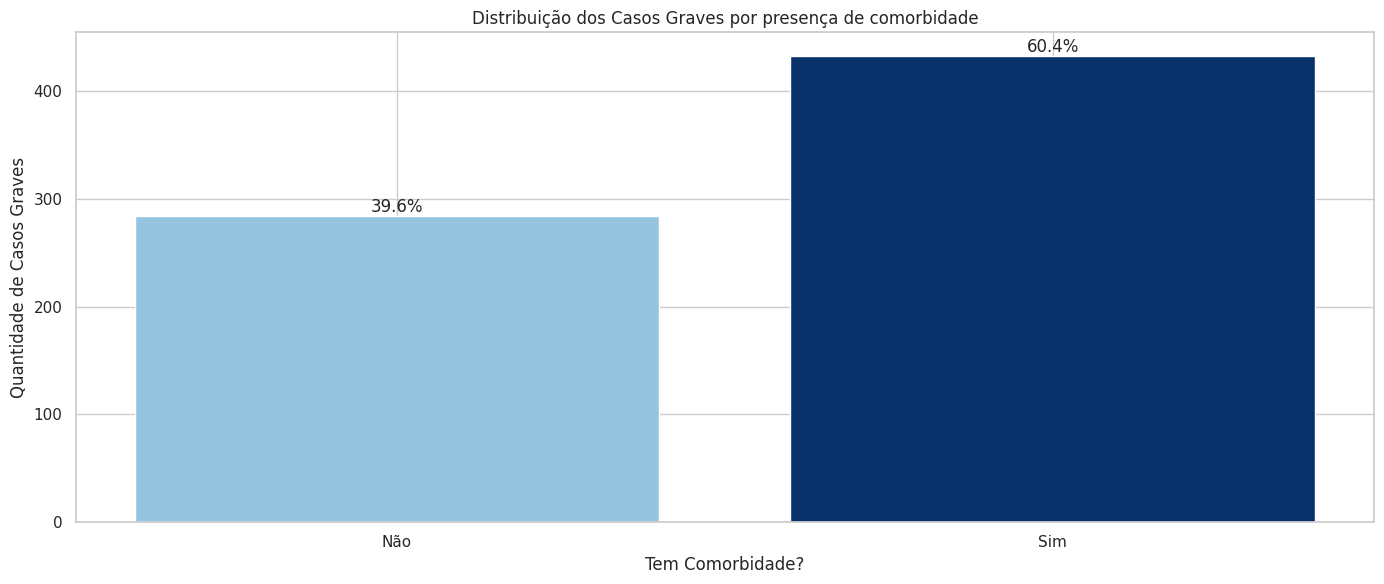


Distribuição dos Casos Graves:



,tem_comorbidade,total,graves,percentual
0,Não,902867,284,39.61%
1,Sim,255117,433,60.39%


In [ ]:
# Interferência da presença de comorbidade com o total de casos graves (internação + ventilação)

pdf = df_covid.groupby("tem_comorbidade").agg(
    total=("caso_grave", "count"),
    graves=("caso_grave", lambda x: (x == "Sim").sum())
).reset_index()

# Percentual (%)
total_graves = pdf["graves"].sum()
pdf["percentual"] = (pdf["graves"] / total_graves) * 100

# Ordenação
ordem = ["Não", "Sim"]
pdf["tem_comorbidade"] = pd.Categorical(pdf["tem_comorbidade"], categories=ordem, ordered=True)
pdf = pdf.sort_values("tem_comorbidade")

# Cores monocromáticas
norm = (pdf["graves"] - pdf["graves"].min()) / (
    pdf["graves"].max() - pdf["graves"].min()
)

cores = cm.Blues(0.4 + 0.6 * norm)

# Plot
plt.figure(figsize=(14,6))
bars = plt.bar(pdf["tem_comorbidade"], pdf["graves"], color=cores)

# Rótulos (%)
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Distribuição dos Casos Graves por presença de comorbidade")
plt.xlabel("Tem Comorbidade?")
plt.ylabel("Quantidade de Casos Graves")
plt.tight_layout()
plt.show()

pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nDistribuição dos Casos Graves:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A maioria dos casos graves está entre indivíduos com **comorbidade (60,39%)**.
- Pessoas **sem comorbidade** representam **39,61%** dos casos graves.

A variável de comorbidade considera a presença de pelo menos uma das seguintes condições:

- diabetes  
- hipertensão  
- doença respiratória  
- doença cardíaca  
- câncer  

Os dados indicam uma forte associação entre **comorbidades e agravamento da doença**, sugerindo que:

- indivíduos com condições pré-existentes possuem maior risco de desenvolver quadros severos  
- a presença de comorbidades é um fator crítico na evolução clínica  

A análise reforça a importância de atenção prioritária a grupos com comorbidades em estratégias de prevenção, monitoramento e tratamento.

---

### 📊 Busca por Atendimento (≥1 Sintoma)

Este gráfico apresenta a proporção de indivíduos com pelo menos um sintoma que buscaram atendimento de saúde.

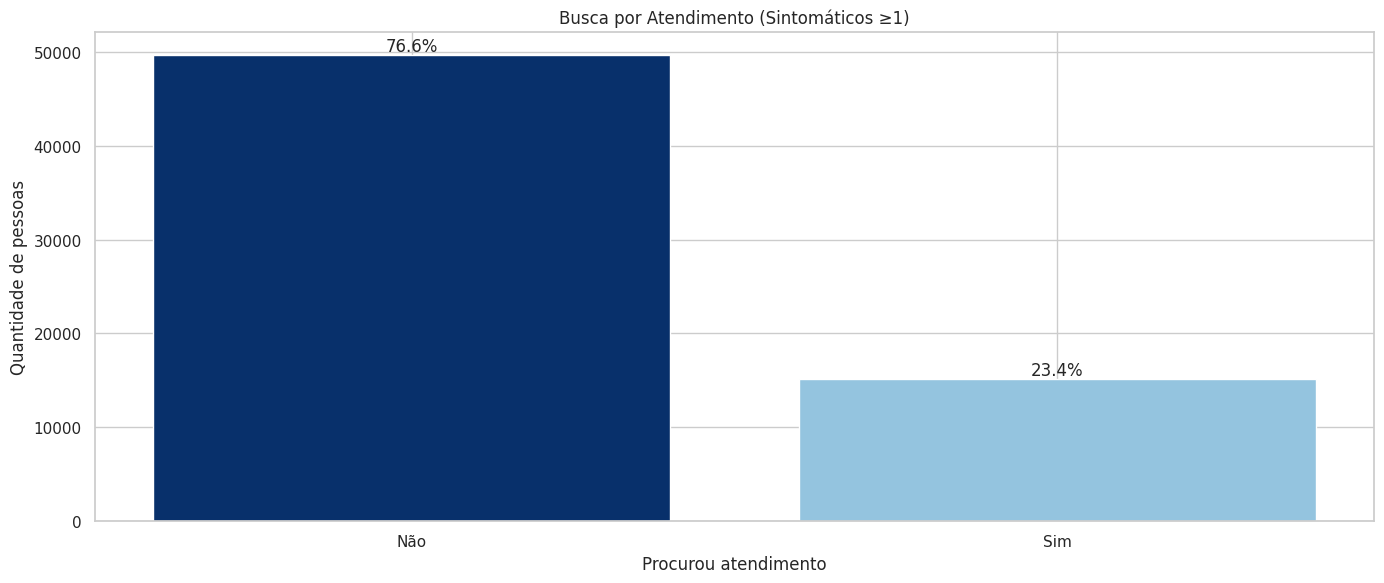


Busca por Atendimento (>=1 sintoma):



,procurou_atendimento,total,percentual
0,Não,49641,76.58%
1,Sim,15180,23.42%


In [ ]:
# Pessoas que tiveram ao menos 1 sintoma, procuraram atendimento?

sintomas = [
    "febre","tosse","dor_garganta","dificuldade_respirar",
    "dor_cabeca","dor_peito","nausea","nariz_entupido",
    "fadiga","dor_olhos","perda_olfato_paladar",
    "dor_muscular","diarreia"
]

# Contagem dos sintomas
df_analise = df_covid.copy()
df_analise["qtd_sintomas"] = sum(
    (df_analise[s] == "Sim").astype(int) for s in sintomas
)

# Filtro (>= 1 sintoma)
df_analise = df_analise[df_analise["qtd_sintomas"] >= 1]

# Remover "Não respondido/ignorado"
df_analise = df_analise[
    df_analise["procurou_atendimento"]
    .str.strip()
    .str.lower()
    .isin(["sim", "não", "nao"])
]

# Padronizar valores (opcional, mas recomendado)
df_analise["procurou_atendimento"] = df_analise["procurou_atendimento"].replace({
    "nao": "Não"
})

# Agrupando
pdf = (
    df_analise["procurou_atendimento"]
    .value_counts()
    .reset_index()
)

pdf.columns = ["procurou_atendimento", "total"]

# Percentual
total = len(df_analise)
pdf["percentual"] = (pdf["total"] / total) * 100

# Ordenar
pdf = pdf.sort_values(by="total", ascending=False)

# Cores
norm = (pdf["total"] - pdf["total"].min()) / (
    pdf["total"].max() - pdf["total"].min()
)

cores = cm.Blues(0.4 + 0.6 * norm)

# Plot
plt.figure(figsize=(14,6))
bars = plt.bar(pdf["procurou_atendimento"], pdf["total"], color=cores)

# Rótulos (%)
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = pdf.iloc[i]["percentual"]

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Busca por Atendimento (Sintomáticos ≥1)")
plt.xlabel("Procurou atendimento")
plt.ylabel("Quantidade de pessoas")
plt.tight_layout()
plt.show()

# Display
pdf_display = pdf.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nBusca por Atendimento (>=1 sintoma):\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- A maioria dos indivíduos com sintomas **não buscou atendimento (76,58%)**.
- Apenas **23,42%** procuraram assistência médica.

Os dados reforçam:

- **Baixa adesão à busca por atendimento**, mesmo com presença de sintomas  
- Possível predominância de casos leves ou autogerenciados  
- Risco de **subnotificação e atraso no diagnóstico**  

A análise destaca a importância de estratégias que incentivem a procura por atendimento, contribuindo para **melhor monitoramento e controle da doença**.

---

### 📊 Funil Assistencial

Este gráfico apresenta a jornada dos indivíduos sintomáticos dentro do sistema de saúde, desde a presença de sintomas até os desfechos mais críticos.

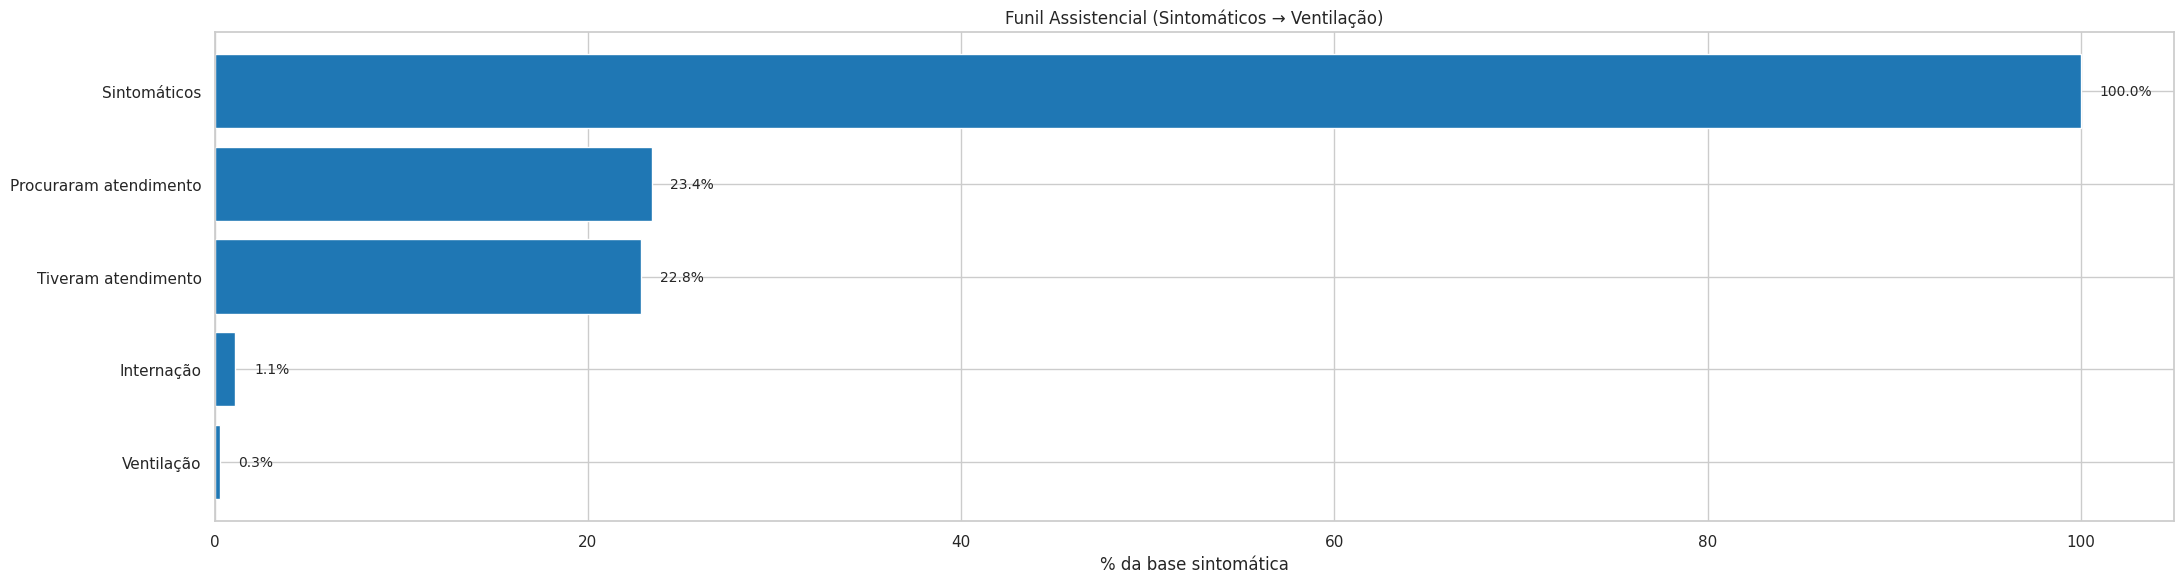


Funil Assistencial:



,etapa,total,percentual
0,Sintomáticos,64846,100.00%
1,Procuraram atendimento,15180,23.41%
2,Tiveram atendimento,14812,22.84%
3,Internação,717,1.11%
4,Ventilação,178,0.27%


In [ ]:
# Funil assistencial hospitalar dos entrevistados que sentiram ao menos 1 sintoma

pdf = df_covid.copy()

# Base: sintomáticos
pdf_base = pdf[pdf["qtd_sintomas"] >= 1]

total_base = len(pdf_base)

# Etapas do funil
etapas = {
    "Sintomáticos": pdf_base,
    "Procuraram atendimento": pdf_base[pdf_base["procurou_atendimento"] == "Sim"],
    "Tiveram atendimento": pdf_base[
        (pdf_base["procurou_atendimento"] == "Sim") &
        (pdf_base["teve_atendimento"] == "Sim")
    ],
    "Internação": pdf_base[
        (pdf_base["procurou_atendimento"] == "Sim") &
        (pdf_base["teve_atendimento"] == "Sim") &
        (pdf_base["internacao"] == "Sim")
    ],
    "Ventilação": pdf_base[
        (pdf_base["procurou_atendimento"] == "Sim") &
        (pdf_base["teve_atendimento"] == "Sim") &
        (pdf_base["internacao"] == "Sim") &
        (pdf_base["uso_ventilador"] == "Sim")
    ]
}

# Construção do resumo
dados = []
for etapa, df_etapa in etapas.items():
    total = len(df_etapa)
    perc = (total / total_base) * 100
    dados.append([etapa, total, perc])

pdf_funil = pd.DataFrame(dados, columns=["etapa", "total", "percentual"])

# Plot
plt.figure(figsize=(22,6))

# Invertendo para gerar formato de funil (topo maior)
pdf_plot = pdf_funil.sort_values("percentual", ascending=False)
bars = plt.barh(pdf_plot["etapa"], pdf_plot["percentual"], color="#1f77b4")

# Rótulos % fora da barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,  # 👈 agora fora da barra
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va='center',
        ha='left',
        fontsize=10
    )

plt.xlabel("% da base sintomática")
plt.title("Funil Assistencial (Sintomáticos → Ventilação)")
plt.xlim(0, 105)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Display
pdf_display = pdf_funil.copy()
pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\nFunil Assistencial:\n")
display(pdf_display)

### 🔍 Principais pontos de análise

- Total de **sintomáticos: 100% (64.846)** como base do funil.
- Apenas **23,41%** procuraram atendimento, indicando baixa adesão inicial.
- **22,84%** efetivamente receberam atendimento, mostrando pequena perda após a busca.

- A proporção de casos mais graves é significativamente menor:
  - **Internação: 1,11%**
  - **Ventilação: 0,27%**

Os dados evidenciam um forte afunilamento ao longo da jornada:

- grande volume de casos leves ou não assistidos no início  
- redução significativa até níveis de maior gravidade  

A análise reforça que a maioria dos casos não evolui para quadros críticos, mas também destaca uma **baixa procura por atendimento**, o que pode impactar o diagnóstico e o controle da doença.

---

### 📊 Funil Assistencial por Plano de Saúde

Este gráfico compara a jornada dos indivíduos sintomáticos com e sem plano de saúde dentro do sistema assistencial.

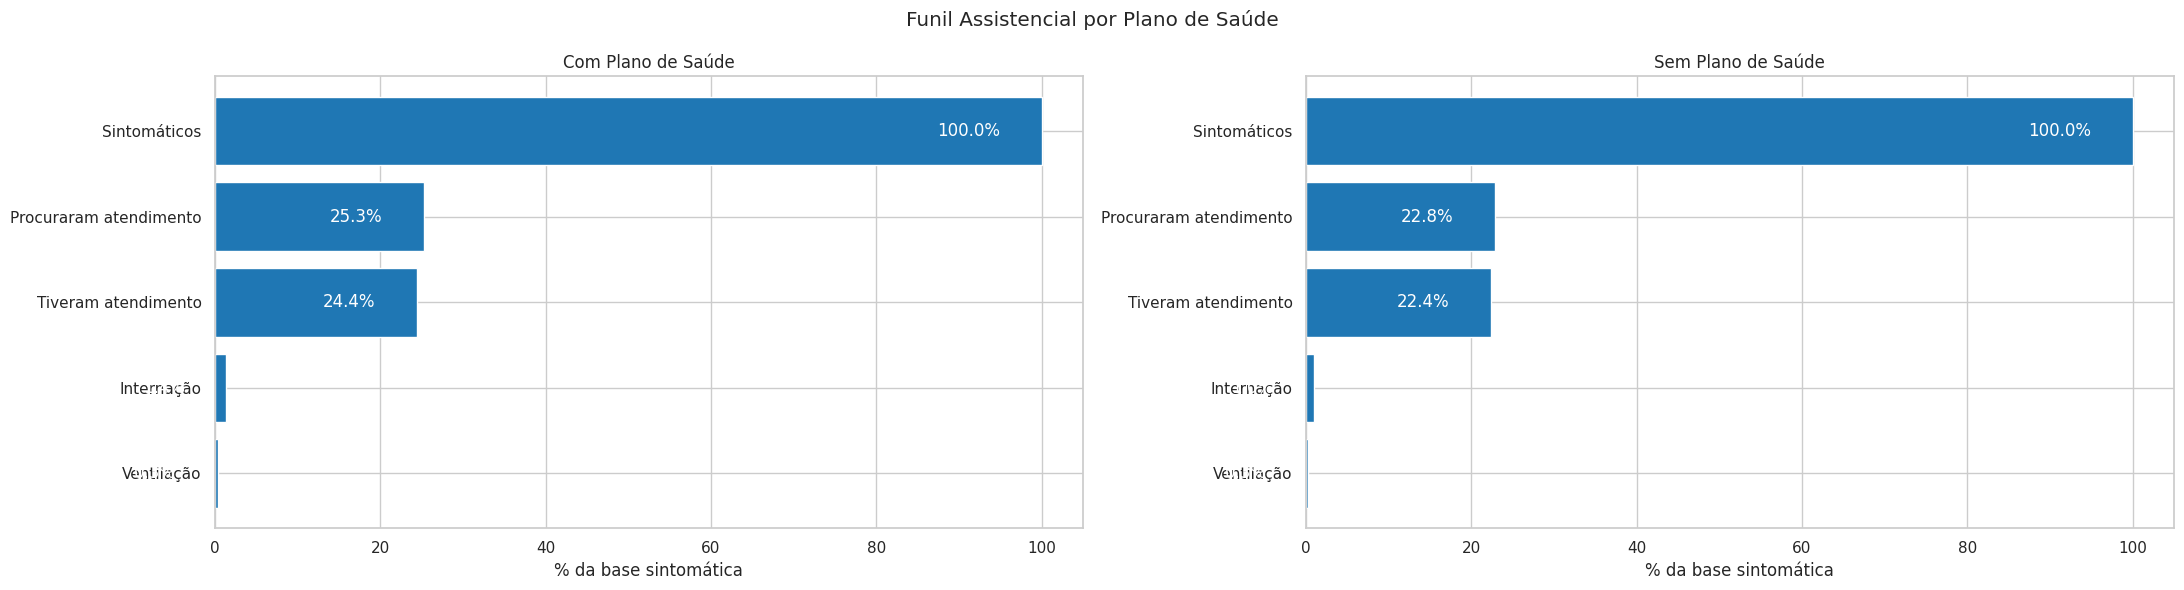


📊 Funil Assistencial — Com Plano de Saúde



,etapa,total,percentual
0,Sintomáticos,15252,100.00%
1,Procuraram atendimento,3860,25.31%
2,Tiveram atendimento,3723,24.41%
3,Internação,212,1.39%
4,Ventilação,52,0.34%



📊 Funil Assistencial — Sem Plano de Saúde



,etapa,total,percentual
0,Sintomáticos,49538,100.00%
1,Procuraram atendimento,11309,22.83%
2,Tiveram atendimento,11082,22.37%
3,Internação,504,1.02%
4,Ventilação,125,0.25%


In [ ]:
# Funil assistencial hospitalar dos entrevistados que sentiram ao menos 1 sintoma, sinalizando a presença ou não de plano de saúde

def gerar_funil(df):

    df_base = df[df["qtd_sintomas"] >= 1]
    total_base = len(df_base)

    etapas = [
        ("Sintomáticos", df_base),
        ("Procuraram atendimento", df_base[df_base["procurou_atendimento"] == "Sim"]),
        ("Tiveram atendimento", df_base[
            (df_base["procurou_atendimento"] == "Sim") &
            (df_base["teve_atendimento"] == "Sim")
        ]),
        ("Internação", df_base[
            (df_base["procurou_atendimento"] == "Sim") &
            (df_base["teve_atendimento"] == "Sim") &
            (df_base["internacao"] == "Sim")
        ]),
        ("Ventilação", df_base[
            (df_base["procurou_atendimento"] == "Sim") &
            (df_base["teve_atendimento"] == "Sim") &
            (df_base["internacao"] == "Sim") &
            (df_base["uso_ventilador"] == "Sim")
        ])
    ]

    dados = []
    for nome, d in etapas:
        total = len(d)
        perc = (total / total_base) * 100 if total_base > 0 else 0
        dados.append([nome, total, perc])

    return pd.DataFrame(dados, columns=["etapa", "total", "percentual"])


# Separação
df_sim = df_covid[df_covid["plano_saude"] == "Sim"]
df_nao = df_covid[df_covid["plano_saude"] == "Não"]

funil_sim = gerar_funil(df_sim)
funil_nao = gerar_funil(df_nao)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(22,6), sharex=True)

for ax, funil, titulo in zip(
    axes,
    [funil_sim, funil_nao],
    ["Com Plano de Saúde", "Sem Plano de Saúde"]
):
    funil_plot = funil.sort_values("percentual", ascending=False)
    bars = ax.barh(funil_plot["etapa"], funil_plot["percentual"], color="#1f77b4")

    for bar in bars:
        w = bar.get_width()
        ax.text(w - 5, bar.get_y() + bar.get_height()/2,
                f"{w:.1f}%", va='center', ha='right', color='white')

    ax.set_title(titulo)
    ax.set_xlabel("% da base sintomática")
    ax.invert_yaxis()

plt.suptitle("Funil Assistencial por Plano de Saúde")
plt.tight_layout()
plt.show()

# Display

# Formatação
funil_sim_display = funil_sim.copy()
funil_nao_display = funil_nao.copy()

funil_sim_display["percentual"] = funil_sim_display["percentual"].map(lambda x: f"{x:.2f}%")
funil_nao_display["percentual"] = funil_nao_display["percentual"].map(lambda x: f"{x:.2f}%")

print("\n📊 Funil Assistencial — Com Plano de Saúde\n")
display(funil_sim_display)

print("\n📊 Funil Assistencial — Sem Plano de Saúde\n")
display(funil_nao_display)

### 🔍 Principais pontos de análise

- Indivíduos **com plano de saúde** apresentam maior busca por atendimento:
  - **25,31%** procuraram atendimento vs. **22,83%** sem plano  
  - **24,41%** foram atendidos vs. **22,37%** sem plano  

- Em relação aos desfechos mais graves:
  - **Internação** é maior entre quem possui plano (**1,39%** vs. **1,02%**)  
  - **Ventilação** também é levemente superior (**0,34%** vs. **0,25%**)  

Os dados sugerem:

- **Maior acesso e utilização do sistema de saúde** por indivíduos com plano  
- Possível maior facilidade de entrada no sistema (consulta, triagem, internação)  

Por outro lado:

- Indivíduos **sem plano** apresentam menor progressão no funil, o que pode indicar:
  - barreiras de acesso  
  - menor procura por atendimento  
  - possível subdiagnóstico  

A análise evidencia diferenças no acesso à saúde, indicando que a posse de plano pode influenciar a **probabilidade de atendimento e desfechos clínicos registrados**, ainda que de forma sutil.

---

### 📊 Funil Assistencial por Região

Este gráfico apresenta a jornada dos indivíduos sintomáticos **com plano de saúde**, por região, permitindo comparar padrões de acesso ao sistema de saúde e desfechos clínicos.

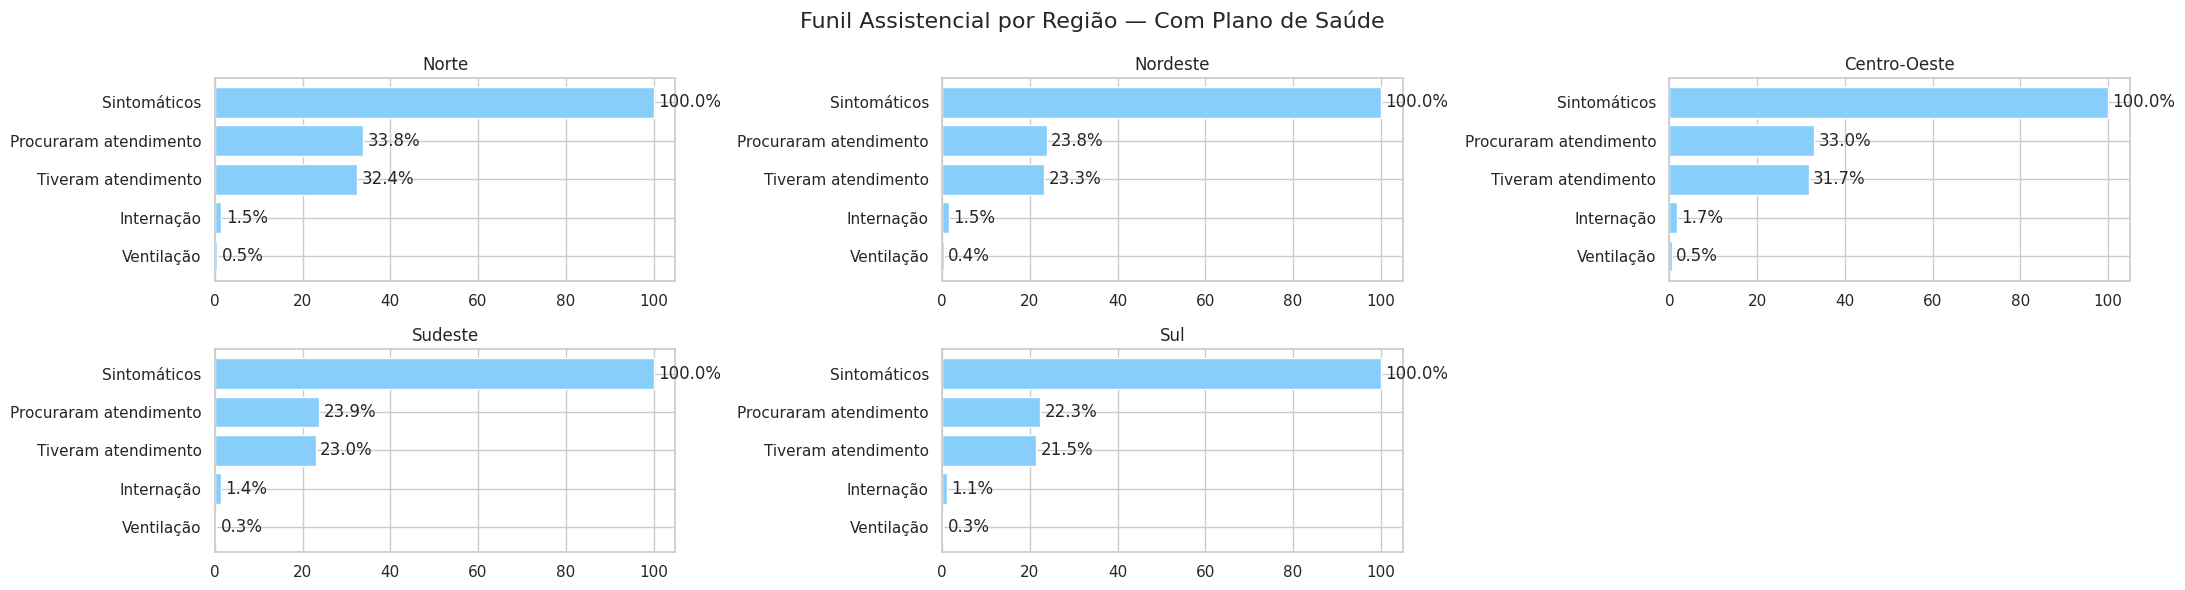

etapa,total,percentual
Sintomáticos,930,100.00%
Procuraram atendimento,314,33.76%
Tiveram atendimento,301,32.37%
Internação,14,1.51%
Ventilação,5,0.54%
etapa,total,percentual
Sintomáticos,2793,100.00%
Procuraram atendimento,666,23.85%
Tiveram atendimento,650,23.27%
Internação,42,1.50%


In [ ]:
# Funil assistencial por região, de pessoas que sentiram ao menos 1 sintoma, e que possuem plano

def display_lado_a_lado(dfs, titulos):
    html = "<div style='display:flex; gap:20px;'>"

    for df, titulo in zip(dfs, titulos):
        html += f"""
        <div style='flex:1'>
            <h4 style='text-align:center'>{titulo}</h4>
            {df.to_html(index=False)}
        </div>
        """

    html += "</div>"
    display(HTML(html))


regioes = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

fig, axes = plt.subplots(2, 3, figsize=(22,6))
axes = axes.flatten()

# Listas para display horizontal
dfs_display = []
titulos = []

for i, regiao in enumerate(regioes):

    df_filtrado = df_covid[
        (df_covid["regiao"] == regiao) &
        (df_covid["plano_saude"] == "Sim")
    ]

    funil = gerar_funil(df_filtrado)
    funil_plot = funil.sort_values("percentual", ascending=False)

    # Preparando o display
    pdf_display = funil.copy()
    pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")
    dfs_display.append(pdf_display)
    titulos.append(regiao)

    # Plot
    ax = axes[i]
    bars = ax.barh(funil_plot["etapa"], funil_plot["percentual"], color="#87cefa")

    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + 1,
            bar.get_y() + bar.get_height()/2,
            f"{w:.1f}%",
            va='center',
            ha='left'
        )

    ax.set_title(f"{regiao}")
    ax.set_xlim(0, 105)
    ax.invert_yaxis()

# Removendo eixo vazio
axes[-1].axis("off")

plt.suptitle("Funil Assistencial por Região — Com Plano de Saúde", fontsize=16)
plt.tight_layout()
plt.show()

# Display final
display_lado_a_lado(dfs_display, titulos)

### 🔍 Principais pontos de análise

- As regiões **Norte (33,76%)** e **Centro-Oeste (32,97%)** apresentam as maiores taxas de **busca por atendimento**.
- Já **Sul (22,35%)**, **Sudeste (23,86%)** e **Nordeste (23,85%)** possuem níveis mais baixos e semelhantes.

- Em relação ao atendimento efetivo, para entrevistados com plano de saúde:
  - **Norte (32,37%)** e **Centro-Oeste (31,73%)** mantêm os maiores percentuais  
  - Demais regiões ficam próximas de **21% a 23%**

- Sobre os casos mais graves:
  - **Centro-Oeste (1,68%)** apresenta a maior taxa de internação  
  - **Norte (1,51%)** e **Nordeste (1,50%)** também se destacam  
  - **Sul (1,08%)** possui a menor taxa  

- Uso de ventilação:
  - Maior no **Norte (0,54%)** e **Centro-Oeste (0,50%)**  
  - Menor no **Sul (0,28%)** e **Sudeste (0,29%)**

Os dados indicam diferenças regionais relevantes:

- Regiões com maior busca por atendimento (**Norte e Centro-Oeste**) também apresentam maior pressão nos níveis mais críticos  
- Regiões mais populosas (**Sudeste e Sul**) mostram menor progressão no funil  

A análise reforça a existência de **desigualdades regionais no acesso e nos desfechos de saúde**, sendo essencial considerar essas diferenças em estratégias de gestão e alocação de recursos.

---

### 📊 Funil Assistencial por Região — Sem Plano de Saúde

Este gráfico apresenta a jornada dos indivíduos sintomáticos **sem plano de saúde**, por região, permitindo avaliar diferenças regionais no acesso e nos desfechos clínicos dentro do sistema público.

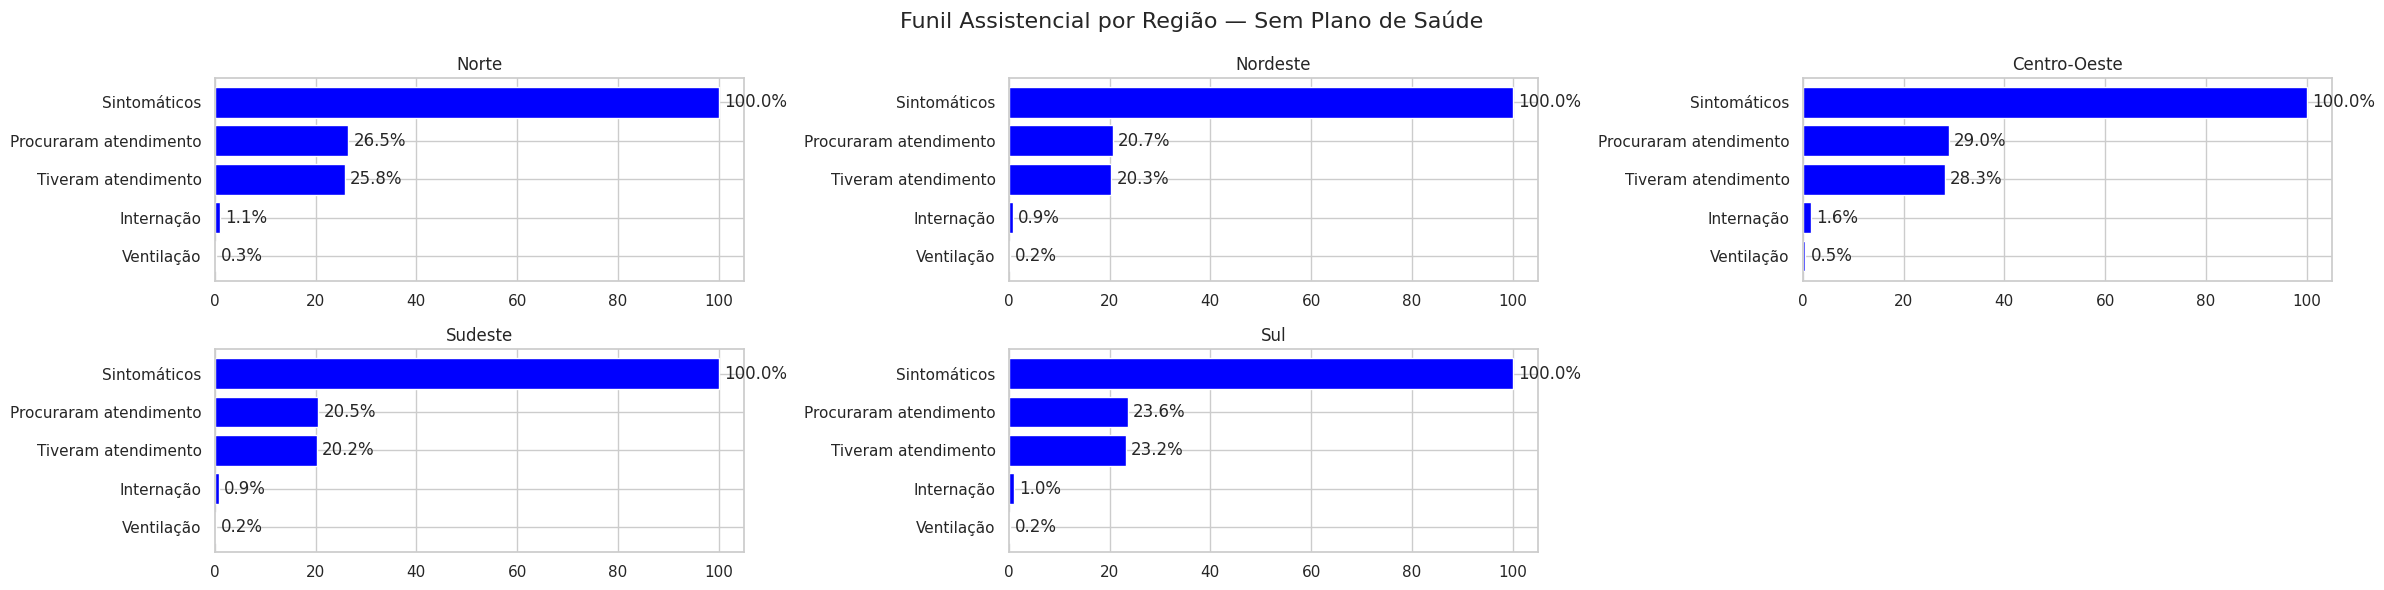

etapa,total,percentual
Sintomáticos,6876,100.00%
Procuraram atendimento,1823,26.51%
Tiveram atendimento,1772,25.77%
Internação,73,1.06%
Ventilação,18,0.26%
etapa,total,percentual
Sintomáticos,17578,100.00%
Procuraram atendimento,3637,20.69%
Tiveram atendimento,3574,20.33%
Internação,155,0.88%


In [ ]:
# Funil assistencial por região, de pessoas que sentiram ao menos 1 sintoma, e que não possuem plano

def display_lado_a_lado(dfs, titulos):
    html = "<div style='display:flex; gap:20px;'>"

    for df, titulo in zip(dfs, titulos):
        html += f"""
        <div style='flex:1'>
            <h4 style='text-align:center'>{titulo}</h4>
            {df.to_html(index=False)}
        </div>
        """

    html += "</div>"
    display(HTML(html))


regioes = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
fig, axes = plt.subplots(2, 3, figsize=(24,6))
axes = axes.flatten()

# Listas para display horizontal
dfs_display = []
titulos = []

for i, regiao in enumerate(regioes):

    df_filtrado = df_covid[
        (df_covid["regiao"] == regiao) &
        (df_covid["plano_saude"] == "Não")
    ]

    funil = gerar_funil(df_filtrado)
    funil_plot = funil.sort_values("percentual", ascending=False)

    # Preparando o display
    pdf_display = funil.copy()
    pdf_display["percentual"] = pdf_display["percentual"].map(lambda x: f"{x:.2f}%")
    dfs_display.append(pdf_display)
    titulos.append(regiao)

    # Plot
    ax = axes[i]
    bars = ax.barh(funil_plot["etapa"], funil_plot["percentual"], color="blue")

    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + 1,
            bar.get_y() + bar.get_height()/2,
            f"{w:.1f}%",
            va='center',
            ha='left'
        )

    ax.set_title(f"{regiao}")
    ax.set_xlim(0, 105)
    ax.invert_yaxis()

# Removendo eixo vazio
axes[-1].axis("off")

plt.suptitle("Funil Assistencial por Região — Sem Plano de Saúde", fontsize=16)
plt.tight_layout()
plt.show()

# Display final

display_lado_a_lado(dfs_display, titulos)

### 🔍 Principais pontos de análise

- A **maior busca por atendimento** ocorre, também, no **Centro-Oeste (29,04%)**, seguido pelo **Norte (26,51%)**  
- **Sul (23,65%)** apresenta nível intermediário  
- **Nordeste (20,69%)** e **Sudeste (20,52%)** possuem os menores percentuais  

- Em relação ao atendimento efetivo:
  - **Centro-Oeste (28,25%)** e **Norte (25,77%)** mantêm os maiores níveis  
  - **Sul (23,24%)** aparece em posição intermediária  
  - **Nordeste (20,33%)** e **Sudeste (20,19%)** permanecem mais baixos  

- Sobre os desfechos mais graves:
  - **Centro-Oeste (1,64%)** apresenta a maior taxa de internação  
  - **Sul (1,04%)** e **Norte (1,06%)** vêm na sequência  
  - **Nordeste (0,88%)** e **Sudeste (0,89%)** apresentam menores taxas  

- Uso de ventilação:
  - Maior no **Centro-Oeste (0,50%)**  
  - Seguido por **Norte (0,26%)** e **Sul (0,24%)**  
  - Menor no **Nordeste (0,21%)** e **Sudeste (0,20%)**

Os dados sugerem padrões importantes:

- **Centro-Oeste** se destaca com maior utilização do sistema e maior pressão hospitalar  
- **Norte** também apresenta alta demanda relativa por atendimento  
- **Sudeste e Nordeste**, apesar de mais populosos, apresentam menor progressão no funil assistencial  

A análise evidencia possíveis **desigualdades no acesso à saúde pública**, além de diferenças regionais na intensidade dos casos e utilização de recursos hospitalares.

---

## Heatmap de Correlação — Variáveis Relacionadas à COVID-19

Este heatmap apresenta a correlação entre variáveis clínicas, comportamentais e demográficas relacionadas aos casos de COVID-19, permitindo identificar padrões e possíveis relações entre fatores de risco e desfechos da doença.

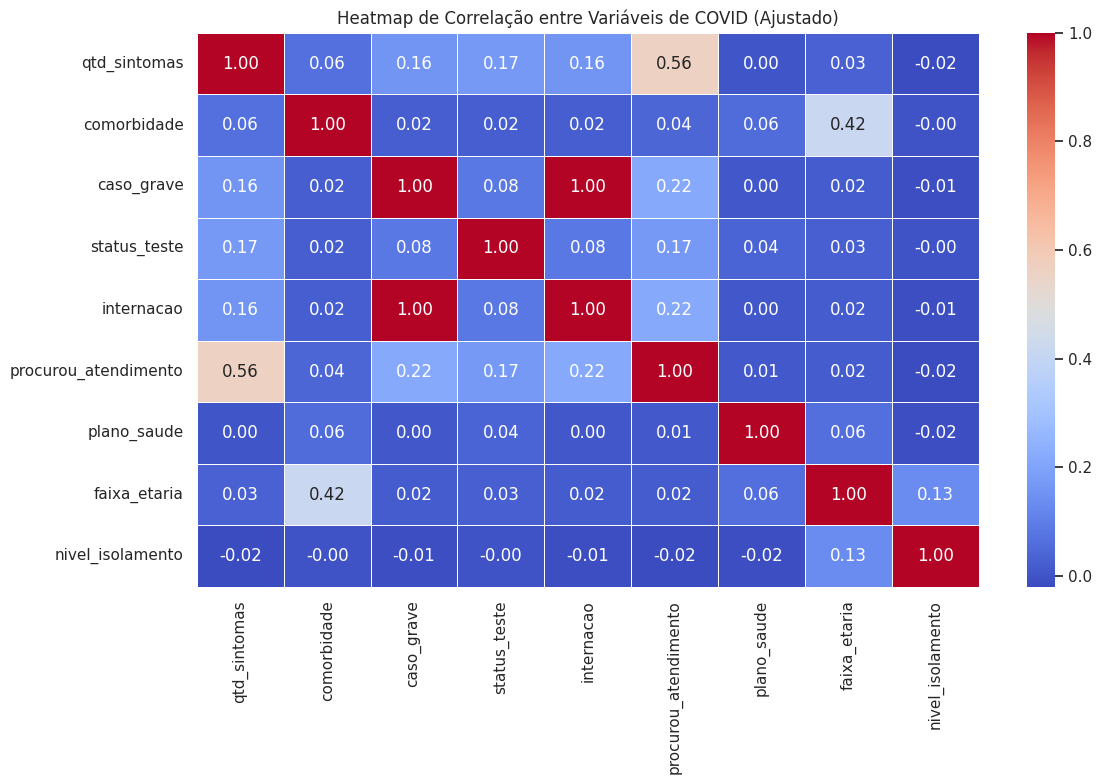

In [ ]:
# Heatmap

# Criando dataframe transformado
pdf = df_covid.copy()

# Transformações
pdf["qtd_sintomas"] = pdf["qtd_sintomas"].astype(int)
pdf["comorbidade"] = (pdf["tem_comorbidade"] == "Sim").astype(int)
pdf["caso_grave"] = (pdf["caso_grave"] == "Sim").astype(int)
pdf["status_teste"] = (pdf["status_teste"] == "Positivo").astype(int)
pdf["internacao"] = (pdf["internacao"] == "Sim").astype(int)
pdf["procurou_atendimento"] = (pdf["procurou_atendimento"] == "Sim").astype(int)
pdf["plano_saude"] = (pdf["plano_saude"] == "Sim").astype(int)
pdf["faixa_etaria"] = pdf["faixa_etaria"].astype("category").cat.codes
pdf["nivel_isolamento"] = pdf["nivel_isolamento"].astype("category").cat.codes

# Selecionar apenas colunas finais
pdf_final = pdf[
    [
        "qtd_sintomas",
        "comorbidade",
        "caso_grave",
        "status_teste",
        "internacao",
        "procurou_atendimento",
        "plano_saude",
        "faixa_etaria",
        "nivel_isolamento"
    ]
]

# Correlação
corr = pdf_final.corr()

# Plot
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap de Correlação entre Variáveis de COVID (Ajustado)")
plt.tight_layout()
plt.show()

### Principais Insights

#### Gravidade e Internação
- Correlação **perfeita (1.00)** entre `caso_grave` e `internacao`
- Indica consistência nos dados: casos graves estão diretamente associados à necessidade de internação

---

#### 1. Sintomas influenciam busca por atendimento
- Correlação moderada entre:
  - `qtd_sintomas` × `procurou_atendimento` → **0.56**
  
  ➡️ Indica que quanto maior o número de sintomas, maior a probabilidade do indivíduo procurar atendimento médico. Comportamento esperado e coerente, reforçando a consistência dos dados.
---

#### 2. Sintomas e Diagnóstico
- `qtd_sintomas` apresenta correlação positiva, ainda que baixa/moderada, com:
  - `status_teste` (**0.17**)
  - `caso_grave` (**0.16**)
  - `internacao` (**0.16**)

  ➡️ Sugere que o aumento de sintomas está associado a maior probabilidade de:
- teste positivo
- agravamento do quadro

---

#### 3. Comorbidades e Idade
- Correlação moderada entre:
  - `comorbidade` e `faixa_etaria` (**0.42**)

  ➡️ Indica que indivíduos mais velhos tendem a apresentar mais comorbidades

---

#### 4. Resultado do Teste
- `status_teste` possui correlação fraca com as demais variáveis
- Destaque para:
  - `qtd_sintomas` (**0.17**)

  ➡️ Indica que o diagnóstico positivo não depende fortemente de uma única variável isolada

---

#### 5. Atendimento relacionado à gravidade (moderadamente)
- `procurou_atendimento` × `caso_grave` → **0.22**
- `procurou_atendimento` × `internacao` → **0.22**

  ➡️ Correlação fraca a moderada
- Indica que ainda que alguns casos graves buscaram atendimento, nem todos eles o fizeram imediatamente  
- Pode indicar atraso na busca por cuidado ou limitações de acesso

---

### Conclusão

- **Sintomas** são o principal indicador inicial para procura de atendimento
- **Comorbidades + idade** influenciam o perfil do paciente
- **Gravidade está diretamente ligada à internação**
- **Variáveis comportamentais** apresentam impacto mais difuso

---

### 📊 Proporção de Alto Risco por Atividade Econômica

Este gráfico apresenta a proporção de indivíduos classificados como **alto risco comportamental** por setor econômico.

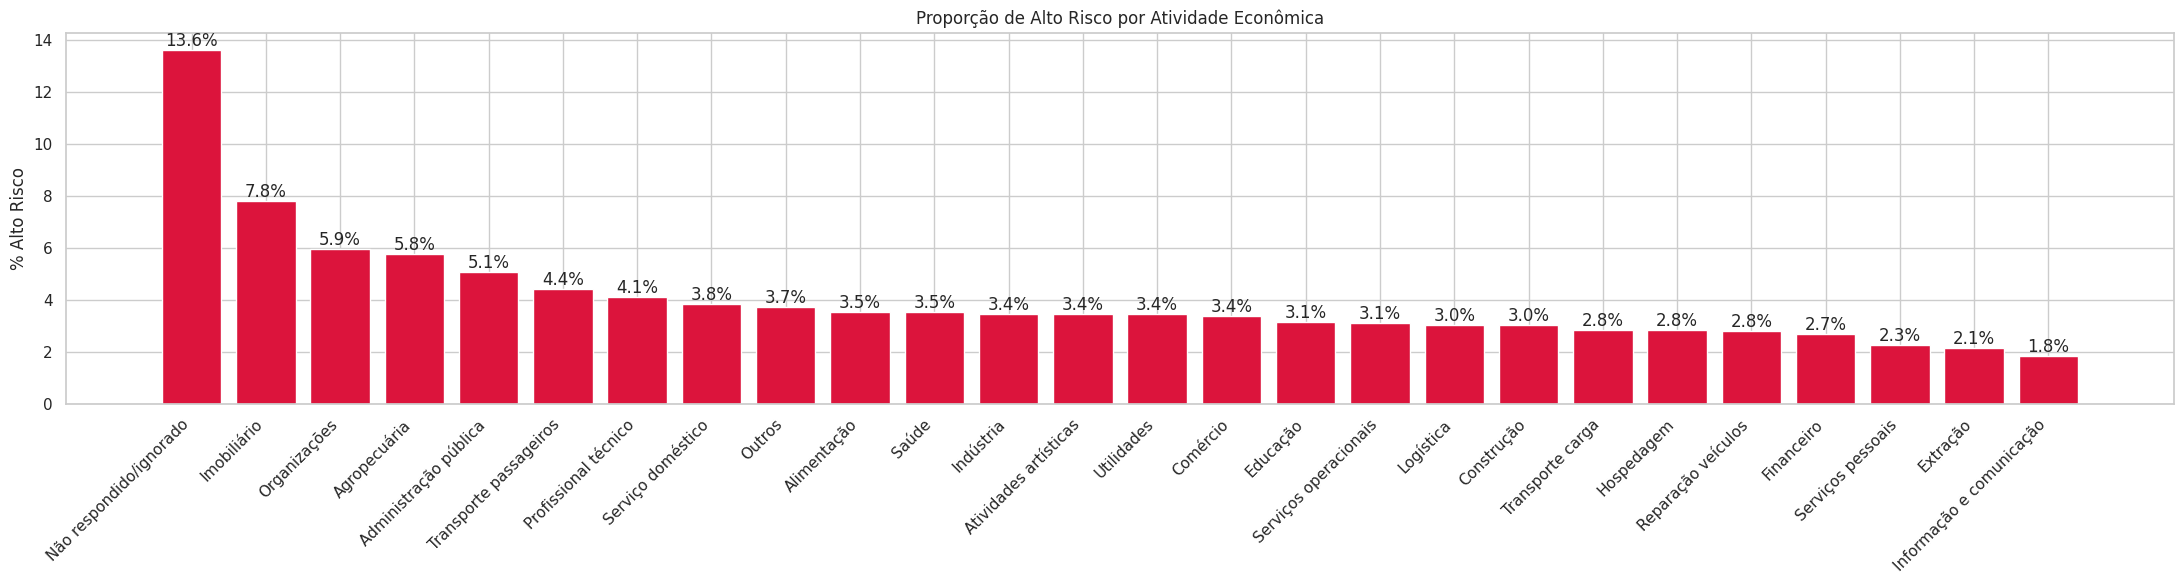


Proporção de Alto Risco por Atividade Econômica:



,atividade_economica,total,alto,percentual_alto
0,Não respondido/ignorado,729231,99038,13.58%
1,Imobiliário,2154,168,7.80%
2,Organizações,1685,100,5.93%
3,Agropecuária,62361,3597,5.77%
4,Administração pública,24805,1255,5.06%
5,Transporte passageiros,8674,381,4.39%
6,Profissional técnico,11255,460,4.09%
7,Serviço doméstico,22094,843,3.82%
8,Outros,28294,1057,3.74%
9,Alimentação,20187,713,3.53%


In [ ]:
# Analisando a proporção de entrevistados classificados como grupo de Alto Risco (idade 60+, com presença de comorbidade), conforme o seu setor de atuação de negócio

pdf = df_covid.copy()

pdf["alto_risco"] = (pdf["indice_risco"] == "Alto").astype(int)

resumo = pdf.groupby("atividade_economica").agg(
    total=("alto_risco", "count"),
    alto=("alto_risco", "sum")
).reset_index()

resumo["percentual_alto"] = (resumo["alto"] / resumo["total"]) * 100

# Ordenar
resumo = resumo.sort_values("percentual_alto", ascending=False)
resumo_display = resumo.copy().reset_index(drop=True)

# Plot
plt.figure(figsize=(22,6))

bars = plt.bar(
    resumo["atividade_economica"],
    resumo["percentual_alto"],
    color="crimson"
)

# Rótulos de %
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Proporção de Alto Risco por Atividade Econômica")
plt.ylabel("% Alto Risco")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

resumo_display["percentual_alto"] = resumo_display["percentual_alto"].map(lambda x: f"{x:.2f}%")

print("\nProporção de Alto Risco por Atividade Econômica:\n")
display(resumo_display)


### 🔍 Principais pontos de análise

- A categoria **“Não respondido/ignorado” (13,58%)** apresenta a maior proporção, indicando possível viés ou heterogeneidade no grupo.

- Entre as atividades econômicas:
  - **Imobiliário (7,80%)**, **Organizações (5,93%)** e **Agropecuária (5,77%)** apresentam os maiores níveis de alto risco  
  - **Administração pública (5,06%)** também se destaca acima da média  

- Setores com exposição moderada:
  - **Transporte de passageiros (4,39%)**
  - **Profissional técnico (4,09%)**
  - **Serviço doméstico (3,82%)**
  - **Alimentação (3,53%)**
  - **Saúde (3,52%)**
  - **Indústria (3,45%)**

- Setores com menor proporção de alto risco:
  - **Serviços pessoais (2,27%)**
  - **Extração (2,13%)**
  - **Informação e comunicação (1,85%)**

Os dados sugerem:

- Setores com maior interação social ou menor possibilidade de trabalho remoto tendem a apresentar maior risco  
- Atividades com maior estrutura organizacional ou controle podem apresentar níveis mais baixos  

A análise permite identificar setores prioritários para **políticas de prevenção, comunicação e mitigação de risco**, especialmente em cenários de crise sanitária.

---

### 📊 Casos Graves por Região e Atividade Econômica — Top 5

Este gráfico apresenta os **casos graves de COVID-19 por atividade econômica**, considerando os **top 5 setores em cada região**, permitindo identificar setores com maior vulnerabilidade e risco de complicações.

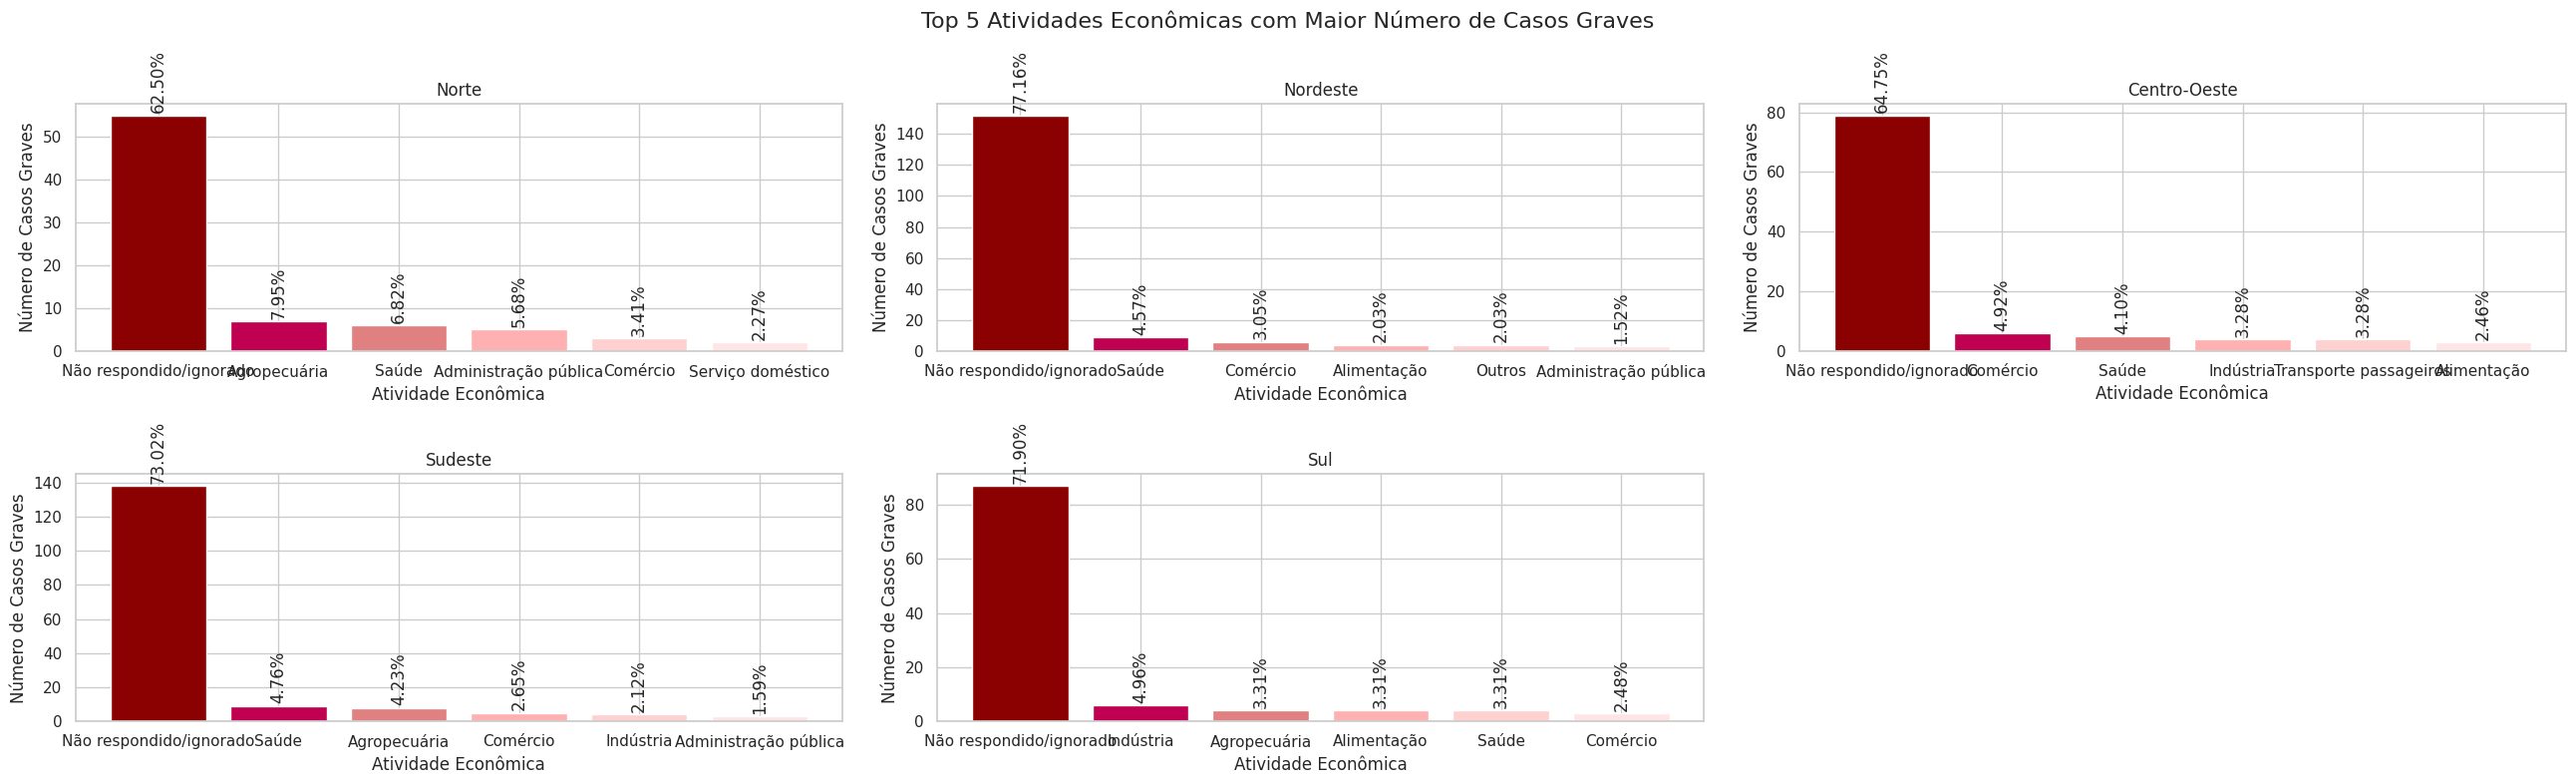

Total de casos graves por região:
      regiao  total_graves
Centro-Oeste           122
    Nordeste           197
       Norte            88
     Sudeste           189
         Sul           121




atividade_economica,casos_graves,perc_grave
Não respondido/ignorado,55,62.50%
Agropecuária,7,7.95%
Saúde,6,6.82%
Administração pública,5,5.68%
Comércio,3,3.41%
Serviço doméstico,2,2.27%
Total,78,88.64%
atividade_economica,casos_graves,perc_grave
Não respondido/ignorado,152,77.16%
Saúde,9,4.57%


In [ ]:
# Análise das top 5 atividades econômicas associadas ao número de casos graves , por região.

def display_lado_a_lado(dfs, titulos):
    html = "<div style='display:flex; gap:20px;'>"

    for df, titulo in zip(dfs, titulos):
        html += f"""
        <div style='flex:1'>
            <h4 style='text-align:center'>{titulo}</h4>
            {df.to_html(index=False)}
        </div>
        """

    html += "</div>"
    display(HTML(html))


# Configuração
regioes = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

# Calculando total de casos graves por região
totais_por_regiao = df_covid[df_covid["caso_grave"] == "Sim"].groupby("regiao").agg(
    total_graves=("caso_grave", "count")
).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(26,8))
axes = axes.flatten()

dfs_display = []
titulos = []

# Paleta azul/cinza (monocromática)
cores = ["#8B0000", "#C00050", "#E08080", "#FFB0B0", "#FFD0D0", "#FFE5E5"]

# Local por região
for i, regiao in enumerate(regioes):
    df_regiao = df_covid[df_covid["regiao"] == regiao]

    # Total de casos graves na região (contando apenas 'Sim')
    total_graves = (df_regiao["caso_grave"] == "Sim").sum()

    # Agrupamento por atividade econômica (agora inclui 'Não respondido/ignorado' se existir)
    resumo = df_regiao[df_regiao["caso_grave"] == "Sim"].groupby("atividade_economica").agg(
        casos_graves=("caso_grave", "count")
    ).reset_index()

    # Percentual sobre total de casos graves da região
    resumo["perc_grave"] = (resumo["casos_graves"] / total_graves) * 100

    # Top 5 atividades mais críticas
    resumo_top = resumo.nlargest(6, "casos_graves").copy()

    # Adicionando linha total (soma dos top 5)
    total_df = pd.DataFrame({
        "atividade_economica": ["Total"],
        "casos_graves": [resumo_top["casos_graves"].sum()],
        "perc_grave": [resumo_top["perc_grave"].sum()]
    })

    # Concatena para display
    display_df = pd.concat([resumo_top, total_df], ignore_index=True)

    # Formatar percentual com 2 casas decimais
    display_df["perc_grave"] = display_df["perc_grave"].map(lambda x: f"{x:.2f}%")
    dfs_display.append(display_df)
    titulos.append(regiao)

    # Plot
    ax = axes[i]
    bar_colors = [cores[j % len(cores)] for j in range(len(resumo_top))]
    bars = ax.bar(
        resumo_top["atividade_economica"],
        resumo_top["casos_graves"],
        color = bar_colors
    )

    ax.set_title(regiao)
    ax.set_ylabel("Número de Casos Graves")
    ax.set_xlabel("Atividade Econômica")
    ax.tick_params(axis='x', rotation=0)

    # Adicionando rótulos verticais com percentual (xx.xx %)
    for bar, perc in zip(bars, resumo_top["perc_grave"]):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + max(resumo_top["casos_graves"])*0.01,
            f"{perc:.2f}%",
            ha='center',
            va='bottom',
            rotation=90
        )

# Remover eixo vazio
axes[-1].axis("off")

plt.suptitle("Top 5 Atividades Econômicas com Maior Número de Casos Graves", fontsize=16)
plt.tight_layout()
plt.show()

# Print do total de casos graves por região
print("Total de casos graves por região:")
print(totais_por_regiao.to_string(index=False))
print("\n")  # espaço extra antes do display lado a lado

# Display
display_lado_a_lado(dfs_display, titulos)

### 🔍 Principais pontos de análise

#### Total de casos graves por região
- **Nordeste:** 197  
- **Sudeste:** 189  
- **Centro-Oeste:** 122  
- **Sul:** 121  
- **Norte:** 88  

#### Distribuição por atividade econômica (Top 5) em cada região

**Norte (78 casos contabilizados):**
- Não respondido/ignorado — 55 casos (62,50%)  
- Agropecuária — 7 casos (7,95%)  
- Saúde — 6 casos (6,82%)  
- Administração pública — 5 casos (5,68%)  
- Comércio — 3 casos (3,41%)  

**Nordeste (178 casos contabilizados):**
- Não respondido/ignorado — 152 casos (77,16%)  
- Saúde — 9 casos (4,57%)  
- Comércio — 6 casos (3,05%)  
- Alimentação — 4 casos (2,03%)  
- Outros — 4 casos (2,03%)  

**Centro-Oeste (101 casos contabilizados):**
- Não respondido/ignorado — 79 casos (64,75%)  
- Comércio — 6 casos (4,92%)  
- Saúde — 5 casos (4,10%)  
- Indústria — 4 casos (3,28%)  
- Transporte passageiros — 4 casos (3,28%)  

**Sudeste (167 casos contabilizados):**
- Não respondido/ignorado — 138 casos (73,02%)  
- Saúde — 9 casos (4,76%)  
- Agropecuária — 8 casos (4,23%)  
- Comércio — 5 casos (2,65%)  
- Indústria — 4 casos (2,12%)  

**Sul (108 casos contabilizados):**
- Não respondido/ignorado — 87 casos (71,90%)  
- Indústria — 6 casos (4,96%)  
- Agropecuária — 4 casos (3,31%)  
- Alimentação — 4 casos (3,31%)  
- Saúde — 4 casos (3,31%)  

Os dados indicam que:

- O grupo **“Não respondido/ignorado”** aparece como o mais frequente entre os casos graves, mas isso se deve principalmente à **falta de informação preenchida pelos entrevistados** quando tiveram casos graves, e não necessariamente a uma atividade econômica específica.
- Entre os setores identificáveis, **Saúde, Comércio, Indústria e Agropecuária** aparecem consistentemente entre os 5 maiores, refletindo maior exposição ou vulnerabilidade  
- Essas informações podem orientar **políticas de proteção ocupacional** e **priorização de recursos** em situações pandêmicas futuras  

---

### 📊 Casos Graves por Atividade Econômica e Kit de Prevenção

Este gráfico apresenta o **total e percentual de casos graves** distribuídos por **atividade econômica** e pelo **uso de kit de prevenção** (Completo ou Incompleto).

Total de casos graves: 717



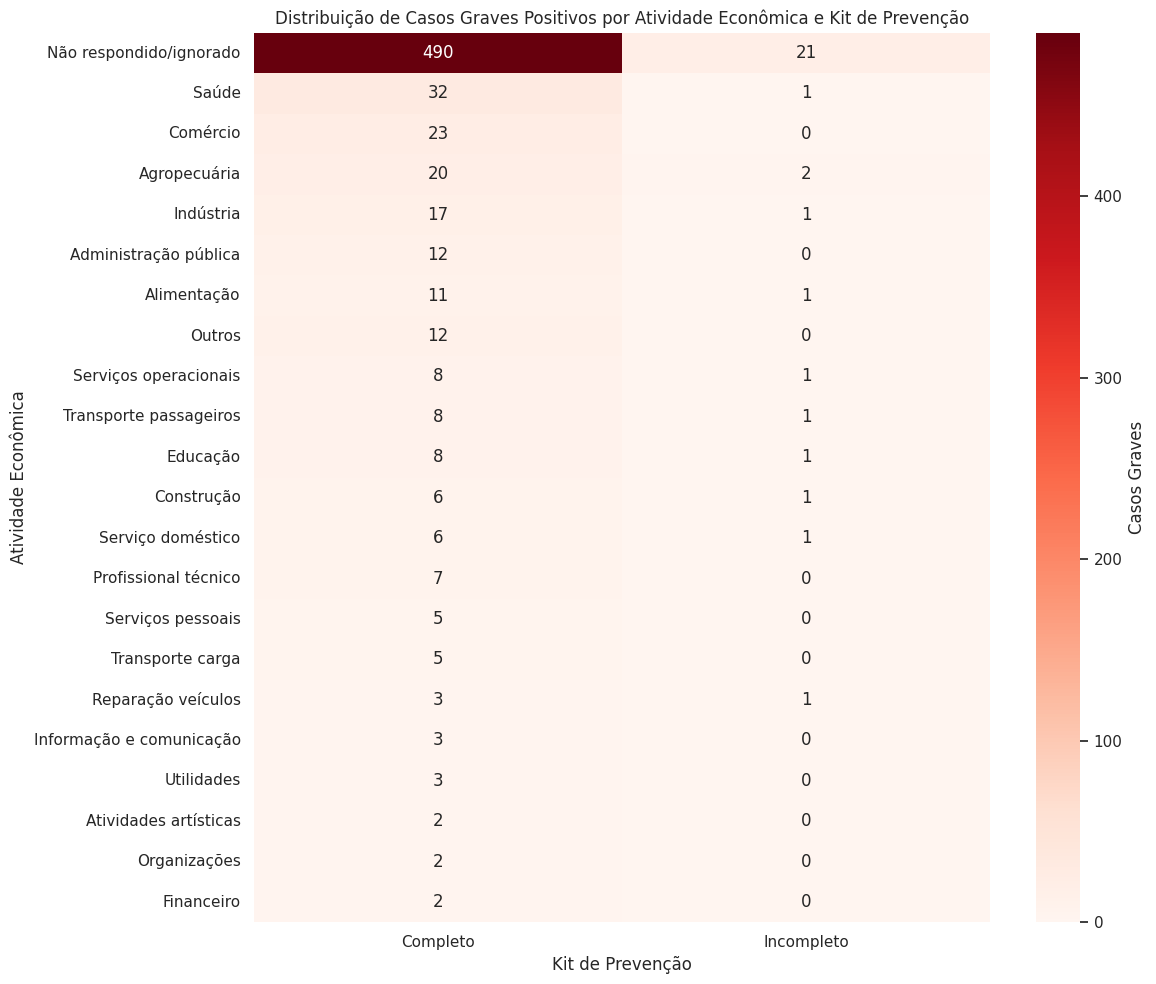

Casos Graves por Atividade Econômica e Kit de Prevenção (absoluto e percentual):



,atividade_economica,kit_prevencao,graves,percentual_graves
0,Administração pública,Completo,12,1.67%
1,Agropecuária,Completo,20,2.79%
2,Agropecuária,Incompleto,2,0.28%
3,Alimentação,Completo,11,1.53%
4,Alimentação,Incompleto,1,0.14%
5,Atividades artísticas,Completo,2,0.28%
6,Comércio,Completo,23,3.21%
7,Construção,Completo,6,0.84%
8,Construção,Incompleto,1,0.14%
9,Educação,Completo,8,1.12%


In [ ]:
# Distribuição de casos graves por atividade econômica e presença ou não de kit de prevenção
pdf = df_covid.copy()

# Filtrar apenas casos graves positivos e remover 'Não respondido/ignorado'
pdf = pdf[(pdf["caso_grave"] == "Sim")]

# Total de casos graves
total_graves = len(pdf)
print(f"Total de casos graves: {total_graves}\n")

# Agrupamento por atividade econômica e kit de prevenção
resumo_kit = pdf.groupby(["atividade_economica", "kit_prevencao"]).agg(
    graves=("status_teste", "count")
).reset_index()

# Pivot para heatmap: linhas = atividade, colunas = kit
resumo_pivot = resumo_kit.pivot(index="atividade_economica", columns="kit_prevencao", values="graves").fillna(0)

# Ordenar pela soma de casos graves
resumo_pivot["total"] = resumo_pivot.sum(axis=1)
resumo_pivot = resumo_pivot.sort_values("total", ascending=False).drop(columns="total")

# Heatmap com Seaborn
plt.figure(figsize=(12,10))
sns.heatmap(resumo_pivot, annot=True, fmt=".0f", cmap="Reds", cbar_kws={'label': 'Casos Graves'})
plt.title("Distribuição de Casos Graves Positivos por Atividade Econômica e Kit de Prevenção")
plt.xlabel("Kit de Prevenção")
plt.ylabel("Atividade Econômica")
plt.tight_layout()
plt.show()

# Display dos dados com percentual sobre o total de 717 casos graves
resumo_display = resumo_kit.copy()
resumo_display["percentual_graves"] = (resumo_display["graves"] / total_graves) * 100
resumo_display["percentual_graves"] = resumo_display["percentual_graves"].map(lambda x: f"{x:.2f}%")

print("Casos Graves por Atividade Econômica e Kit de Prevenção (absoluto e percentual):\n")
display(resumo_display)

### 🔍 Principais pontos de análise

- O grupo **“Não respondido/ignorado”** domina a contagem de casos graves (68,34% com kit completo), refletindo **limitações de preenchimento de dados**, não necessariamente risco maior.
- Entre as atividades econômicas identificáveis:
  - **Saúde** apresenta o maior percentual de casos graves (4,46%) entre os grupos com kit completo.  
  - **Comércio** (3,21%) e **Indústria** (2,37%) também têm participação relevante.
- Em geral, **a maioria dos casos graves ocorreu mesmo com uso de kit completo**, sugerindo que **o kit de prevenção pode reduzir exposição, mas não garante proteção contra agravamento**, especialmente para indivíduos expostos em atividades de maior risco ou vulnerabilidade.
- Casos graves são mais influenciados por **perfil de risco comportamental, idade e comorbidades** do que apenas pelo uso de kit preventivo.

O incentivo e a promoção de **medidas complementares, como distanciamento, isolamento adequado e atenção a comorbidades**, são críticas para evitar casos graves, além do simples uso de kit preventivo.

---

# Síntese dos principais achados

1. A base tem caráter populacional, e não hospitalar, o que explica a baixa prevalência geral de sintomas.
2. Entre os sintomas observados, dor de cabeça, nariz entupido e tosse foram os mais frequentes.
3. A gravidade se concentra em grupos mais vulneráveis, principalmente pessoas com comorbidades e maior carga sintomática.
4. Existe perda relevante entre sintoma, busca por atendimento e atendimento efetivo, indicando possível demanda reprimida.
5. Internação e ventilação são eventos raros, mas críticos para o dimensionamento hospitalar.
6. Comportamento preventivo e risco comportamental ajudam a antecipar movimentos de aumento da positividade.




# Recomendações para o hospital

Com base nas análises realizadas, recomenda-se que o hospital:

* reforce a triagem baseada em idade, comorbidades e carga sintomática;
* priorize monitoramento precoce de grupos vulneráveis;
* acompanhe taxas de internação e ventilação como indicadores centrais de capacidade assistencial;
* monitore comportamento preventivo e positividade como sinais de alerta antecipado;
* fortaleça integração com a rede pública e atenção básica para reduzir gargalos de acesso.
* Ação Hospitalar: como temos casos maior quantidade de casos graves de acordo com a faixa etária, a recomendação é o bloqueio de alguns leitos geriátricos.
* Perfil de Risco: Utilizar a coluna perfil_risco_comportamental para sugerir campanhas de conscientização específicas para as regiões onde o "Risco Alto" foi predominante.

---


# Conclusão final

A análise da PNAD COVID-19 mostra que o planejamento hospitalar para um novo surto precisa ir além da simples contagem de casos. Os indicadores mais úteis são aqueles que combinam gravidade clínica, acesso à saúde, pressão assistencial e comportamento da população.

A maior parte da população não apresentou sintomas relevantes, mas a pressão hospitalar se concentra em um subconjunto reduzido, composto por indivíduos com maior carga sintomática e comorbidades. Isso indica que a resposta hospitalar deve ser preditiva e focalizada, e não apenas reativa.

Com isso, o hospital consegue organizar melhor leitos, equipes, triagem e monitoramento, reduzindo o risco de sobrecarga em novos cenários de crise sanitária.